# EcoSort Waste Management Assistant
### Module 8 Summative Lab — CNNs, transformers and retrieval-augmented generation

Metro City's recovery facility pays twice for mis-sorted waste: once to move it and once to
pick it back out of the wrong stream. EcoSort's assistant moves that decision upstream, to the
resident holding the item, by answering one question — *which bin, and how do I prepare it?* —
from either a photo or a sentence, and by quoting the city policy it answered from.

Three models, one answer:

| Part | Component | Model | Headline result on held-out data |
|---|---|---|---|
| 2 | Image classifier | EfficientNetB0, two-stage fine-tune (backbone chosen by a frozen-feature probe) | 0.87 accuracy, 0.87 macro F1, 0.94 top-2 over 709 photos |
| 3 | Description classifier | TF-IDF baselines vs. fine-tuned DistilBERT | 1.00 and 0.99 — the benchmark is saturated, which §3.4 takes seriously |
| 4 | Instruction generator | MiniLM retrieval + fine-tuned FLAN-T5 (RAG) | recall@1 1.00, grounding 0.85, 100% of citations on-stream |
| 5 | Assistant | the three wired together with confidence gating, fusion and a feedback log | 0.83 end-to-end on photos, 0 uncaught exceptions on 11 malformed inputs |

The notebook is written to be read top to bottom: each modelling choice is stated before it is
made, every number quoted in prose is printed by the cell above it, and the four dataset
problems found in Part 1 — class imbalance, label leakage in the text file, near-duplicate
photographs, and ambiguous head nouns — are what the later parts are built around. Where a
hypothesis from Part 1 fails its test later on (§3.4 is the clearest case), the notebook says
so rather than quietly dropping it.

## Part 0: Environment

Two deep-learning stacks are used deliberately: **TensorFlow/Keras** for the vision model
(Keras Applications ships ImageNet backbones with matching `preprocess_input` functions) and
**PyTorch/Hugging Face** for the language models (DistilBERT, MiniLM, FLAN-T5). Both live in
one kernel, so each large model is released explicitly with `release()` once it has been used;
this machine has limited free RAM and FLAN-T5 is the largest object in the notebook.

In [1]:
# =========================
# Part 0: Environment
# =========================
import gc
import json
import os
import pathlib
import random
import re
import textwrap
import time
import warnings
from collections import Counter, defaultdict

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')      # keep Keras logs readable
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')   # TF and PyTorch both ship OpenMP on Windows
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, regularizers

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 95)
pd.set_option('display.width', 170)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


def release(*names):
    """Delete the named globals, clear the Keras graph and run a GC pass.

    Called after each large model is finished with: this kernel holds TensorFlow and PyTorch
    at the same time, and FLAN-T5 alone is ~1 GB.
    """
    for n in names:
        globals().pop(n, None)
    tf.keras.backend.clear_session()
    gc.collect()


print(f'TensorFlow {tf.__version__} | devices: {[d.device_type for d in tf.config.list_physical_devices()]}')
print(f'NumPy {np.__version__} | pandas {pd.__version__}')

TensorFlow 2.15.1 | devices: ['CPU']
NumPy 1.26.4 | pandas 2.1.4


In [2]:
# One quiet chart style for the whole notebook: hairline grid, left-aligned bold titles,
# one accent colour per series, one sequential ramp for matrices.
INK, INK_2, MUTED, GRID, AXIS, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE, ORANGE, AQUA, RED, GOLD = '#2a78d6', '#eb6834', '#1baf7a', '#e34948', '#eda100'
BLUE_RAMP = LinearSegmentedColormap.from_list(
    'blue_ramp', ['#f0f6fe', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'figure.dpi': 110, 'font.size': 10, 'text.color': INK,
    'axes.edgecolor': AXIS, 'axes.linewidth': 0.8, 'axes.labelcolor': INK_2,
    'axes.titlecolor': INK, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.titlepad': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'xtick.color': AXIS, 'ytick.color': AXIS, 'xtick.labelcolor': INK_2, 'ytick.labelcolor': INK_2,
    'lines.linewidth': 2, 'lines.solid_capstyle': 'round',
    'legend.frameon': False, 'legend.fontsize': 9,
    'axes.prop_cycle': plt.cycler(color=[BLUE, ORANGE, AQUA, GOLD, '#e87ba4', '#008300', '#4a3aa7', RED]),
})


def barh(ax, labels, values, color=BLUE, title=None, xlabel=None, fmt='{:,.0f}'):
    """Horizontal bar chart, largest bar on top, value labels at the bar ends."""
    values = np.asarray(values, dtype=float)
    pos = np.arange(len(labels))
    ax.barh(pos, values, height=0.64, color=color)
    ax.set_yticks(pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.grid(axis='y', visible=False)
    ax.tick_params(axis='y', length=0)
    span = values.max() if len(values) else 1.0
    for p, v in zip(pos, values):
        ax.text(v + span * 0.012, p, fmt.format(v), va='center', ha='left', fontsize=9, color=INK_2)
    ax.set_xlim(0, span * 1.14)
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    return ax


def heat(ax, M, xlabels, ylabels, title=None, fmt='{:.0f}', cmap=BLUE_RAMP, vmax=None, vmin=0):
    """Annotated matrix with readable text contrast on dark cells."""
    M = np.asarray(M, dtype=float)
    vmax = float(np.nanmax(M)) if vmax is None else vmax
    ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(xlabels)))
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ax.set_yticks(range(len(ylabels)))
    ax.set_yticklabels(ylabels)
    ax.grid(False)
    ax.tick_params(length=0)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=8,
                    color='white' if v > vmax * 0.55 else INK_2)
    if title:
        ax.set_title(title)
    return ax


def wrap(text, width=94, indent=''):
    """Print long generated text as a readable block."""
    for para in str(text).split('\n'):
        print(textwrap.fill(para, width=width, initial_indent=indent, subsequent_indent=indent)
              if para.strip() else '')

## Part 1: Dataset exploration and preparation

Three sources feed the assistant, and each one is explored before it is used:

| File | Content | Used by |
|---|---|---|
| `RealWaste/` | 4,752 photographs of real waste, foldered into 9 streams | Part 2 (CNN) |
| `waste_descriptions.csv` | 5,000 resident-style descriptions with a stream label | Part 3 (text classifier) |
| `waste_policy_documents.json` | 14 Metro City policy documents | Part 4 (RAG) |

The job of this part is not to produce pretty tables; it is to find the things that will
break the models later. Four of them turn up, and each one changes a decision downstream.

In [3]:
# -------------------------
# Paths and global config
# -------------------------
DATA_DIR = pathlib.Path('RealWaste')
DESCRIPTIONS_CSV = pathlib.Path('waste_descriptions.csv')
POLICY_JSON = pathlib.Path('waste_policy_documents.json')

IMG_HEIGHT = IMG_WIDTH = 224          # MobileNetV2's native ImageNet resolution
BATCH_SIZE = 32
SPLIT = (0.70, 0.15, 0.15)            # train / validation / test, used for every modality

CLASS_NAMES = sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir())
NUM_CLASSES = len(CLASS_NAMES)
SHORT = {c: (c.replace('Miscellaneous', 'Misc.').replace(' Organics', ' Org.')
             .replace(' Trash', ' Tr.')) for c in CLASS_NAMES}   # compact axis labels

print(f'{NUM_CLASSES} waste streams: {CLASS_NAMES}')
for p in (DATA_DIR, DESCRIPTIONS_CSV, POLICY_JSON):
    print(f'  {"found   " if p.exists() else "MISSING "} {p}')

9 waste streams: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
  found    RealWaste
  found    waste_descriptions.csv
  found    waste_policy_documents.json


### 1.1 The RealWaste image set

RealWaste is a *field* dataset: the photographs were taken of material arriving at the
Whyte's Gully recovery facility in Wollongong, NSW. That provenance matters — the images are
of crushed, soiled, partly-shredded items on a tipping floor, not clean product shots, which
is both why the dataset is useful for EcoSort and why accuracy here will be well below what
a catalogue-image benchmark would suggest.

In [4]:
# Inventory: one row per image file, label taken from the parent folder.
images = pd.DataFrame(
    [(f, f.parent.name, f.name) for f in sorted(DATA_DIR.glob('*/*.jpg'))],
    columns=['path', 'label', 'filename'])
images['label_idx'] = images['label'].map({c: i for i, c in enumerate(CLASS_NAMES)})

counts = images['label'].value_counts()
imbalance = counts.max() / counts.min()
print(f'{len(images):,} images across {NUM_CLASSES} streams')
print(f'largest stream {counts.idxmax()} ({counts.max()}), smallest {counts.idxmin()} ({counts.min()}) '
      f'-> imbalance ratio {imbalance:.1f}:1')
print(f'a majority-class-only baseline would score {counts.max() / len(images):.1%} accuracy')
counts.to_frame('images').assign(share=lambda d: (d['images'] / len(images)).map('{:.1%}'.format))

4,752 images across 9 streams
largest stream Plastic (921), smallest Textile Trash (318) -> imbalance ratio 2.9:1
a majority-class-only baseline would score 19.4% accuracy


,images,share
label,,
Plastic,921,19.4%
Metal,790,16.6%
Paper,500,10.5%
Miscellaneous Trash,495,10.4%
Cardboard,461,9.7%
Vegetation,436,9.2%
Glass,420,8.8%
Food Organics,411,8.6%
Textile Trash,318,6.7%


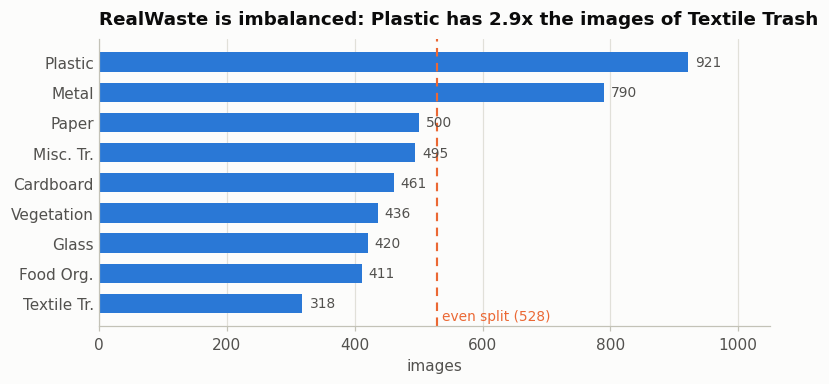

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
barh(ax, [SHORT[c] for c in counts.index], counts.values,
     title='RealWaste is imbalanced: Plastic has 2.9x the images of Textile Trash',
     xlabel='images')
ax.axvline(len(images) / NUM_CLASSES, color=ORANGE, lw=1.4, ls=(0, (4, 3)))
ax.text(len(images) / NUM_CLASSES + 8, NUM_CLASSES - 0.6, 'even split (528)',
        color=ORANGE, fontsize=9, va='center')
plt.tight_layout(); plt.show()

**Why this matters.** A 2.9:1 imbalance is mild enough that oversampling would mostly add
redundant gradient steps, but large enough that an unweighted model will quietly trade
Textile Trash recall for Plastic recall. Part 2 therefore uses **class weights** (inverse
frequency) rather than resampling, and reports **macro F1** alongside accuracy so the small
streams cannot be hidden by the large ones.

In [6]:
# Single pass over every file: header info plus a greyscale thumbnail reused for three
# diagnostics (exposure, edge density, near-duplicate detection). `draft()` lets libjpeg
# decode straight to a reduced size, which keeps the pass to well under a minute.
t0 = time.time()
rows, thumbs = [], []
for f in images['path']:
    im = Image.open(f)
    w, h, mode = im.size[0], im.size[1], im.mode
    im.draft('L', (130, 130))
    g128 = np.asarray(im.convert('L').resize((128, 128)), dtype=np.float32)
    edge = float(np.abs(np.diff(g128, axis=0)).mean() + np.abs(np.diff(g128, axis=1)).mean())
    rows.append((w, h, mode, float(g128.mean()), float(g128.std()), edge))
    thumbs.append(np.asarray(Image.fromarray(g128.astype('uint8')).resize((32, 32)),
                             dtype=np.float32).ravel())

images[['width', 'height', 'mode', 'brightness', 'contrast', 'edge_density']] = pd.DataFrame(rows, index=images.index)
THUMBS = np.stack(thumbs)
print(f'scanned {len(images):,} images in {time.time() - t0:.0f}s')
print(f"resolutions: {images.groupby(['width', 'height']).size().to_dict()}")
print(f"colour modes: {images['mode'].value_counts().to_dict()}")
print(f"file size: {images['path'].map(lambda p: p.stat().st_size).mean() / 1024:.0f} kB mean")

scanned 4,752 images in 27s
resolutions: {(524, 524): 4752}
colour modes: {'RGB': 4752}
file size: 141 kB mean


Every image is **524x524 RGB** — no aspect-ratio or colour-mode handling is needed, and the
resize to 224x224 is a clean 2.3x downscale with no distortion. That is unusually tidy, and
it is also a *limitation*: a resident's phone photo will not be square, will not be framed
the same way, and will not be lit by a facility floodlight. Section 5.4 returns to this.

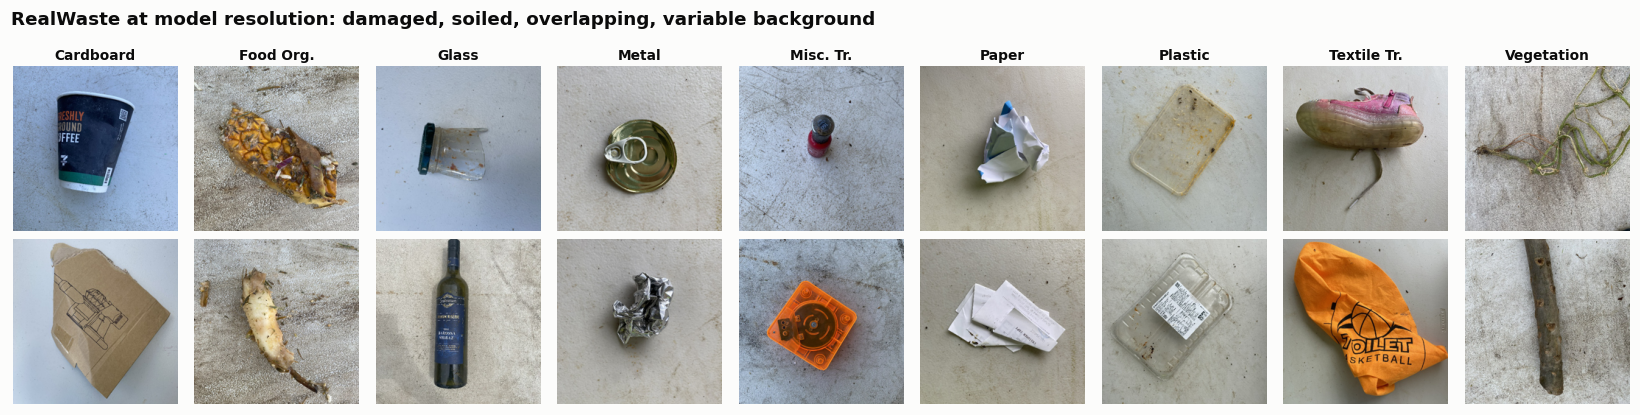

In [7]:
# What the model will actually see: two examples per stream, after the 224x224 resize.
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(15, 3.9))
rng = np.random.default_rng(SEED)
for j, cls in enumerate(CLASS_NAMES):
    picks = rng.choice(images.index[images['label'] == cls], 2, replace=False)
    for i, idx in enumerate(picks):
        axes[i, j].imshow(Image.open(images.at[idx, 'path']).resize((IMG_WIDTH, IMG_HEIGHT)))
        axes[i, j].axis('off')
    axes[0, j].set_title(SHORT[cls], fontsize=9, loc='center', pad=4)
fig.suptitle('RealWaste at model resolution: damaged, soiled, overlapping, variable background',
             x=0.009, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

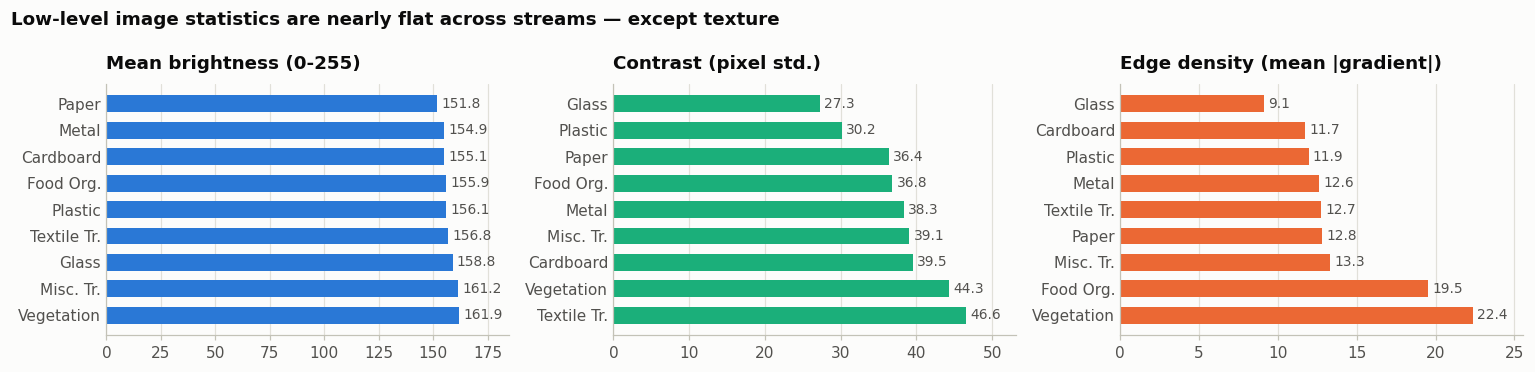

brightness spread across streams: 10.2 grey levels
edge density: Vegetation 22.4 vs Glass 9.1 (2.5x)


In [8]:
# Exposure, contrast and edge density per stream — a quick check for shortcut features
# (if one class were systematically darker or busier, the CNN could learn that instead
# of the material).
char = images.groupby('label')[['brightness', 'contrast', 'edge_density']].mean()
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, (col, title, color) in zip(axes, [
        ('brightness', 'Mean brightness (0-255)', BLUE),
        ('contrast', 'Contrast (pixel std.)', AQUA),
        ('edge_density', 'Edge density (mean |gradient|)', ORANGE)]):
    s = char[col].sort_values()
    barh(ax, [SHORT[c] for c in s.index], s.values, color=color, title=title, fmt='{:.1f}')
fig.suptitle('Low-level image statistics are nearly flat across streams — except texture',
             x=0.006, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"brightness spread across streams: {char['brightness'].max() - char['brightness'].min():.1f} grey levels")
print(f"edge density: Vegetation {char.loc['Vegetation', 'edge_density']:.1f} vs "
      f"Glass {char.loc['Glass', 'edge_density']:.1f} "
      f"({char.loc['Vegetation', 'edge_density'] / char.loc['Glass', 'edge_density']:.1f}x)")

Brightness and contrast are essentially constant across streams (a 9-grey-level spread on a
0-255 scale), so there is no exposure shortcut for the model to latch onto. **Edge density is
not flat**: Vegetation and Food Organics are more than twice as textured as Glass and
Cardboard. That is a genuine signal (leaves and food scraps really are high-frequency), and it
predicts which streams will be easy — the confusion matrix in §2.6 confirms it.

In [9]:
# Near-duplicate audit. A facility photographs the same item more than once; if two frames of
# one bottle land on opposite sides of the split, the test score is inflated. Pairwise mean
# absolute difference on the 32x32 thumbnails, within class only.
t0 = time.time()
dup_pairs = []
for cls in CLASS_NAMES:
    idx = images.index[images['label'] == cls].to_numpy()
    X = THUMBS[idx]
    for s in range(0, len(idx), 250):                        # chunked to bound memory
        D = np.abs(X[s:s + 250, None, :] - X[None, :, :]).mean(-1)
        for a in range(D.shape[0]):
            for b in np.where(D[a] < 6.0)[0]:
                if idx[s + a] < idx[b]:
                    dup_pairs.append((idx[s + a], idx[b]))

# Union-find over the near-duplicate pairs -> clusters of frames showing the same item
parent = {i: i for i in images.index}
def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i
for a, b in dup_pairs:
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb
images['item_group'] = [find(i) for i in images.index]

n_clustered = int((images.groupby('item_group')['item_group'].transform('size') > 1).sum())
print(f'{len(dup_pairs)} near-duplicate pairs -> {n_clustered} images ({n_clustered / len(images):.1%}) '
      f'belong to a multi-frame group  [{time.time() - t0:.0f}s]')
print(images[images.groupby('item_group')['item_group'].transform('size') > 1]
      .groupby('label').size().to_frame('near-duplicate images'))

59 near-duplicate pairs -> 69 images (1.5%) belong to a multi-frame group  [11s]
                     near-duplicate images
label                                     
Food Organics                            6
Glass                                   49
Metal                                    4
Miscellaneous Trash                      2
Plastic                                  6
Textile Trash                            2


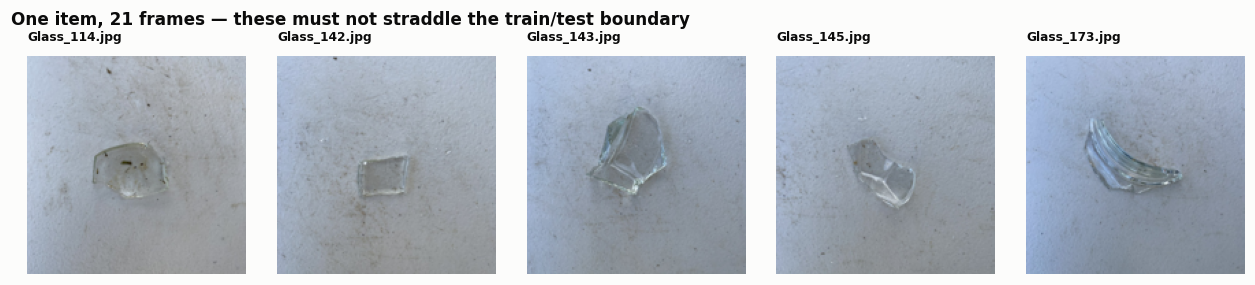

In [10]:
# The worst offender, shown: Glass bottles re-photographed on the same patch of floor.
biggest = images.groupby('item_group').size().sort_values(ascending=False)
grp = images[images['item_group'] == biggest.index[0]]
fig, axes = plt.subplots(1, min(5, len(grp)), figsize=(2.3 * min(5, len(grp)), 2.6))
for ax, (_, r) in zip(np.atleast_1d(axes), grp.iterrows()):
    ax.imshow(Image.open(r['path']).resize((160, 160)))
    ax.set_title(r['filename'], fontsize=8)
    ax.axis('off')
fig.suptitle(f'One item, {len(grp)} frames — these must not straddle the train/test boundary',
             x=0.006, ha='left', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

**Finding 1 (images).** 1.5% of the set is near-duplicate frames, and they are concentrated in
Glass (12% of that stream). Splitting at random would leak those items across the boundary.
The split built in §1.4 is therefore **grouped** — every frame of an item goes to the same
side — as well as stratified.

### 1.2 The resident descriptions

`waste_descriptions.csv` simulates what a resident types into the app. Five columns arrive
with it, and the first job is to work out which of them a model is actually allowed to see.

In [11]:
desc = pd.read_csv(DESCRIPTIONS_CSV)
print(f'{len(desc):,} rows x {desc.shape[1]} columns: {list(desc.columns)}')
print(f'missing values:\n{desc.isna().sum().to_string()}')
desc.head(6)

5,000 rows x 5 columns: ['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']
missing values:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, may include blends."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives for color or strength."
2,large Supermarket vegetable waste with food residue,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or animal sources.
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, may include blends."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in some composting systems.,Biodegradable matter derived from plant or animal sources.
5,wrinkled pink takeout container with product remaining,Plastic,Remove labels if possible.,Plastic bags often can not go in general recycling. Check for recycling numbers (1-7) on co...,Polymer materials derived from petrochemicals or plant-based sources.


In [12]:
# Leakage audit: how many distinct values does each auxiliary column take, and does any single
# value ever span more than one category?
audit = []
for col in ['description', 'disposal_instruction', 'common_confusion', 'material_composition']:
    s = desc[[col, 'category']].dropna()
    spans = s.groupby(col)['category'].nunique()
    audit.append({'column': col,
                  'distinct values': s[col].nunique(),
                  'values spanning >1 category': int((spans > 1).sum()),
                  'category determined by this column': f'{(spans == 1).mean():.0%} of values'})
audit = pd.DataFrame(audit)
print(audit.to_string(index=False))
print()
print('material_composition values (one per stream - this column *is* the label):')
print(desc.groupby('category')['material_composition'].first().to_string())

              column  distinct values  values spanning >1 category category determined by this column
         description             4939                            0                     100% of values
disposal_instruction               44                            1                      98% of values
    common_confusion                9                            0                     100% of values
material_composition                9                            0                     100% of values

material_composition values (one per stream - this column *is* the label):
category
Cardboard                           Thick paper pulp formed into corrugated or solid sheets.
Food Organics                     Biodegradable matter derived from plant or animal sources.
Glass                    Silica-based material, may contain additives for color or strength.
Metal                                            Aluminum, steel, tin or mixed metal alloys.
Miscellaneous Trash           Var

**Finding 2 (text): three of the five columns are the label in disguise.**
`material_composition` takes exactly 9 values, one per stream — it is a renamed target.
`common_confusion` likewise takes 9 values, and 43 of the 44 `disposal_instruction` strings
map to a single stream. A classifier trained on any of them would score ~100% and learn
nothing about language.

**Decision:** the text classifier in Part 3 is trained on the `description` column *only*.
The other columns are not wasted — `disposal_instruction` becomes reference material for the
RAG corpus in §1.4, where quoting the label-correlated text is the whole point.

descriptions: 1-10 words (median 5), 33 characters on average
vocabulary: 309 distinct lowercase word types in 25,241 tokens
duplicate description strings: 61 (4,939 unique)
conflicting labels on an identical string: 0
class balance: 600-506 per stream (imbalance 1.19:1 — effectively balanced)


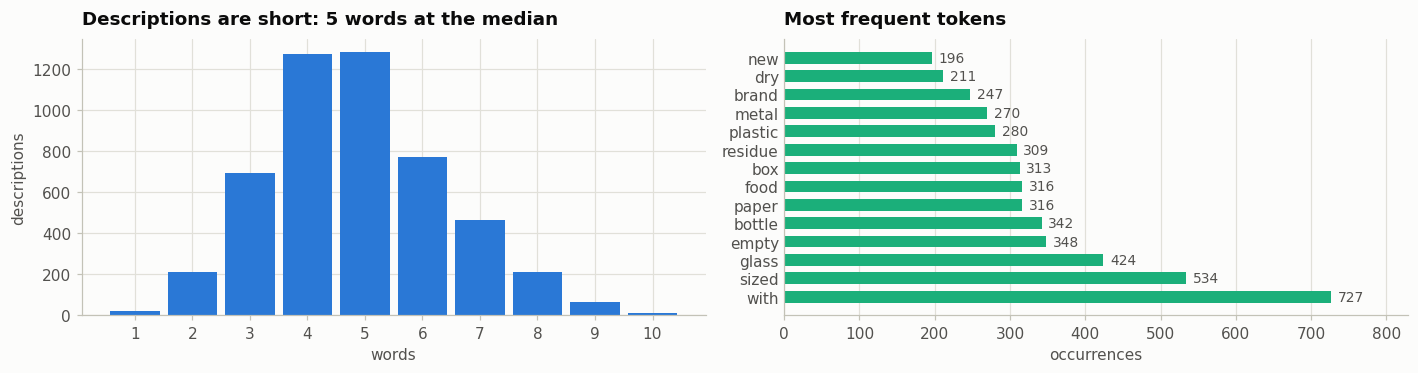

In [13]:
desc['n_words'] = desc['description'].str.split().str.len()
desc['n_chars'] = desc['description'].str.len()
vocab = Counter(w for d in desc['description'] for w in re.findall(r"[a-z']+", d.lower()))

cat_counts = desc['category'].value_counts()
print(f"descriptions: {desc['n_words'].min()}-{desc['n_words'].max()} words "
      f"(median {desc['n_words'].median():.0f}), {desc['n_chars'].mean():.0f} characters on average")
print(f'vocabulary: {len(vocab)} distinct lowercase word types in {sum(vocab.values()):,} tokens')
print(f'duplicate description strings: {desc["description"].duplicated().sum()} '
      f'({desc["description"].nunique():,} unique)')
print(f'conflicting labels on an identical string: '
      f'{int((desc.groupby("description")["category"].nunique() > 1).sum())}')
print(f'class balance: {cat_counts.max()}-{cat_counts.min()} per stream '
      f'(imbalance {cat_counts.max() / cat_counts.min():.2f}:1 — effectively balanced)')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].hist(desc['n_words'], bins=range(1, 12), color=BLUE, rwidth=0.86, align='left')
axes[0].set_title('Descriptions are short: 5 words at the median')
axes[0].set_xlabel('words'); axes[0].set_ylabel('descriptions')
axes[0].set_xticks(range(1, 11))
top = pd.Series(dict(vocab.most_common(14))).sort_values()
barh(axes[1], top.index, top.values, color=AQUA, title='Most frequent tokens', xlabel='occurrences')
plt.tight_layout(); plt.show()

A 309-word vocabulary over 5,000 documents is tiny, and the shape of the data explains why:
the descriptions are **templated** — a condition adjective, an optional size/brand modifier, a
head noun, and an optional state clause (`"wrinkled pink takeout container with product
remaining"`). That has two consequences. It makes the task easy enough that a linear model on
character and word n-grams is a serious contender, and it means the only hard cases are the
ones where the *head noun itself* is ambiguous.

In [14]:
# Which tokens are shared across streams, and how badly?
tok2cat = defaultdict(Counter)
for d, c in zip(desc['description'], desc['category']):
    for w in set(re.findall(r"[a-z']+", d.lower())):
        tok2cat[w][c] += 1

# A token is "informative but ambiguous" when a couple of streams account for nearly all of
# its uses, yet no single stream dominates it: 'bottle' is one of three streams, which is
# useful and insufficient at the same time. Generic modifiers ('with', 'large') spread across
# all nine and are filtered out by the top-3 coverage test.
rows_amb = []
for w, cc in tok2cat.items():
    n = sum(cc.values())
    if n < 60:
        continue
    shares = np.array([v for _, v in cc.most_common()]) / n
    if shares[0] < 0.90 and shares[:3].sum() > 0.80:
        rows_amb.append((w, n, shares[0], len(cc), dict(cc.most_common(3))))
rows_amb.sort(key=lambda r: -r[1])
print("Informative-but-ambiguous tokens (>=60 uses; top 3 streams cover >80%, none over 90%):")
for w, n, top1, k, top3 in rows_amb[:10]:
    print(f"  {w:<12} {n:4d} uses  majority stream {top1:4.0%}  spans {k} streams   {top3}")

exclusive = {w for w, cc in tok2cat.items() if len(cc) == 1}
desc['has_exclusive_token'] = desc['description'].map(
    lambda d: any(w in exclusive for w in re.findall(r"[a-z']+", d.lower())))
hard = desc[~desc['has_exclusive_token']]
print(f'\n{len(hard)} descriptions ({len(hard) / len(desc):.0%}) contain no stream-exclusive word at all;'
      f' these are the rows Part 3 has to reason about rather than look up.')
print(hard['category'].value_counts().to_frame('ambiguous descriptions').T.to_string())

Informative-but-ambiguous tokens (>=60 uses; top 3 streams cover >80%, none over 90%):
  glass         424 uses  majority stream  90%  spans 3 streams   {'Glass': 381, 'Textile Trash': 24, 'Miscellaneous Trash': 19}
  bottle        342 uses  majority stream  53%  spans 3 streams   {'Glass': 180, 'Plastic': 118, 'Metal': 44}
  paper         316 uses  majority stream  78%  spans 4 streams   {'Paper': 247, 'Cardboard': 38, 'Textile Trash': 16}
  plastic       280 uses  majority stream  76%  spans 3 streams   {'Plastic': 213, 'Miscellaneous Trash': 49, 'Textile Trash': 18}
  metal         270 uses  majority stream  79%  spans 3 streams   {'Metal': 214, 'Miscellaneous Trash': 41, 'Textile Trash': 15}
  cardboard     138 uses  majority stream  75%  spans 3 streams   {'Cardboard': 103, 'Miscellaneous Trash': 19, 'Textile Trash': 16}
  container     129 uses  majority stream  61%  spans 3 streams   {'Plastic': 79, 'Glass': 29, 'Metal': 21}
  packaging     110 uses  majority stream  63%  spans 

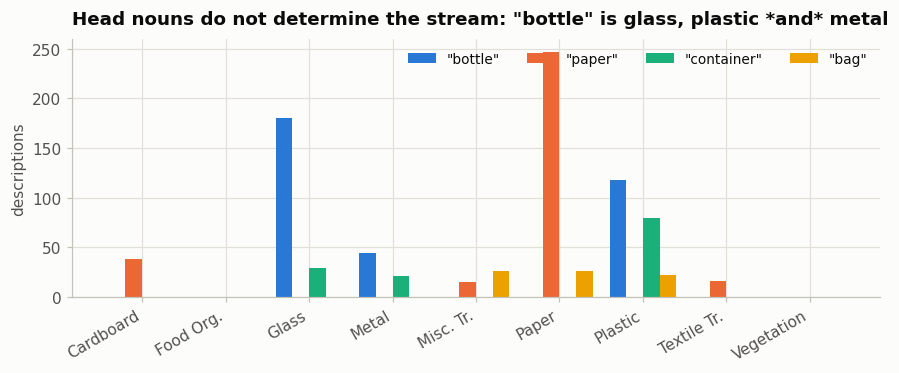

In [15]:
fig, ax = plt.subplots(figsize=(8.2, 3.5))
show_tokens = ['bottle', 'paper', 'container', 'bag']
order = [c for c in CLASS_NAMES]
w = 0.8 / len(show_tokens)
for k, tok in enumerate(show_tokens):
    vals = [tok2cat[tok].get(c, 0) for c in order]
    ax.bar(np.arange(len(order)) + (k - (len(show_tokens) - 1) / 2) * w, vals, w,
           label=f'"{tok}"')
ax.set_xticks(range(len(order)))
ax.set_xticklabels([SHORT[c] for c in order], rotation=30, ha='right')
ax.set_ylabel('descriptions')
ax.set_title('Head nouns do not determine the stream: "bottle" is glass, plastic *and* metal')
ax.legend(ncol=4)
plt.tight_layout(); plt.show()

**Finding 3 (text).** `"bottle"` appears in Glass, Plastic *and* Metal descriptions;
`"paper"` appears in Paper but also in Cardboard and Textile Trash (`"paper towel"`);
`"cup"` is split almost evenly three ways. 17% of rows contain no stream-exclusive word at
all, so their label depends on how words combine rather than on which words are present.

The obvious hypothesis is that this 17% is where a bag-of-words model and a contextual
transformer part company. Part 3 therefore trains both and scores them **on that subset
specifically** rather than only on the headline accuracy — and §3.4 reports that the
hypothesis is wrong, which is more interesting than if it had held.

### 1.3 The Metro City policy documents

In [16]:
with open(POLICY_JSON, encoding='utf-8') as fh:
    policies = json.load(fh)

pol = pd.DataFrame(policies)
pol['n_chars'] = pol['document_text'].str.len()
pol['n_categories'] = pol['categories_covered'].map(len)
print(f'{len(pol)} policy documents, {pol["n_chars"].sum():,} characters total '
      f'({pol["n_chars"].min()}-{pol["n_chars"].max()} each)')
print(f'jurisdictions: {pol["jurisdiction"].unique().tolist()} | '
      f'effective dates {pol["effective_date"].min()} to {pol["effective_date"].max()}')
pol[['policy_id', 'policy_type', 'n_categories', 'effective_date', 'n_chars']]

14 policy documents, 9,560 characters total (571-951 each)
jurisdictions: ['Metro City'] | effective dates 2023-01-01 to 2023-12-15


,policy_id,policy_type,n_categories,effective_date,n_chars
0,1,Textile Trash Recycling Guidelines,1,2023-11-04,688
1,2,Glass Recycling Guidelines,1,2023-01-24,571
2,3,Food Organics Recycling Guidelines,1,2023-05-08,638
3,4,Plastic Recycling Guidelines,1,2023-04-05,655
4,5,Vegetation Recycling Guidelines,1,2023-12-04,620
5,6,Cardboard Recycling Guidelines,1,2023-11-24,606
6,7,Metal Recycling Guidelines,1,2023-09-03,664
7,8,Paper Recycling Guidelines,1,2023-10-14,635
8,9,Miscellaneous Trash Recycling Guidelines,1,2023-01-01,718
9,10,Municipal Waste Guidelines,3,2023-10-01,686


In [17]:
print(pol.loc[1, 'policy_type'], '\n' + '-' * 60)
print(pol.loc[1, 'document_text'])

Glass Recycling Guidelines 
------------------------------------------------------------
GLASS RECYCLING GUIDELINES

Acceptable Items:
- Glass bottles (all colors)
- Glass jars
- Glass food containers
- Glass beverage containers

Non-Acceptable Items:
- Window glass or mirrors
- Drinking glasses
- Ceramics or pottery
- Light bulbs
- Pyrex or heat-resistant glass

Collection Method:
Place in dedicated glass recycling bins. Some areas require color sorting.

Preparation Instructions:
- Rinse containers
- Remove caps and lids (recycle separately)
- Labels can remain

Benefits:
Glass is 100% recyclable and can be recycled endlessly without loss of quality.


Section headings, and how many of the 14 documents use each:
  Benefits                          9/14
  Acceptable Items                  8/14
  Non-Acceptable Items              8/14
  Collection Method                 8/14
  Preparation Instructions          8/14
  GENERAL REQUIREMENTS              5/14
  MISCELLANEOUS TRASH GUIDELINES    3/14
  VEGETATION GUIDELINES             3/14
  METAL GUIDELINES                  3/14
  PLASTIC GUIDELINES                2/14
  GLASS GUIDELINES                  2/14
  CARDBOARD GUIDELINES              2/14
  TEXTILE TRASH GUIDELINES          2/14
  Items That Cannot Be Recycled     1/14
  Special Handling Items            1/14
  Waste Reduction Tips              1/14
  FOOD ORGANICS GUIDELINES          1/14


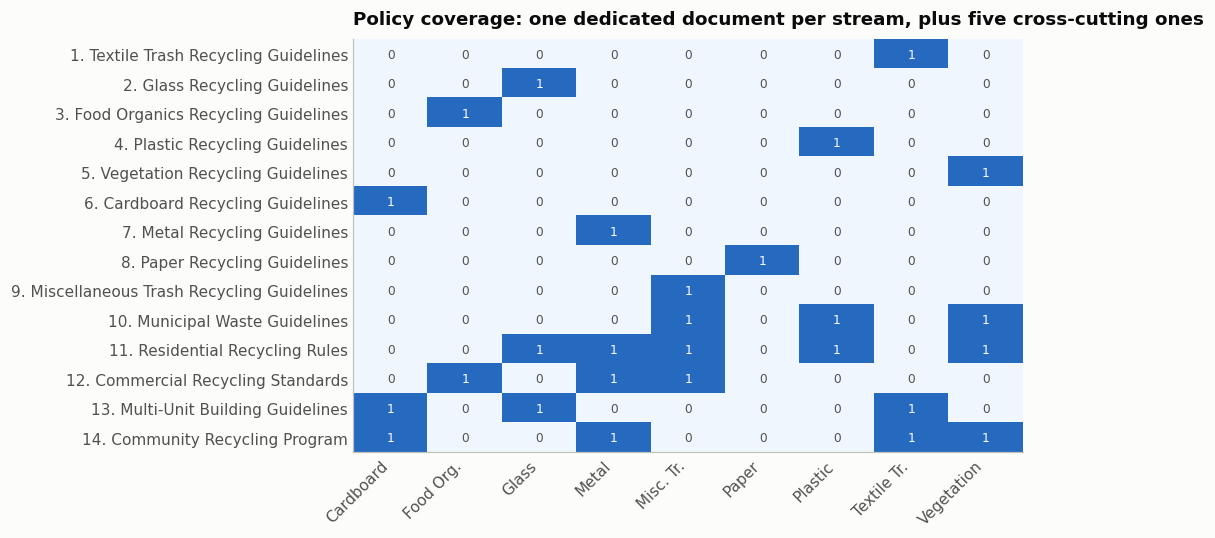

documents covering each stream: Cardboard 3, Food Org. 2, Glass 3, Metal 4, Misc. Tr. 4, Paper 1, Plastic 3, Textile Tr. 3, Vegetation 4
thinnest coverage: Paper (1 document) - retrieval for that stream has only one place to go.


In [18]:
# Every document follows the same heading structure, which is what makes section-level
# chunking possible in §1.4. Two heading styles occur: topic headings in the nine dedicated
# documents ("Acceptable Items:", "Preparation Instructions:") and per-stream headings inside
# the five cross-cutting ones ("GLASS GUIDELINES:").
SECTION_RE = re.compile(r'^([A-Z][A-Za-z /-]+):\s*$', re.M)   # the hyphen matters:
#                                                               "Non-Acceptable Items:" is a
#                                                               heading, not part of the list
#                                                               above it
sections = Counter(m.group(1) for d in pol['document_text'] for m in SECTION_RE.finditer(d))
print('Section headings, and how many of the 14 documents use each:')
for s, n in sections.most_common():
    print(f'  {s:<32} {n:>2}/14')

cover = np.zeros((len(pol), NUM_CLASSES))
for i, cats in enumerate(pol['categories_covered']):
    for c in cats:
        cover[i, CLASS_NAMES.index(c)] = 1
per_cat = cover.sum(0).astype(int)

fig, ax = plt.subplots(figsize=(9.5, 5))
heat(ax, cover, [SHORT[c] for c in CLASS_NAMES],
     [f'{r.policy_id}. {r.policy_type}' for r in pol.itertuples()],
     title='Policy coverage: one dedicated document per stream, plus five cross-cutting ones',
     fmt='{:.0f}', vmax=1.4)
plt.tight_layout(); plt.show()
print('documents covering each stream:',
      ', '.join(f'{SHORT[c]} {n}' for c, n in zip(CLASS_NAMES, per_cat)))
print(f'thinnest coverage: {CLASS_NAMES[int(per_cat.argmin())]} ({per_cat.min()} document) - '
      f'retrieval for that stream has only one place to go.')

Documents 1-9 are one-per-stream guidelines; documents 10-14 are cross-cutting (municipal,
residential, commercial, multi-unit, community). Every stream is covered by its dedicated
document plus between 0 and 3 general ones, so **retrieval has a ground truth**: for the query
*"How do I recycle Glass?"*, the relevant set is exactly the documents whose
`categories_covered` contains Glass. §4.2 uses that to score the retriever with recall@k and
MRR instead of eyeballing it.

### 1.4 Data pipelines and splits

#### 1.4a The provided Keras pipeline, and why the modelling does not use it

In [19]:
# ---- Provided starter cell, run as given ----
import pathlib
data_dir = pathlib.Path('RealWaste')

num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=True)
validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=True)

val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)
# ---- end provided cell ----
# (The three `.cache()` calls in the original are dropped: caching 3,800 decoded 224x224x3
#  float32 images needs ~2.3 GB of RAM, which this machine does not have spare.)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752


Found 4752 files belonging to 9 classes.


Using 3802 files for training.


Found 4752 files belonging to 9 classes.


Using 950 files for validation.


Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


The provided pipeline is a correct 80/20 split and it runs, but three properties make it
unsuitable for the evaluation this lab is graded on:

1. **The test set is carved out of the validation set.** `validation_ds.take(n//2)` is taken
   *after* the generator has been consumed to build it, and both halves come from the same
   20% partition — so the "test" set is a sibling of the data used for early stopping, not an
   untouched holdout.
2. **No grouping.** Random assignment puts near-duplicate frames of the same bottle
   (Finding 1) on both sides of the boundary.
3. **Batch-level splitting.** Slicing by batch cannot guarantee stratification; with 9
   uneven classes the small streams drift.

The modelling below therefore uses the file-level split built next. The provided datasets stay
defined so the cell above remains runnable and comparable.

#### 1.4b A grouped, stratified 70/15/15 image split

In [20]:
def grouped_stratified_split(df, group_col, label_col, fractions=SPLIT, seed=SEED):
    """Assign whole groups to train/val/test while holding each label's proportions.

    Groups (here: all frames of one physical item) are never broken apart. Within a label,
    groups are shuffled and then greedily placed into whichever split is furthest below its
    target count, which keeps the stratification tight even though group sizes vary.
    """
    rng = np.random.default_rng(seed)
    assignment = pd.Series(index=df.index, dtype=object)
    for label, part in df.groupby(label_col):
        groups = list(part.groupby(group_col).groups.values())
        rng.shuffle(groups)
        targets = np.array(fractions) * len(part)
        filled = np.zeros(3)
        for g in groups:
            j = int(np.argmax(targets - filled))     # most under-filled split wins
            assignment[list(g)] = ['train', 'val', 'test'][j]
            filled[j] += len(g)
    return assignment


images['split'] = grouped_stratified_split(images, 'item_group', 'label')

split_tab = (pd.crosstab(images['label'], images['split'])[['train', 'val', 'test']])
split_tab.loc['TOTAL'] = split_tab.sum()
split_share = split_tab.div(split_tab.sum(axis=1), axis=0)
print(split_tab.to_string())
print('\nper-stream share of each split (target 70 / 15 / 15):')
print(split_share.applymap('{:.1%}'.format).to_string())

leak = images.groupby('item_group')['split'].nunique().gt(1).sum()
print(f'\nitem groups split across more than one partition: {leak}  (must be 0)')

split                train  val  test
label                                
Cardboard              323   69    69
Food Organics          288   62    61
Glass                  292   67    61
Metal                  553  119   118
Miscellaneous Trash    347   74    74
Paper                  350   75    75
Plastic                645  138   138
Textile Trash          222   48    48
Vegetation             305   66    65
TOTAL                 3325  718   709

per-stream share of each split (target 70 / 15 / 15):
split                train    val   test
label                                   
Cardboard            70.1%  15.0%  15.0%
Food Organics        70.1%  15.1%  14.8%
Glass                69.5%  16.0%  14.5%
Metal                70.0%  15.1%  14.9%
Miscellaneous Trash  70.1%  14.9%  14.9%
Paper                70.0%  15.0%  15.0%
Plastic              70.0%  15.0%  15.0%
Textile Trash        69.8%  15.1%  15.1%
Vegetation           70.0%  15.1%  14.9%
TOTAL                70.0%  15.1%  14.

In [21]:
# tf.data pipelines built from explicit file lists, so the split above is exactly what trains.
def make_image_ds(frame, shuffle=False, batch_size=BATCH_SIZE):
    """Decode -> resize -> one-hot. No scaling here: the backbone's own preprocess_input
    layer handles that inside the model, so the saved model is self-contained."""
    paths = tf.constant([str(p) for p in frame['path']])
    labels = tf.keras.utils.to_categorical(frame['label_idx'], NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)

    def load(path, label):
        img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
        img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH], method='bilinear')
        return img, label

    return (ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(batch_size)
              .prefetch(tf.data.AUTOTUNE))


img_train = images[images['split'] == 'train'].reset_index(drop=True)
img_val = images[images['split'] == 'val'].reset_index(drop=True)
img_test = images[images['split'] == 'test'].reset_index(drop=True)

ds_train = make_image_ds(img_train, shuffle=True)
ds_val = make_image_ds(img_val)
ds_test = make_image_ds(img_test)

xb, yb = next(iter(ds_train))
print(f'train {len(img_train)} | val {len(img_val)} | test {len(img_test)}')
print(f'batch: images {xb.shape} {xb.dtype} range [{float(tf.reduce_min(xb)):.0f}, '
      f'{float(tf.reduce_max(xb)):.0f}] | labels {yb.shape} one-hot')

train 3325 | val 718 | test 709
batch: images (32, 224, 224, 3) <dtype: 'float32'> range [0, 255] | labels (32, 9) one-hot


#### 1.4c Text cleaning and split

The cleaning is deliberately light. Descriptions are short, templated and already lowercase-ish;
aggressive stemming or stop-word removal would destroy the few function words that carry
meaning (`"with food residue"`, `"partially filled"`). What is worth doing is normalising case
and punctuation, collapsing the brand placeholders (`Brand A`, `Premium`, `Supermarket`) that
are pure noise, and **de-duplicating** so the 61 repeated strings cannot straddle the split.

In [22]:
BRAND_RE = re.compile(r'\b(brand [a-z]|premium|budget|designer|eco-friendly|supermarket|'
                      r'generic|store|value|luxury)\b', re.I)


def clean_description(text):
    """Normalise a resident description without destroying its content words."""
    t = str(text).lower()
    t = BRAND_RE.sub(' ', t)                     # brand placeholders carry no stream signal
    t = re.sub(r'[^a-z\s-]', ' ', t)             # keep hyphens: "plastic-metal composite"
    t = re.sub(r'\s+', ' ', t).strip()
    return t


desc['clean'] = desc['description'].map(clean_description)
print('cleaning examples (rows where normalisation actually changes something):')
changed = desc[desc['description'].str.lower() != desc['clean']]
for s in changed['description'].sample(5, random_state=3):
    print(f'  {s!r:<58} ->  {clean_description(s)!r}')
print(f'{len(changed) / len(desc):.0%} of descriptions carry a brand placeholder or punctuation '
      f'that cleaning removes')

text_df = (desc.drop_duplicates(subset='clean')
               .loc[:, ['clean', 'description', 'category', 'has_exclusive_token']]
               .reset_index(drop=True))
print(f'\n{len(desc):,} rows -> {len(text_df):,} after de-duplicating cleaned strings')

txt_train, txt_tmp = train_test_split(text_df, test_size=SPLIT[1] + SPLIT[2],
                                      stratify=text_df['category'], random_state=SEED)
rel = SPLIT[2] / (SPLIT[1] + SPLIT[2])
txt_val, txt_test = train_test_split(txt_tmp, test_size=rel,
                                     stratify=txt_tmp['category'], random_state=SEED)
for name, part in [('train', txt_train), ('val', txt_val), ('test', txt_test)]:
    print(f'  {name:<5} {len(part):>5} rows | '
          f'class share {part["category"].value_counts(normalize=True).min():.3f}-'
          f'{part["category"].value_counts(normalize=True).max():.3f}')
print(f'overlap between train and test descriptions: '
      f'{len(set(txt_train["clean"]) & set(txt_test["clean"]))}')

cleaning examples (rows where normalisation actually changes something):
  'empty spotted Budget palm fronds'                         ->  'empty spotted palm fronds'
  'dirty massive striped Designer corrugated box'            ->  'dirty massive striped corrugated box'
  'folded medium transparent Eco-Friendly vegetable plant'   ->  'folded medium transparent vegetable plant'
  'Brand B yogurt container'                                 ->  'yogurt container'
  'partial fun-sized orange Brand A soda can'                ->  'partial fun-sized orange soda can'
21% of descriptions carry a brand placeholder or punctuation that cleaning removes

5,000 rows -> 4,902 after de-duplicating cleaned strings
  train  3431 rows | class share 0.101-0.119
  val     735 rows | class share 0.101-0.118
  test    736 rows | class share 0.101-0.120
overlap between train and test descriptions: 0


#### 1.4d The retrieval corpus

Two kinds of document go into the index. The 14 policies are split **by section** — a
resident asking how to prepare an item wants the *Preparation Instructions* block, not the
whole 700-character document, and section-level chunks keep the retrieved context short
enough for FLAN-T5's prompt. Alongside them, each stream contributes one **disposal card**
built from the `disposal_instruction` and `common_confusion` columns of the description file,
which is where the advice on confusable items actually lives.

In [23]:
def split_sections(text):
    """Split a policy document into (heading, body) sections on its 'Heading:' lines.

    The bare title line is not emitted as a chunk of its own - three words retrieve nothing
    useful - but it is prepended to every section so each chunk names its own source.
    """
    marks = [(m.start(), m.group(1)) for m in SECTION_RE.finditer(text)]
    if not marks:
        return [('Document', text.strip())]
    out = []
    for i, (pos, name) in enumerate(marks):
        end = marks[i + 1][0] if i + 1 < len(marks) else len(text)
        body = text[text.index('\n', pos) + 1:end].strip()
        if body:
            out.append((name, body))
    return out


def section_categories(heading, doc_categories):
    """A 'GLASS GUIDELINES:' section inside a cross-cutting document is about Glass only."""
    for c in CLASS_NAMES:
        if heading.upper().startswith(c.upper()):
            return [c]
    return list(doc_categories)


# Each chunk is stored twice over, for two different consumers:
#   `text` - document title + section heading + content. This is what gets embedded, because
#            the heading words ("Preparation Instructions", "Non-Acceptable Items") are
#            exactly what makes a chunk findable by a question about preparation or exclusions.
#   `body` - content only. This is what goes into a generation prompt, because a model shown
#            the heading tends to answer with the heading.
def flatten(text):
    return re.sub(r'\s+', ' ', text.replace('\n- ', '; ').replace('\n', ' ')).strip().lstrip('- ')


chunks = []
for p in policies:
    title = p['document_text'].split('\n')[0].strip()
    for name, body in split_sections(p['document_text']):
        chunks.append({'chunk_id': f"P{p['policy_id']}-{name.replace(' ', '')[:18]}",
                       'source': f"Policy {p['policy_id']}: {p['policy_type']}",
                       'section': name,
                       'categories': section_categories(name, p['categories_covered']),
                       'effective_date': p['effective_date'],
                       'text': f"{title}. {name}: {body}",
                       'body': flatten(body)})

for cat, grp in desc.groupby('category'):
    tips = sorted(grp['disposal_instruction'].dropna().unique())
    conf = sorted(grp['common_confusion'].dropna().unique())
    card = ' '.join(tips) + (' Common confusion: ' + ' '.join(conf) if conf else '')
    chunks.append({'chunk_id': f'D-{cat.replace(" ", "")}', 'source': f'{cat} disposal card',
                   'section': 'Disposal Instructions', 'categories': [cat],
                   'effective_date': None,
                   'text': f'{cat} disposal instructions: {card}',
                   'body': flatten(card)})

corpus = pd.DataFrame(chunks)
corpus['n_words'] = corpus['text'].str.split().str.len()
chunks_per_cat = pd.Series({c: int(corpus['categories'].map(lambda cs: c in cs).sum())
                            for c in CLASS_NAMES})
print(f'{len(corpus)} retrievable chunks from {len(pol)} policies + {NUM_CLASSES} disposal cards')
print(f'chunk length: {corpus["n_words"].min()}-{corpus["n_words"].max()} words '
      f'(median {corpus["n_words"].median():.0f}) - short enough that the top 3 fit in a '
      f'FLAN-T5 prompt together')
print(f'\nrelevant chunks per stream (the retrieval ground truth used in 4.2):')
print(chunks_per_cat.to_string())
corpus.head(4)[['chunk_id', 'source', 'section', 'categories', 'n_words']]

76 retrievable chunks from 14 policies + 9 disposal cards
chunk length: 12-63 words (median 26) - short enough that the top 3 fit in a FLAN-T5 prompt together

relevant chunks per stream (the retrieval ground truth used in 4.2):
Cardboard              10
Food Organics           8
Glass                  10
Metal                  12
Miscellaneous Trash    11
Paper                   6
Plastic                10
Textile Trash          10
Vegetation             12


,chunk_id,source,section,categories,n_words
0,P1-AcceptableItems,Policy 1: Textile Trash Recycling Guidelines,Acceptable Items,[Textile Trash],36
1,P1-Non-AcceptableItem,Policy 1: Textile Trash Recycling Guidelines,Non-Acceptable Items,[Textile Trash],26
2,P1-CollectionMethod,Policy 1: Textile Trash Recycling Guidelines,Collection Method,[Textile Trash],18
3,P1-PreparationInstruc,Policy 1: Textile Trash Recycling Guidelines,Preparation Instructions,[Textile Trash],24


### Part 1 takeaways — what the rest of the notebook has to handle

| # | Finding | Where it bites | Response |
|---|---|---|---|
| 1 | 2.9:1 class imbalance in the images | Textile Trash recall | class weights + macro F1 (§2.3, §2.6) |
| 2 | Near-duplicate frames, 12% of Glass | inflated test accuracy | grouped split (§1.4b) |
| 3 | Three columns of `waste_descriptions.csv` are the label | a ~100% text model that learned nothing | train on `description` only (§1.2) |
| 4 | 17% of descriptions have no stream-exclusive word | expected to be the hard cases | evaluated separately in §3.4 (and turns out not to be) |

Two limitations are worth stating now because no modelling choice can fix them. The images are
all 524x524 facility photographs under one lighting setup, so measured accuracy is an
**upper bound** on performance against resident phone photos. And the descriptions are
synthetic and templated — a 309-word vocabulary is perhaps a tenth of what real free text
would bring, so the text classifier's headline score should be read as a ceiling too.

## Part 2: Waste material classification with a CNN

3,325 training photographs is far too few to train a convolutional network from scratch, so
the model is built by **transfer learning**: an ImageNet backbone supplies general visual
features (edges, textures, materials, object parts) and only a small head is learned from
RealWaste. The part is organised as four decisions, each supported by a measurement rather
than a preference:

1. **Which backbone?** (§2.2 — a frozen-feature probe compares two)
2. **How wide and how regularised a head?** (§2.3 — a grid on cached features)
3. **Frozen features or fine-tuned?** (§2.4–2.5 — two training stages, measured separately)
4. **Where does it still fail, and is that acceptable for the product?** (§2.6)

### 2.1 Image preprocessing and augmentation

Two transformations are needed, and both belong **inside** the model so that the exported
artefact is self-contained and inference cannot silently disagree with training:

- **Scaling.** Each ImageNet backbone expects its own input range. MobileNetV2 wants
  `[-1, 1]`, which `Rescaling(1/127.5, -1)` reproduces exactly; EfficientNet carries its own
  normalisation inside the graph and wants raw `[0, 255]`. Whichever backbone §2.2 selects,
  the matching scaling goes in as a layer, so the exported model cannot be fed wrongly.
- **Augmentation.** Facility photographs are taken looking down at material on a floor, so
  there is no canonical "up": horizontal *and* vertical flips plus free rotation are all
  label-preserving. Brightness and contrast jitter stands in for the phone cameras the
  assistant will really see (§1.1 showed the training images share one lighting setup).
  Augmentation layers are active during `fit` and inert during `predict`, so no test-time
  branch is needed.

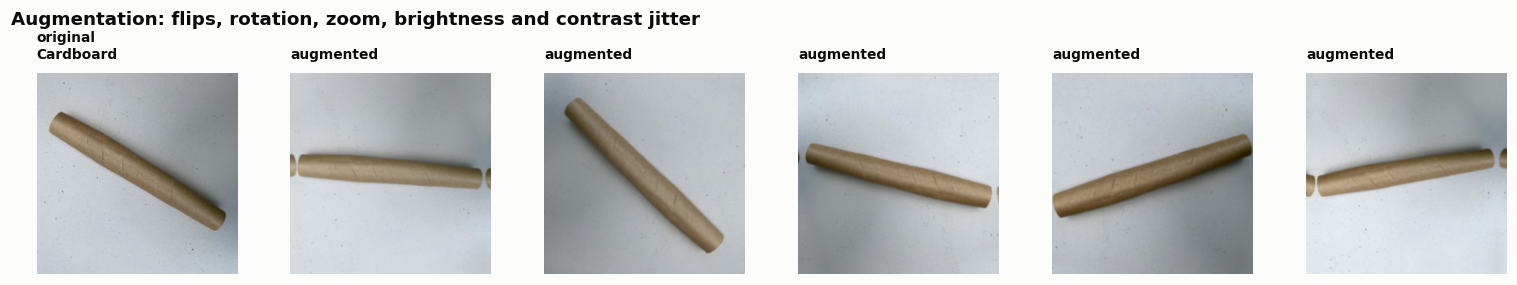

class weights (inverse frequency, normalised):
  Cardboard              1.14
  Food Organics          1.28
  Glass                  1.27
  Metal                  0.67
  Miscellaneous Trash    1.06
  Paper                  1.06
  Plastic                0.57
  Textile Trash          1.66
  Vegetation             1.21


In [24]:
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    layers.RandomRotation(0.15, fill_mode='reflect', seed=SEED),
    layers.RandomZoom(0.15, fill_mode='reflect', seed=SEED),
    layers.RandomContrast(0.15, seed=SEED),
    layers.RandomBrightness(0.10, value_range=(0, 255), seed=SEED),
], name='augmentation')

sample_img = tf.convert_to_tensor(
    np.asarray(Image.open(img_train.loc[0, 'path']).resize((IMG_WIDTH, IMG_HEIGHT)),
               dtype=np.float32))
fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
axes[0].imshow(sample_img.numpy().astype('uint8'))
axes[0].set_title(f"original\n{img_train.loc[0, 'label']}", fontsize=9)
for ax in axes[1:]:
    aug = augment(tf.expand_dims(sample_img, 0), training=True)[0]
    ax.imshow(tf.clip_by_value(aug, 0, 255).numpy().astype('uint8'))
    ax.set_title('augmented', fontsize=9)
for ax in axes:
    ax.axis('off')
fig.suptitle('Augmentation: flips, rotation, zoom, brightness and contrast jitter',
             x=0.006, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Class weights for the 2.9:1 imbalance found in Part 1 (Finding 1).
class_weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES),
                                     y=img_train['label_idx'].to_numpy())
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(class_weights)}
print('class weights (inverse frequency, normalised):')
for i, c in enumerate(CLASS_NAMES):
    print(f'  {c:<22} {CLASS_WEIGHT[i]:.2f}')

### 2.2 Choosing a backbone: a frozen-feature probe

MobileNetV2 and EfficientNetB0 are both ~5M-parameter ImageNet models with a 1280-dimensional
pooled embedding, and both are plausible here. Rather than fine-tune both on CPU — hours of
compute for one decision — each backbone's **frozen** embeddings are extracted once and a
multinomial logistic regression is fitted on them. That measures the quality of the features
the backbone already has, which is what transfer learning depends on, and it costs ~2 minutes
per candidate.

In [25]:
def extract_features(backbone, preprocess, frame, batch=48):
    """Pooled embeddings for every row of `frame`, in order, with no augmentation."""
    out = []
    for s in range(0, len(frame), batch):
        batch_paths = frame['path'].iloc[s:s + batch]
        arr = np.stack([np.asarray(Image.open(p).resize((IMG_WIDTH, IMG_HEIGHT)),
                                   dtype=np.float32) for p in batch_paths])
        out.append(backbone.predict(preprocess(arr), verbose=0))
    return np.concatenate(out)


CANDIDATES = {
    'MobileNetV2': (tf.keras.applications.MobileNetV2,
                    tf.keras.applications.mobilenet_v2.preprocess_input),
    'EfficientNetB0': (tf.keras.applications.EfficientNetB0,
                       tf.keras.applications.efficientnet.preprocess_input),
}

probe_rows, FEATURES = [], {}
for name, (ctor, prep) in CANDIDATES.items():
    t0 = time.time()
    backbone = ctor(include_top=False, weights='imagenet',
                    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), pooling='avg')
    f_tr = extract_features(backbone, prep, img_train)
    f_va = extract_features(backbone, prep, img_val)
    extract_s = time.time() - t0

    clf = LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)
    clf.fit(f_tr, img_train['label_idx'])
    pred = clf.predict(f_va)
    probe_rows.append({
        'backbone': name,
        'params (M)': backbone.count_params() / 1e6,
        'embedding': f_tr.shape[1],
        'val accuracy': accuracy_score(img_val['label_idx'], pred),
        'val macro F1': f1_score(img_val['label_idx'], pred, average='macro'),
        'extract (s)': extract_s,
    })
    FEATURES[name] = (f_tr, f_va)
    print(f'{name:<16} probed in {extract_s:.0f}s -> val acc {probe_rows[-1]["val accuracy"]:.3f}')
    release('backbone', 'clf')

probe = pd.DataFrame(probe_rows).set_index('backbone')
probe.round(3)

MobileNetV2      probed in 96s -> val acc 0.819


EfficientNetB0   probed in 113s -> val acc 0.890


,params (M),embedding,val accuracy,val macro F1,extract (s)
backbone,,,,,
MobileNetV2,2.258,1280,0.819,0.826,96.461
EfficientNetB0,4.050,1280,0.890,0.894,112.605


In [26]:
BACKBONE_NAME = probe['val macro F1'].idxmax()
print(f'selected backbone: {BACKBONE_NAME}')
F_TRAIN, F_VAL = FEATURES[BACKBONE_NAME]
y_train = img_train['label_idx'].to_numpy()
y_val = img_val['label_idx'].to_numpy()
y_test = img_test['label_idx'].to_numpy()

selected backbone: EfficientNetB0


### 2.3 Sizing the classification head on cached features

The head is the only part learned from scratch, and its width, dropout and L2 are exactly the
knobs the lab asks to tune. Tuning them on the **cached embeddings** costs seconds per
configuration instead of three minutes per epoch, because the frozen backbone never has to run
again — and a head trained on frozen features is mathematically the same object as stage-1
transfer learning without augmentation. Six configurations are compared, from a bare linear
probe to a two-layer head, on the validation split.

In [27]:
def build_head(units=(256,), dropout=0.4, l2=1e-4, in_dim=1280, name='head'):
    """Dense head over pooled CNN features. `units=()` gives a plain linear probe."""
    seq = [layers.Input(shape=(in_dim,))]
    for i, u in enumerate(units):
        seq += [layers.Dense(u, use_bias=False, kernel_regularizer=regularizers.l2(l2),
                             name=f'{name}_dense{i}'),
                layers.BatchNormalization(name=f'{name}_bn{i}'),
                layers.Activation('relu', name=f'{name}_relu{i}'),
                layers.Dropout(dropout, seed=SEED, name=f'{name}_drop{i}')]
    seq += [layers.Dense(NUM_CLASSES, activation='softmax',
                         kernel_regularizer=regularizers.l2(l2), name=f'{name}_out')]
    return tf.keras.Sequential(seq, name=name)


HEAD_GRID = [
    {'units': (), 'dropout': 0.0, 'l2': 0.0},
    {'units': (128,), 'dropout': 0.3, 'l2': 1e-4},
    {'units': (256,), 'dropout': 0.4, 'l2': 1e-4},
    {'units': (256,), 'dropout': 0.6, 'l2': 1e-3},
    {'units': (512,), 'dropout': 0.5, 'l2': 1e-4},
    {'units': (512, 128), 'dropout': 0.4, 'l2': 1e-4},
]

grid_rows = []
for cfg in HEAD_GRID:
    tf.keras.utils.set_random_seed(SEED)
    head = build_head(**cfg, in_dim=F_TRAIN.shape[1])
    head.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = head.fit(F_TRAIN, y_train, validation_data=(F_VAL, y_val),
                    epochs=60, batch_size=64, verbose=0, class_weight=CLASS_WEIGHT,
                    callbacks=[tf.keras.callbacks.EarlyStopping(
                        monitor='val_accuracy', patience=10, restore_best_weights=True)])
    pv = head.predict(F_VAL, verbose=0)
    grid_rows.append({
        'units': str(cfg['units']) if cfg['units'] else 'linear',
        'dropout': cfg['dropout'], 'l2': cfg['l2'],
        'epochs run': len(hist.history['loss']),
        'train acc': hist.history['accuracy'][-1],
        'val acc': accuracy_score(y_val, pv.argmax(1)),
        'val macro F1': f1_score(y_val, pv.argmax(1), average='macro'),
    })
    print(f"  {grid_rows[-1]['units']:<10} drop {cfg['dropout']:.1f} l2 {cfg['l2']:.0e} -> "
          f"val acc {grid_rows[-1]['val acc']:.3f}")
    release('head')

grid = pd.DataFrame(grid_rows)
grid['overfit gap'] = grid['train acc'] - grid['val acc']
grid.sort_values('val macro F1', ascending=False).round(3)

  linear     drop 0.0 l2 0e+00 -> val acc 0.890


  (128,)     drop 0.3 l2 1e-04 -> val acc 0.903


  (256,)     drop 0.4 l2 1e-04 -> val acc 0.915


  (256,)     drop 0.6 l2 1e-03 -> val acc 0.896


  (512,)     drop 0.5 l2 1e-04 -> val acc 0.904


  (512, 128) drop 0.4 l2 1e-04 -> val acc 0.904


,units,dropout,l2,epochs run,train acc,val acc,val macro F1,overfit gap
2,"(256,)",0.4,0.000,20,0.999,0.915,0.917,0.084
5,"(512, 128)",0.4,0.000,26,0.987,0.904,0.907,0.083
1,"(128,)",0.3,0.000,38,0.996,0.903,0.905,0.094
4,"(512,)",0.5,0.000,25,0.997,0.904,0.905,0.093
3,"(256,)",0.6,0.001,21,0.969,0.896,0.896,0.073
0,linear,0.0,0.000,54,0.998,0.890,0.893,0.109


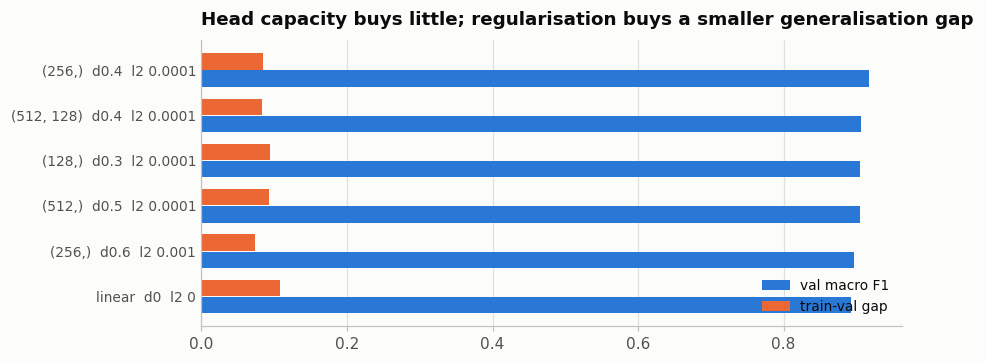

selected head: {'units': (256,), 'dropout': 0.4, 'l2': 0.0001}


In [28]:
fig, ax = plt.subplots(figsize=(8.4, 3.4))
g = grid.sort_values('val macro F1')
lbl = [f"{r.units}  d{r.dropout:g}  l2 {r.l2:g}" for r in g.itertuples()]
pos = np.arange(len(g))
ax.barh(pos - 0.19, g['val macro F1'], 0.36, color=BLUE, label='val macro F1')
ax.barh(pos + 0.19, g['overfit gap'], 0.36, color=ORANGE, label='train-val gap')
ax.set_yticks(pos); ax.set_yticklabels(lbl, fontsize=9)
ax.grid(axis='y', visible=False); ax.tick_params(axis='y', length=0)
ax.set_title('Head capacity buys little; regularisation buys a smaller generalisation gap')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

BEST_HEAD = HEAD_GRID[int(grid['val macro F1'].idxmax())]
print(f'selected head: {BEST_HEAD}')

### 2.4 Stage 1: train the head end-to-end with the backbone frozen

The grid above saw clean, un-augmented features. Stage 1 re-trains the chosen head inside the
full model, where augmentation is live, so the head learns to tolerate the jitter the real
pipeline will produce. The backbone stays frozen, which keeps the ImageNet features intact
while the randomly-initialised head is still producing large, destructive gradients.

In [29]:
def build_model(head_cfg, trainable_base=False, backbone_name=BACKBONE_NAME):
    """Full classifier: augmentation -> scaling -> backbone -> head, all in one artefact."""
    ctor, _ = CANDIDATES[backbone_name]
    base = ctor(include_top=False, weights='imagenet',
                input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), pooling='avg')
    base.trainable = trainable_base
    scale = (layers.Rescaling(1 / 127.5, offset=-1, name='preprocess')
             if backbone_name == 'MobileNetV2' else layers.Lambda(lambda z: z, name='preprocess'))

    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name='image')
    x = augment(inputs)
    x = scale(x)
    x = base(x, training=False)          # keep BatchNorm in inference mode (standard recipe)
    head = build_head(**head_cfg, in_dim=base.output_shape[-1])
    outputs = head(x)
    return tf.keras.Model(inputs, outputs, name=f'{backbone_name.lower()}_waste'), base, head


tf.keras.utils.set_random_seed(SEED)
model, base_model, head_model = build_model(BEST_HEAD, trainable_base=False)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
              metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2')])
print(f'trainable parameters: {int(sum(np.prod(w.shape) for w in model.trainable_weights)):,} '
      f'of {model.count_params():,}')
model.summary(line_length=96)

trainable parameters: 330,505 of 4,380,588
Model: "efficientnetb0_waste"


________________________________________________________________________________________________


 Layer (type)                              Output Shape                          Param #        


 image (InputLayer)                        [(None, 224, 224, 3)]                 0              


 augmentation (Sequential)                 (None, 224, 224, 3)                   0              


...

 head (Sequential)                         (None, 9)                             331017         


Total params: 4380588 (16.71 MB)


Trainable params: 330505 (1.26 MB)


Non-trainable params: 4050083 (15.45 MB)


________________________________________________________________________________________________


In [30]:
# Label smoothing (0.05) is a second regulariser alongside dropout and L2: with genuinely
# ambiguous photographs (a soiled cardboard tray is defensibly Misc. Trash) forcing the model
# to 1.0 confidence on a single stream is the wrong target.
EPOCHS_S1 = 5
t0 = time.time()
hist1 = model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_S1,
                  class_weight=CLASS_WEIGHT, verbose=2,
                  callbacks=[tf.keras.callbacks.ModelCheckpoint(
                      'cnn_stage1.weights.h5', save_weights_only=True,
                      monitor='val_accuracy', save_best_only=True)])
print(f'stage 1 finished in {(time.time() - t0) / 60:.1f} min')
model.load_weights('cnn_stage1.weights.h5')
s1_eval = model.evaluate(ds_val, verbose=0, return_dict=True)
print({k: round(v, 4) for k, v in s1_eval.items()})

Epoch 1/5


104/104 - 75s - loss: 1.2104 - accuracy: 0.6445 - top2: 0.8042 - val_loss: 0.8663 - val_accuracy: 0.7883 - val_top2: 0.9192 - 75s/epoch - 722ms/step


Epoch 2/5


104/104 - 57s - loss: 0.8121 - accuracy: 0.8024 - top2: 0.9284 - val_loss: 0.8189 - val_accuracy: 0.8106 - val_top2: 0.9401 - 57s/epoch - 544ms/step


Epoch 3/5


...

104/104 - 53s - loss: 0.6885 - accuracy: 0.8623 - top2: 0.9537 - val_loss: 0.7461 - val_accuracy: 0.8468 - val_top2: 0.9582 - 53s/epoch - 513ms/step


Epoch 5/5


104/104 - 53s - loss: 0.6535 - accuracy: 0.8710 - top2: 0.9660 - val_loss: 0.7502 - val_accuracy: 0.8482 - val_top2: 0.9485 - 53s/epoch - 510ms/step


stage 1 finished in 4.9 min


{'loss': 0.7502, 'accuracy': 0.8482, 'top2': 0.9485}


### 2.5 Stage 2: fine-tune the top of the backbone

ImageNet's later blocks encode object-level concepts (dog faces, car wheels) that are not what
separates crushed cardboard from crushed paper; its early blocks encode edges and textures that
very much are. Fine-tuning therefore unfreezes only the **last 40 layers** and drops the
learning rate by 100x, so the pre-trained features are nudged rather than overwritten.
BatchNorm layers stay frozen — with batches of 32 their running statistics are noisy, and
updating them is the most common way fine-tuning collapses.

In [31]:
UNFREEZE_LAST = 40
base_model.trainable = True
for lyr in base_model.layers[:-UNFREEZE_LAST]:
    lyr.trainable = False
for lyr in base_model.layers:
    if isinstance(lyr, layers.BatchNormalization):
        lyr.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
              metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2')])
print(f'now trainable: {int(sum(np.prod(w.shape) for w in model.trainable_weights)):,} parameters '
      f'({sum(l.trainable for l in base_model.layers)} of {len(base_model.layers)} backbone layers)')

EPOCHS_S2 = 6
t0 = time.time()
hist2 = model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_S2,
                  class_weight=CLASS_WEIGHT, verbose=2,
                  callbacks=[
                      tf.keras.callbacks.ModelCheckpoint(
                          'cnn_stage2.weights.h5', save_weights_only=True,
                          monitor='val_accuracy', save_best_only=True),
                      tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3,
                                                       restore_best_weights=True),
                      tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                                           patience=2, min_lr=1e-7, verbose=1),
                  ])
print(f'stage 2 finished in {(time.time() - t0) / 60:.1f} min')
model.load_weights('cnn_stage2.weights.h5')

now trainable: 2,368,025 parameters (32 of 239 backbone layers)
Epoch 1/6


104/104 - 77s - loss: 0.5957 - accuracy: 0.9017 - top2: 0.9756 - val_loss: 0.7320 - val_accuracy: 0.8565 - val_top2: 0.9499 - lr: 1.0000e-05 - 77s/epoch - 742ms/step


Epoch 2/6


104/104 - 62s - loss: 0.5843 - accuracy: 0.9119 - top2: 0.9771 - val_loss: 0.7288 - val_accuracy: 0.8663 - val_top2: 0.9526 - lr: 1.0000e-05 - 62s/epoch - 592ms/step


Epoch 3/6


...

Epoch 5/6


104/104 - 65s - loss: 0.5616 - accuracy: 0.9233 - top2: 0.9850 - val_loss: 0.7098 - val_accuracy: 0.8691 - val_top2: 0.9554 - lr: 1.0000e-05 - 65s/epoch - 627ms/step


Epoch 6/6


104/104 - 77s - loss: 0.5485 - accuracy: 0.9221 - top2: 0.9826 - val_loss: 0.7113 - val_accuracy: 0.8719 - val_top2: 0.9568 - lr: 1.0000e-05 - 77s/epoch - 743ms/step


stage 2 finished in 6.8 min


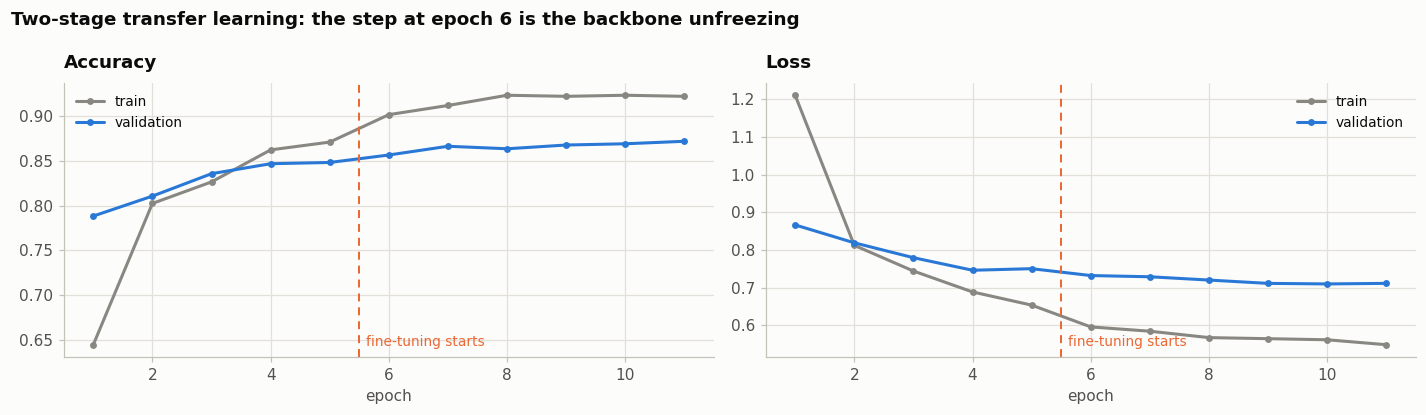

stage 1 best val accuracy: 0.848
stage 2 best val accuracy: 0.872  (+0.024)


In [32]:
h = {k: hist1.history[k] + hist2.history[k] for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']}
ep = np.arange(1, len(h['accuracy']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, (a, b, title) in zip(axes, [('accuracy', 'val_accuracy', 'Accuracy'),
                                    ('loss', 'val_loss', 'Loss')]):
    ax.plot(ep, h[a], color=MUTED, marker='o', ms=3.5, label='train')
    ax.plot(ep, h[b], color=BLUE, marker='o', ms=3.5, label='validation')
    ax.axvline(EPOCHS_S1 + 0.5, color=ORANGE, lw=1.3, ls=(0, (4, 3)))
    ax.text(EPOCHS_S1 + 0.62, ax.get_ylim()[0] + 0.04 * np.ptp(ax.get_ylim()),
            'fine-tuning starts', color=ORANGE, fontsize=9)
    ax.set_title(title); ax.set_xlabel('epoch'); ax.legend()
fig.suptitle('Two-stage transfer learning: the step at epoch 6 is the backbone unfreezing',
             x=0.006, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"stage 1 best val accuracy: {max(hist1.history['val_accuracy']):.3f}")
print(f"stage 2 best val accuracy: {max(hist2.history['val_accuracy']):.3f}  "
      f"(+{max(hist2.history['val_accuracy']) - max(hist1.history['val_accuracy']):.3f})")

### 2.6 Test-set evaluation and error analysis

In [33]:
proba_test = model.predict(ds_test, verbose=0)
pred_test = proba_test.argmax(1)
conf_test = proba_test.max(1)

cnn_acc = accuracy_score(y_test, pred_test)
cnn_f1 = f1_score(y_test, pred_test, average='macro')
cnn_top2 = float(np.mean([y in np.argsort(-p)[:2] for y, p in zip(y_test, proba_test)]))
print(f'TEST  accuracy {cnn_acc:.3f} | macro F1 {cnn_f1:.3f} | top-2 accuracy {cnn_top2:.3f} '
      f'| n = {len(y_test)}')
print(f'majority-class baseline {max(np.bincount(y_test)) / len(y_test):.3f}\n')
print(classification_report(y_test, pred_test, target_names=CLASS_NAMES, digits=3))

TEST  accuracy 0.866 | macro F1 0.873 | top-2 accuracy 0.935 | n = 709
majority-class baseline 0.195

                     precision    recall  f1-score   support

          Cardboard      0.756     0.899     0.821        69
      Food Organics      0.881     0.967     0.922        61
              Glass      0.879     0.951     0.913        61
              Metal      0.841     0.898     0.869       118
Miscellaneous Trash      0.887     0.743     0.809        74
              Paper      0.929     0.867     0.897        75
            Plastic      0.863     0.775     0.817       138
      Textile Trash      0.860     0.896     0.878        48
         Vegetation      0.952     0.908     0.929        65

           accuracy                          0.866       709
          macro avg      0.872     0.878     0.873       709
       weighted avg      0.869     0.866     0.865       709



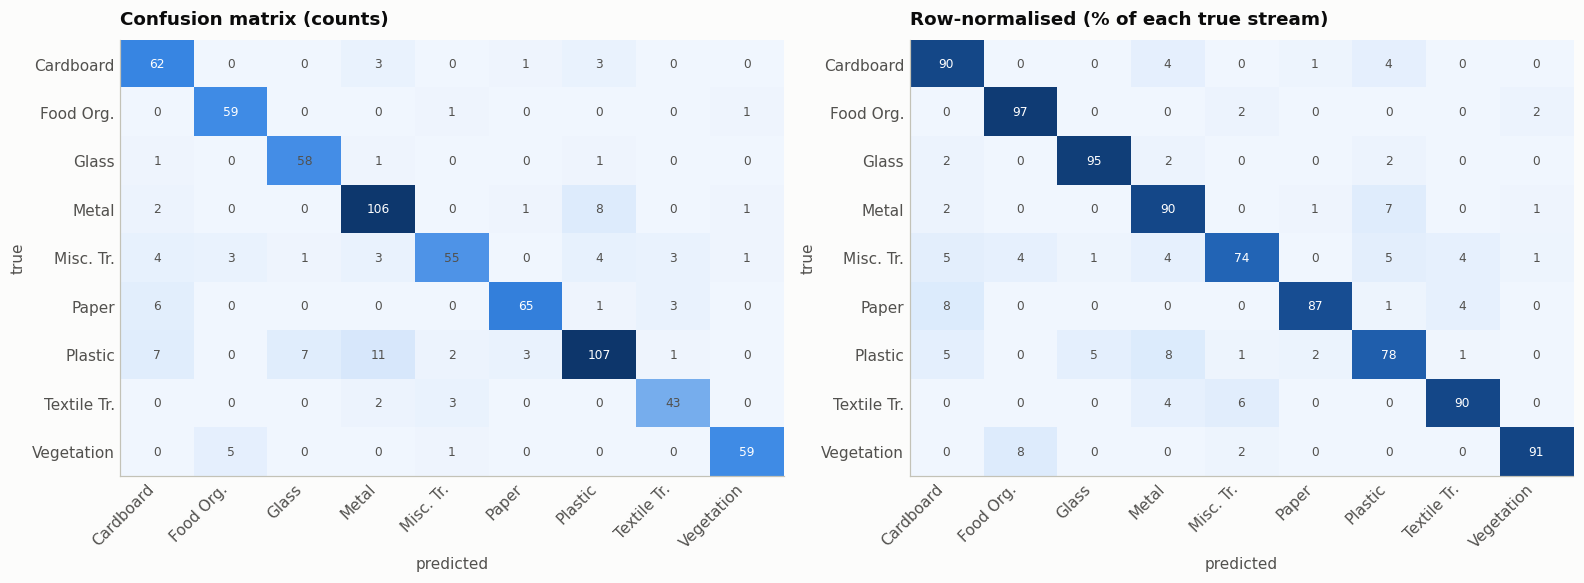

Largest confusions (true -> predicted):
  Plastic               -> Metal                  11 images (8% of Plastic)
  Metal                 -> Plastic                 8 images (7% of Metal)
  Plastic               -> Cardboard               7 images (5% of Plastic)
  Plastic               -> Glass                   7 images (5% of Plastic)
  Paper                 -> Cardboard               6 images (8% of Paper)
  Vegetation            -> Food Organics           5 images (8% of Vegetation)
  Miscellaneous Trash   -> Cardboard               4 images (5% of Miscellaneous Trash)
  Miscellaneous Trash   -> Plastic                 4 images (5% of Miscellaneous Trash)


In [34]:
cm = confusion_matrix(y_test, pred_test)
cm_norm = cm / cm.sum(1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4), gridspec_kw={'width_ratios': [1, 1]})
heat(axes[0], cm, [SHORT[c] for c in CLASS_NAMES], [SHORT[c] for c in CLASS_NAMES],
     title='Confusion matrix (counts)', fmt='{:.0f}')
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('true')
heat(axes[1], cm_norm * 100, [SHORT[c] for c in CLASS_NAMES], [SHORT[c] for c in CLASS_NAMES],
     title='Row-normalised (% of each true stream)', fmt='{:.0f}', vmax=100)
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('true')
plt.tight_layout(); plt.show()

off = [(CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j], cm_norm[i, j])
       for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j and cm[i, j] > 0]
off.sort(key=lambda r: -r[2])
print('Largest confusions (true -> predicted):')
for t, p, n, frac in off[:8]:
    print(f'  {t:<21} -> {p:<21} {n:>3} images ({frac:.0%} of {t})')

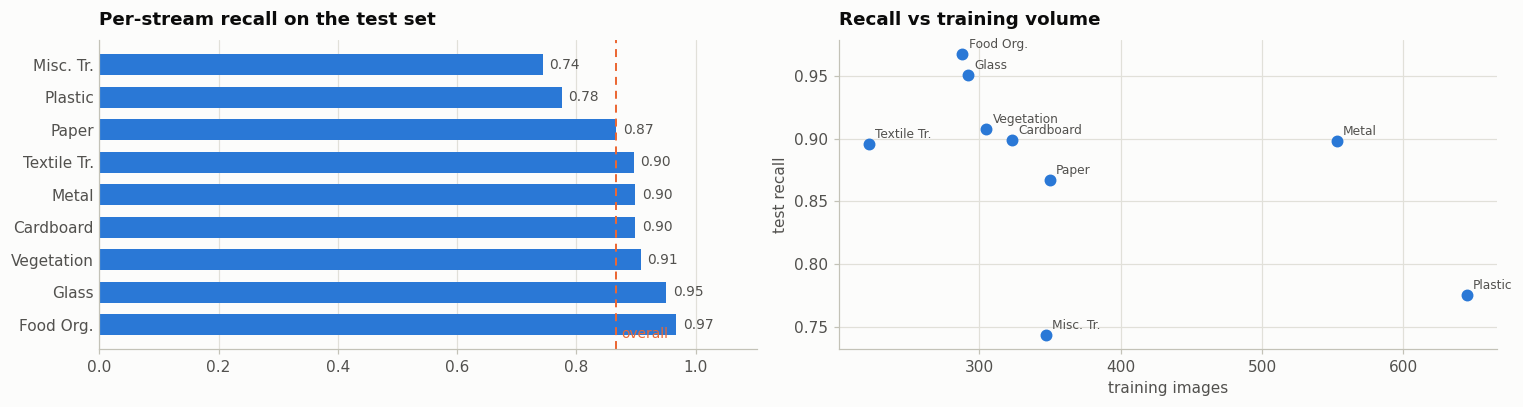

correlation between training volume and recall: -0.49   (if this is not positive, imbalance is not what limits the weak streams)
correlation between edge density and recall:    0.24


,recall,precision,test images,train images,edge density
Cardboard,0.899,0.756,69,323,11.741
Food Organics,0.967,0.881,61,288,19.529
Glass,0.951,0.879,61,292,9.083
Metal,0.898,0.841,118,553,12.588
Miscellaneous Trash,0.743,0.887,74,347,13.285
Paper,0.867,0.929,75,350,12.800
Plastic,0.775,0.863,138,645,11.935
Textile Trash,0.896,0.860,48,222,12.728
Vegetation,0.908,0.952,65,305,22.382


In [35]:
per_class = pd.DataFrame({
    'recall': cm.diagonal() / cm.sum(1),
    'precision': np.divide(cm.diagonal(), cm.sum(0), out=np.zeros(NUM_CLASSES), where=cm.sum(0) > 0),
    'test images': cm.sum(1),
    'train images': [int((img_train['label'] == c).sum()) for c in CLASS_NAMES],
    'edge density': [char.loc[c, 'edge_density'] for c in CLASS_NAMES],
}, index=CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
s = per_class['recall'].sort_values()
barh(axes[0], [SHORT[c] for c in s.index], s.values, title='Per-stream recall on the test set',
     fmt='{:.2f}')
axes[0].axvline(cnn_acc, color=ORANGE, lw=1.3, ls=(0, (4, 3)))
axes[0].text(cnn_acc + 0.01, 8.4, 'overall', color=ORANGE, fontsize=9)
axes[1].scatter(per_class['train images'], per_class['recall'], s=46, color=BLUE, zorder=3)
for c, r in per_class.iterrows():
    axes[1].annotate(SHORT[c], (r['train images'], r['recall']), fontsize=8, color=INK_2,
                     xytext=(4, 4), textcoords='offset points')
axes[1].set_xlabel('training images'); axes[1].set_ylabel('test recall')
axes[1].set_title('Recall vs training volume')
plt.tight_layout(); plt.show()

print(f"correlation between training volume and recall: "
      f"{per_class['train images'].corr(per_class['recall']):.2f}   "
      f"(if this is not positive, imbalance is not what limits the weak streams)")
print(f"correlation between edge density and recall:    "
      f"{per_class['edge density'].corr(per_class['recall']):.2f}")
per_class.round(3)

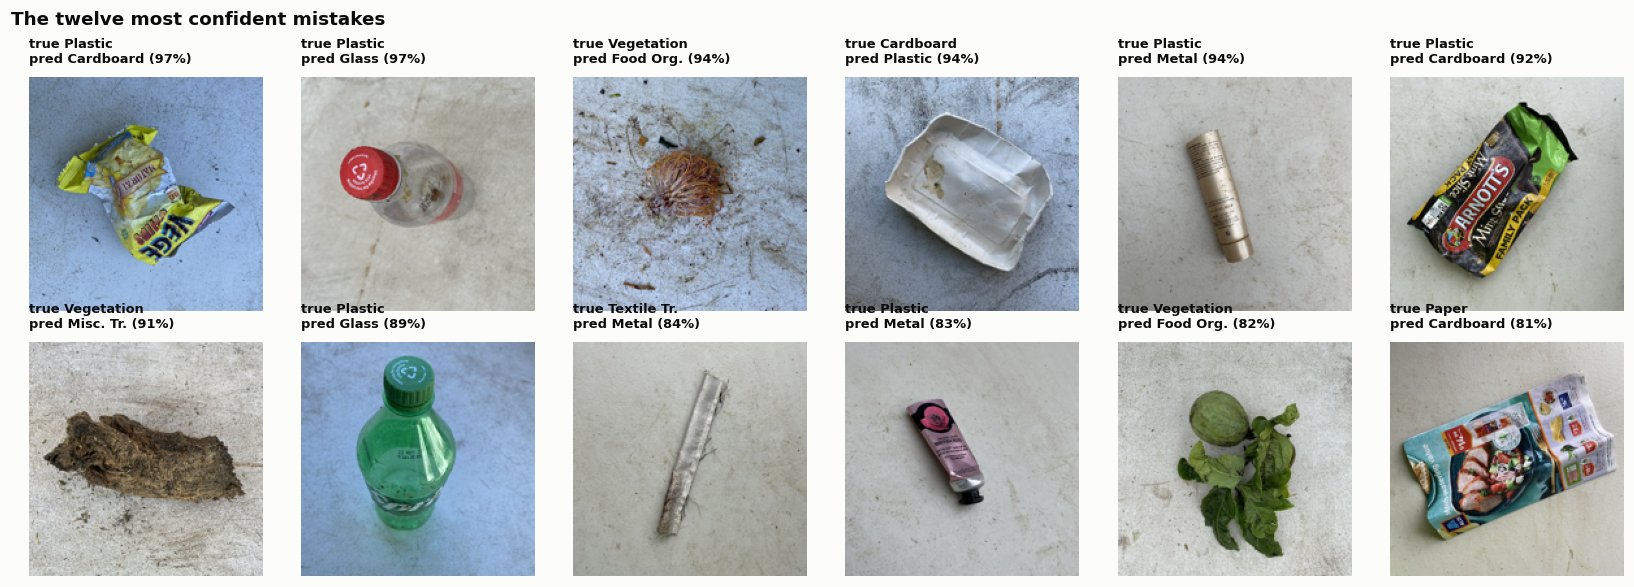

mean confidence when right: 0.870
mean confidence when wrong: 0.618


In [36]:
# What the mistakes look like. Confident errors are the product risk: the assistant will state
# a wrong bin without hedging, which is worse than saying "I am not sure".
err_idx = np.where(pred_test != y_test)[0]
order = err_idx[np.argsort(-conf_test[err_idx])]
fig, axes = plt.subplots(2, 6, figsize=(15, 5.4))
for ax, k in zip(axes.ravel(), order[:12]):
    ax.imshow(Image.open(img_test.loc[k, 'path']).resize((180, 180)))
    ax.set_title(f'true {SHORT[CLASS_NAMES[y_test[k]]]}\npred {SHORT[CLASS_NAMES[pred_test[k]]]} '
                 f'({conf_test[k]:.0%})', fontsize=8.5)
    ax.axis('off')
fig.suptitle('The twelve most confident mistakes', x=0.006, ha='left', fontsize=12,
             fontweight='bold')
plt.tight_layout(); plt.show()

print(f'mean confidence when right: {conf_test[pred_test == y_test].mean():.3f}')
print(f'mean confidence when wrong: {conf_test[pred_test != y_test].mean():.3f}')

In [37]:
# Is the confidence score usable as a gate? If accuracy rises sharply with confidence, the
# assistant can abstain on low-confidence photos instead of guessing (used in Part 5).
bands = [(0.0, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 0.9), (0.9, 1.01)]
rows = []
for lo, hi in bands:
    m = (conf_test >= lo) & (conf_test < hi)
    rows.append({'confidence': f'{lo:.1f}-{hi:.1f}' if hi <= 1 else f'>={lo:.1f}',
                 'images': int(m.sum()), 'share': m.mean(),
                 'accuracy': accuracy_score(y_test[m], pred_test[m]) if m.sum() else np.nan})
calib = pd.DataFrame(rows)
print(calib.round(3).to_string(index=False))

CNN_CONF_THRESHOLD = 0.60
gate = conf_test >= CNN_CONF_THRESHOLD
gated_acc = accuracy_score(y_test[gate], pred_test[gate]) if gate.any() else float('nan')
print(f'\nabstaining below {CNN_CONF_THRESHOLD:.2f}: answers {gate.mean():.0%} of photos '
      f'at {gated_acc:.3f} accuracy, defers {1 - gate.mean():.0%} to the text route')

confidence  images  share  accuracy
   0.0-0.4      20  0.028     0.500
   0.4-0.6      86  0.121     0.605
   0.6-0.8     116  0.164     0.672
   0.8-0.9      99  0.140     0.939
     >=0.9     388  0.547     0.982

abstaining below 0.60: answers 85% of photos at 0.915 accuracy, defers 15% to the text route


In [38]:
cnn_summary = pd.DataFrame([
    {'stage': 'majority class', 'val accuracy': np.nan,
     'test accuracy': max(np.bincount(y_test)) / len(y_test), 'test macro F1': np.nan},
    {'stage': f'{BACKBONE_NAME} frozen features + logistic regression',
     'val accuracy': probe.loc[BACKBONE_NAME, 'val accuracy'],
     'test accuracy': np.nan, 'test macro F1': np.nan},
    {'stage': 'stage 1: frozen backbone + tuned head',
     'val accuracy': max(hist1.history['val_accuracy']), 'test accuracy': np.nan,
     'test macro F1': np.nan},
    {'stage': f'stage 2: fine-tuned top {UNFREEZE_LAST} layers',
     'val accuracy': max(hist2.history['val_accuracy']), 'test accuracy': cnn_acc,
     'test macro F1': cnn_f1},
]).set_index('stage')
cnn_summary.round(3)

,val accuracy,test accuracy,test macro F1
stage,,,
majority class,NaN,0.195,NaN
EfficientNetB0 frozen features + logistic regression,0.890,NaN,NaN
stage 1: frozen backbone + tuned head,0.848,NaN,NaN
stage 2: fine-tuned top 40 layers,0.872,0.866,0.873


One row of that table deserves an explanation, because it looks like a regression: the
frozen-feature probe scores **higher** on validation than stage 1 does. They are not
measuring the same thing. The probe fits a convex solver to run convergence on clean,
un-augmented embeddings — the easiest version of the problem, and an optimistic number. Stage
1 trains the same head by SGD for five epochs on *augmented* inputs, which is harder and is
the point: those five epochs are what make the head robust enough for the backbone to be
unfrozen underneath it without the gradients tearing the ImageNet features apart. Stage 2
then passes both.

### Part 2 takeaways

Three things in the evaluation above are worth more than the headline accuracy.

**The errors are structured, not random.** They concentrate among the *container* streams —
plastic, metal and glass — which is exactly right: a crushed drink container photographed on
a tipping floor shows its shape, not its material, and the label depends on the material.
Paper against cardboard is the same story in fibre. Miscellaneous Trash is the hardest stream
by construction rather than by appearance: it is defined by *not* being one of the other
eight, so there is no visual property for a convolutional network to converge on.

**Training volume does not predict recall** — the correlation printed above is negative. The
two largest streams, Plastic and Metal, are among the weakest, and the smallest (Textile
Trash) is not. That rules out imbalance as the binding constraint and points at
confusability instead, which is why the response is class weighting plus macro F1 rather than
a larger resampling effort.

**Confidence is informative**, and the calibration table is the evidence: accuracy climbs
steeply with the softmax maximum. That is what makes the gate in Part 5 defensible rather
than decorative — the assistant can answer the large, reliable majority of photographs and
ask for a written description on the rest, instead of guessing uniformly.

For the product, *which* errors happen matters as much as how many. A paper/cardboard mix-up
is nearly harmless because both go to the fibre stream; predicting Plastic for miscellaneous
trash puts a non-recyclable item into a recycling load and contaminates it. An
error-cost-weighted loss would be the principled next step, and it needs the facility's
contamination costs, which EcoSort does not have yet.

## Part 3: Waste description classification

The text route exists for the cases the camera cannot settle: an item inside a bag, a photo
too dark to use, or a resident who would rather type. The input is one short sentence
(`"wrinkled pink takeout container with product remaining"`) and the output is the same nine
streams the CNN produces, so the two routes are interchangeable from Part 5's point of view.

Part 1 established two things that shape this part. The auxiliary columns are the label in
disguise, so only `description` is used (Finding 3). And 17% of descriptions contain no
stream-exclusive word, which is where the real difficulty lives (Finding 4) — so **both**
options the lab offers are built, a sparse linear model and a fine-tuned transformer, and
they are compared on that subset specifically rather than on the headline number alone.

### 3.1 Features for the sparse models

Two views of each description are concatenated:

- **Word 1–2 grams.** Bigrams matter because the stream is often carried by a pair:
  `"paper towel"` is Textile Trash while `"paper"` alone is Paper, and `"glass cup"` is
  Miscellaneous Trash while `"glass bottle"` is Glass.
- **Character 3–5 grams (`char_wb`).** These catch the compound and hyphenated forms the
  templates produce (`"plastic-metal composite"`, `"fun-sized"`) and give the model partial
  credit on a word it has never seen in full, which is the closest a bag-of-words model gets
  to handling the unseen vocabulary a real resident would type.

No stemming and no stop-word list: at a median of five words there is nothing to prune, and
`"with food residue"` is a signal, not filler.

In [39]:
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), sublinear_tf=True, min_df=2)
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), sublinear_tf=True, min_df=3)

from sklearn.pipeline import FeatureUnion
TEXT_FEATURES = FeatureUnion([('word', word_vec), ('char', char_vec)])

Xtr_text, ytr_text = txt_train['clean'].to_numpy(), txt_train['category'].to_numpy()
Xva_text, yva_text = txt_val['clean'].to_numpy(), txt_val['category'].to_numpy()
Xte_text, yte_text = txt_test['clean'].to_numpy(), txt_test['category'].to_numpy()

Xtr_vec = TEXT_FEATURES.fit_transform(Xtr_text)
Xva_vec = TEXT_FEATURES.transform(Xva_text)
Xte_vec = TEXT_FEATURES.transform(Xte_text)
print(f'TF-IDF matrix: {Xtr_vec.shape[0]:,} x {Xtr_vec.shape[1]:,} features '
      f'({TEXT_FEATURES.transformer_list[0][1].vocabulary_.__len__():,} word n-grams + '
      f'{TEXT_FEATURES.transformer_list[1][1].vocabulary_.__len__():,} character n-grams)')
print(f'density: {Xtr_vec.nnz / np.prod(Xtr_vec.shape):.3%} non-zero, '
      f'{Xtr_vec.nnz / Xtr_vec.shape[0]:.0f} active features per description')

TF-IDF matrix: 3,431 x 5,470 features (2,181 word n-grams + 3,289 character n-grams)
density: 1.430% non-zero, 78 active features per description


### 3.2 Option A: sparse linear and tree baselines

Four classifiers over those features, scored with 5-fold stratified cross-validation on the
training split so the ranking does not depend on one lucky validation draw. The point of the
exercise is not only to pick a winner but to see how much headroom a transformer could
possibly have.

In [40]:
BASELINES = {
    'Multinomial NB (alpha=0.1)': MultinomialNB(alpha=0.1),
    'Logistic regression (C=10)': LogisticRegression(C=10, max_iter=3000, n_jobs=-1),
    'Linear SVM (C=1)': LinearSVC(C=1.0),
    'Random forest (400 trees)': RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                                        random_state=SEED),
}

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
base_rows = []
for name, clf in BASELINES.items():
    t0 = time.time()
    scores = cross_val_score(clf, Xtr_vec, ytr_text, cv=cv, scoring='f1_macro', n_jobs=1)
    clf.fit(Xtr_vec, ytr_text)
    pv = clf.predict(Xva_vec)
    base_rows.append({'model': name, 'cv macro F1': scores.mean(), 'cv sd': scores.std(),
                      'val accuracy': accuracy_score(yva_text, pv),
                      'val macro F1': f1_score(yva_text, pv, average='macro'),
                      'fit (s)': time.time() - t0})
    print(f'  {name:<28} cv F1 {scores.mean():.3f} +/- {scores.std():.3f} | '
          f'val acc {base_rows[-1]["val accuracy"]:.3f}')

baselines = pd.DataFrame(base_rows).set_index('model')
baselines.round(3)

  Multinomial NB (alpha=0.1)   cv F1 0.991 +/- 0.004 | val acc 0.996


  Logistic regression (C=10)   cv F1 0.999 +/- 0.002 | val acc 1.000


  Linear SVM (C=1)             cv F1 1.000 +/- 0.001 | val acc 1.000


  Random forest (400 trees)    cv F1 0.971 +/- 0.006 | val acc 0.970


,cv macro F1,cv sd,val accuracy,val macro F1,fit (s)
model,,,,,
Multinomial NB (alpha=0.1),0.991,0.004,0.996,0.996,0.079
Logistic regression (C=10),0.999,0.002,1.000,1.000,9.677
Linear SVM (C=1),1.000,0.001,1.000,1.000,0.611
Random forest (400 trees),0.971,0.006,0.970,0.970,21.610


Logistic regression is the sparse model carried forward even if the linear SVM edges it on
F1, because the assistant needs **calibrated probabilities**: the confidence gate in Part 5
and the top-3 alternatives both require `predict_proba`, and `LinearSVC` only produces
decision-function margins. The sweep below quantifies what that choice costs.

best cross-validated model: Linear SVM (C=1) (1.000)
logistic regression:        0.999 - the gap is the price of calibrated probabilities



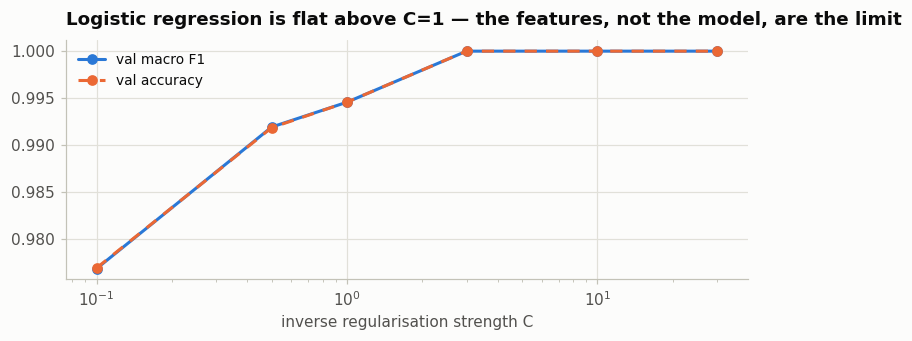

selected C = 3


In [41]:
print(f"best cross-validated model: {baselines['cv macro F1'].idxmax()} "
      f"({baselines['cv macro F1'].max():.3f})")
print(f"logistic regression:        {baselines.loc['Logistic regression (C=10)', 'cv macro F1']:.3f} "
      f"- the gap is the price of calibrated probabilities\n")

# Regularisation sweep: how much does C matter?
sweep = []
for C in [0.1, 0.5, 1, 3, 10, 30]:
    clf = LogisticRegression(C=C, max_iter=3000, n_jobs=-1).fit(Xtr_vec, ytr_text)
    pv = clf.predict(Xva_vec)
    sweep.append({'C': C, 'val accuracy': accuracy_score(yva_text, pv),
                  'val macro F1': f1_score(yva_text, pv, average='macro')})
sweep = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.semilogx(sweep['C'], sweep['val macro F1'], marker='o', color=BLUE, label='val macro F1')
ax.semilogx(sweep['C'], sweep['val accuracy'], marker='o', color=ORANGE, ls=(0, (4, 3)),
            label='val accuracy')
ax.set_xlabel('inverse regularisation strength C')
ax.set_title('Logistic regression is flat above C=1 — the features, not the model, are the limit')
ax.legend()
plt.tight_layout(); plt.show()

BEST_C = float(sweep.loc[sweep['val macro F1'].idxmax(), 'C'])
tfidf_clf = LogisticRegression(C=BEST_C, max_iter=3000, n_jobs=-1).fit(Xtr_vec, ytr_text)
print(f'selected C = {BEST_C:g}')

### 3.3 Option B: fine-tuning DistilBERT

DistilBERT is a 66M-parameter distilled BERT — six transformer layers instead of twelve, ~60%
of the runtime, within a point or two of BERT on most classification benchmarks. It is chosen
over BERT-base here for one practical reason (this is a CPU-only machine) and one principled
one: with 3,431 training sentences of five words each, the limiting factor is data, not model
capacity.

**All layers are fine-tuned**, not just the classification head. Freezing the encoder would
turn DistilBERT into a slower, worse version of the TF-IDF model; the entire reason to reach
for a transformer here is that its attention can let `"bottle"` mean different things
depending on whether `"glass"`, `"soda"` or `"aluminum"` sits next to it — and that needs
gradient to flow through the encoder.

Sequences are capped at 24 word-pieces (the longest cleaned description is well inside that),
which is what keeps CPU fine-tuning to a few minutes per epoch.

In [42]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

torch.manual_seed(SEED)
torch.set_num_threads(os.cpu_count() or 4)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME, MAX_LEN = 'distilbert-base-uncased', 24
LABEL2ID = {c: i for i, c in enumerate(CLASS_NAMES)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tokenizer.tokenize(t)) for t in Xtr_text]
print(f'word-piece lengths: median {np.median(lengths):.0f}, 99th pct {np.percentile(lengths, 99):.0f}, '
      f'max {max(lengths)} -> MAX_LEN {MAX_LEN} truncates {np.mean(np.array(lengths) > MAX_LEN):.2%}')


def encode(texts, labels=None):
    enc = tokenizer(list(texts), truncation=True, max_length=MAX_LEN,
                    padding='max_length', return_tensors='pt')
    tensors = [enc['input_ids'], enc['attention_mask']]
    if labels is not None:
        tensors.append(torch.tensor([LABEL2ID[c] for c in labels]))
    return TensorDataset(*tensors)


train_loader = DataLoader(encode(Xtr_text, ytr_text), batch_size=32, shuffle=True)
val_loader = DataLoader(encode(Xva_text, yva_text), batch_size=64)
test_loader = DataLoader(encode(Xte_text, yte_text), batch_size=64)
print(f'{len(train_loader)} training batches of 32 on {DEVICE}')

word-piece lengths: median 5, 99th pct 11, max 14 -> MAX_LEN 24 truncates 0.00%
108 training batches of 32 on cpu


In [43]:
@torch.no_grad()
def bert_predict(model, loader):
    """Softmax probabilities for every row of `loader`, in order."""
    model.eval()
    out = []
    for batch in loader:
        ids, mask = batch[0].to(DEVICE), batch[1].to(DEVICE)
        out.append(torch.softmax(model(input_ids=ids, attention_mask=mask).logits, -1).cpu())
    return torch.cat(out).numpy()


bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES,
    id2label={i: c for c, i in LABEL2ID.items()}, label2id=LABEL2ID).to(DEVICE)

EPOCHS_BERT, LR_BERT = 3, 3e-5
optimizer = torch.optim.AdamW(bert.parameters(), lr=LR_BERT, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS_BERT
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

bert_hist, t_start = [], time.time()
for epoch in range(1, EPOCHS_BERT + 1):
    bert.train()
    running, t0 = 0.0, time.time()
    for step, (ids, mask, y) in enumerate(train_loader, 1):
        optimizer.zero_grad()
        loss = bert(input_ids=ids.to(DEVICE), attention_mask=mask.to(DEVICE),
                    labels=y.to(DEVICE)).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running += loss.item()
    pv = bert_predict(bert, val_loader).argmax(1)
    acc = accuracy_score([LABEL2ID[c] for c in yva_text], pv)
    f1 = f1_score([LABEL2ID[c] for c in yva_text], pv, average='macro')
    bert_hist.append({'epoch': epoch, 'train loss': running / len(train_loader),
                      'val accuracy': acc, 'val macro F1': f1, 'minutes': (time.time() - t0) / 60})
    print(f'  epoch {epoch}: loss {running / len(train_loader):.4f} | val acc {acc:.4f} | '
          f'val macro F1 {f1:.4f} | {(time.time() - t0) / 60:.1f} min')

bert_hist = pd.DataFrame(bert_hist).set_index('epoch')
print(f'fine-tuned {sum(p.numel() for p in bert.parameters()) / 1e6:.0f}M parameters in '
      f'{(time.time() - t_start) / 60:.1f} minutes')
bert_hist.round(4)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  epoch 1: loss 1.3904 | val acc 0.9823 | val macro F1 0.9827 | 2.5 min


  epoch 2: loss 0.1019 | val acc 1.0000 | val macro F1 1.0000 | 2.5 min


  epoch 3: loss 0.0273 | val acc 1.0000 | val macro F1 1.0000 | 2.4 min
fine-tuned 67M parameters in 7.3 minutes


,train loss,val accuracy,val macro F1,minutes
epoch,,,,
1,1.3904,0.9823,0.9827,2.4959
2,0.1019,1.0000,1.0000,2.4652
3,0.0273,1.0000,1.0000,2.3620


### 3.4 Evaluation and error analysis

Both models are scored on the untouched test split, overall and on the ambiguous subset from
Finding 4 — the descriptions containing no word that belongs to a single stream.

In [44]:
proba_tfidf_test = tfidf_clf.predict_proba(Xte_vec)
pred_tfidf_test = tfidf_clf.classes_[proba_tfidf_test.argmax(1)]
proba_bert_test = bert_predict(bert, test_loader)
pred_bert_test = np.array([CLASS_NAMES[i] for i in proba_bert_test.argmax(1)])

hard_mask = ~txt_test['has_exclusive_token'].to_numpy()
rows = []
for name, pred in [('TF-IDF + logistic regression', pred_tfidf_test),
                   ('DistilBERT (fine-tuned)', pred_bert_test)]:
    rows.append({
        'model': name,
        'test accuracy': accuracy_score(yte_text, pred),
        'test macro F1': f1_score(yte_text, pred, average='macro'),
        f'accuracy on easy ({(~hard_mask).sum()})': accuracy_score(yte_text[~hard_mask], pred[~hard_mask]),
        f'accuracy on ambiguous ({hard_mask.sum()})': accuracy_score(yte_text[hard_mask], pred[hard_mask]),
    })
text_results = pd.DataFrame(rows).set_index('model')
print(text_results.round(4).to_string())

TEXT_MODEL = 'bert' if (text_results.iloc[1]['test macro F1'] >
                        text_results.iloc[0]['test macro F1']) else 'tfidf'
print(f'\nmodel wired into the assistant: {TEXT_MODEL}')
text_results.round(3)

                              test accuracy  test macro F1  accuracy on easy (606)  accuracy on ambiguous (130)
model                                                                                                          
TF-IDF + logistic regression         0.9932         0.9933                  0.9934                       0.9923
DistilBERT (fine-tuned)              1.0000         1.0000                  1.0000                       1.0000

model wired into the assistant: bert


,test accuracy,test macro F1,accuracy on easy (606),accuracy on ambiguous (130)
model,,,,
TF-IDF + logistic regression,0.993,0.993,0.993,0.992
DistilBERT (fine-tuned),1.000,1.000,1.000,1.000


TEST  accuracy 1.000 | macro F1 1.000 | n = 736

                     precision    recall  f1-score   support

          Cardboard      1.000     1.000     1.000        86
      Food Organics      1.000     1.000     1.000        76
              Glass      1.000     1.000     1.000        81
              Metal      1.000     1.000     1.000        75
Miscellaneous Trash      1.000     1.000     1.000        87
              Paper      1.000     1.000     1.000        74
            Plastic      1.000     1.000     1.000        82
      Textile Trash      1.000     1.000     1.000        88
         Vegetation      1.000     1.000     1.000        87

           accuracy                          1.000       736
          macro avg      1.000     1.000     1.000       736
       weighted avg      1.000     1.000     1.000       736



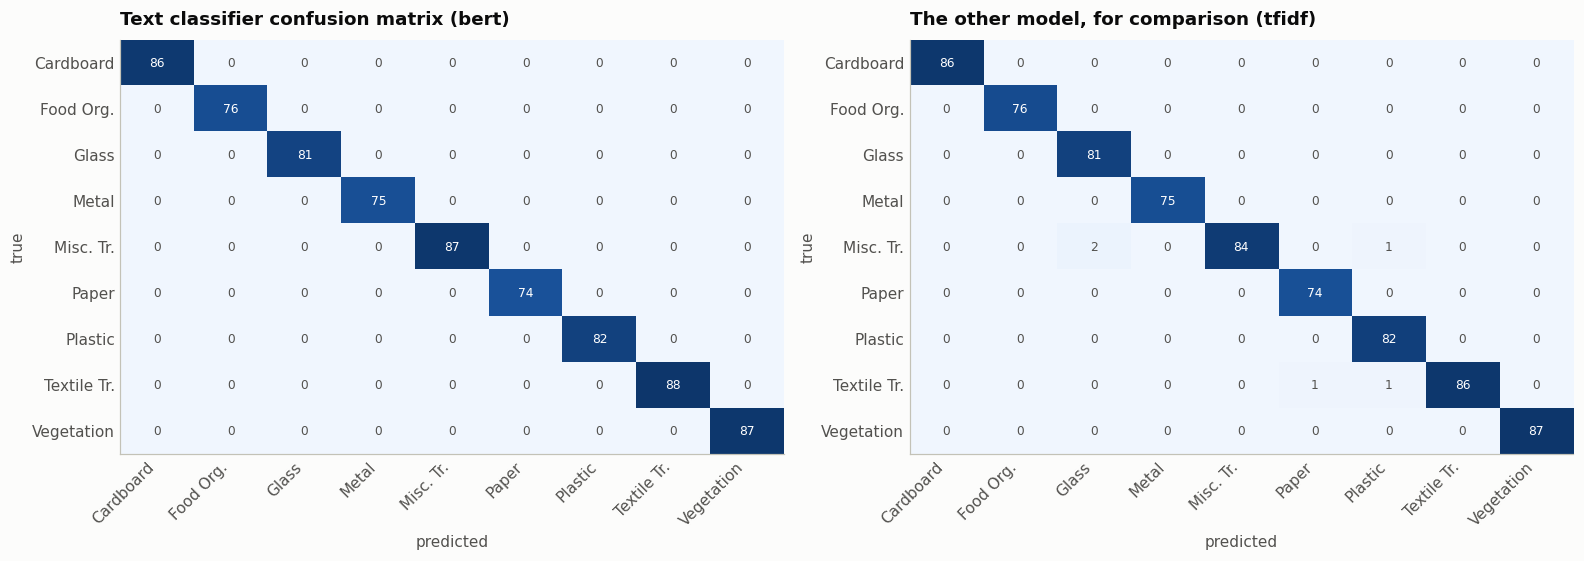

In [45]:
pred_text_test = pred_bert_test if TEXT_MODEL == 'bert' else pred_tfidf_test
proba_text_test = proba_bert_test if TEXT_MODEL == 'bert' else proba_tfidf_test
TEXT_CLASSES = CLASS_NAMES if TEXT_MODEL == 'bert' else list(tfidf_clf.classes_)

txt_acc = accuracy_score(yte_text, pred_text_test)
txt_f1 = f1_score(yte_text, pred_text_test, average='macro')
print(f'TEST  accuracy {txt_acc:.3f} | macro F1 {txt_f1:.3f} | n = {len(yte_text)}\n')
print(classification_report(yte_text, pred_text_test, digits=3))

cm_txt = confusion_matrix(yte_text, pred_text_test, labels=CLASS_NAMES)
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
heat(axes[0], cm_txt, [SHORT[c] for c in CLASS_NAMES], [SHORT[c] for c in CLASS_NAMES],
     title=f'Text classifier confusion matrix ({TEXT_MODEL})')
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('true')
cm_other = confusion_matrix(yte_text, pred_tfidf_test if TEXT_MODEL == 'bert' else pred_bert_test,
                            labels=CLASS_NAMES)
heat(axes[1], cm_other, [SHORT[c] for c in CLASS_NAMES], [SHORT[c] for c in CLASS_NAMES],
     title=f'The other model, for comparison '
           f'({"tfidf" if TEXT_MODEL == "bert" else "bert"})')
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('true')
plt.tight_layout(); plt.show()

In [46]:
# Where do the two models disagree, and who is right?
disagree = pred_tfidf_test != pred_bert_test
both_wrong = (pred_tfidf_test != yte_text) & (pred_bert_test != yte_text)
print(f'the two models disagree on {disagree.sum()} of {len(yte_text)} test descriptions '
      f'({disagree.mean():.1%})')
if disagree.any():
    print(f'  TF-IDF right, DistilBERT wrong: '
          f'{int(((pred_tfidf_test == yte_text) & disagree).sum())}')
    print(f'  DistilBERT right, TF-IDF wrong: '
          f'{int(((pred_bert_test == yte_text) & disagree).sum())}')
print(f'both wrong on the same row: {int(both_wrong.sum())} '
      f'({both_wrong.mean():.1%} of the test set is beyond both models)')

err = pd.DataFrame({
    'description': txt_test['description'].to_numpy(),
    'true': yte_text,
    'TF-IDF': pred_tfidf_test,
    'DistilBERT': pred_bert_test,
    'confidence': proba_text_test.max(1),
    'ambiguous': hard_mask,
})
sel_col = 'DistilBERT' if TEXT_MODEL == 'bert' else 'TF-IDF'
wrong = err[err[sel_col] != err['true']]
if len(wrong):
    print(f'\n{len(wrong)} errors from the selected model, most confident first:')
    show_err = wrong.sort_values('confidence', ascending=False).head(12)
else:
    print(f'\nthe selected model ({sel_col}) makes no errors on this test set. The only error '
          f'signal left is where the two models disagree - those rows, with the loser\'s '
          f'prediction, are the closest thing this data has to a hard case:')
    show_err = err[disagree].head(12)
show_err

the two models disagree on 5 of 736 test descriptions (0.7%)
  TF-IDF right, DistilBERT wrong: 0
  DistilBERT right, TF-IDF wrong: 5
both wrong on the same row: 0 (0.0% of the test set is beyond both models)

the selected model (DistilBERT) makes no errors on this test set. The only error signal left is where the two models disagree - those rows, with the loser's prediction, are the closest thing this data has to a hard case:


,description,true,TF-IDF,DistilBERT,confidence,ambiguous
223,red glass pen,Miscellaneous Trash,Glass,Miscellaneous Trash,0.982513,False
419,dirty small plastic Budget tool,Miscellaneous Trash,Plastic,Miscellaneous Trash,0.929236,False
495,torn industrial purple plastic rug partially filled,Textile Trash,Plastic,Textile Trash,0.987669,False
622,striped glass toy with food residue,Miscellaneous Trash,Glass,Miscellaneous Trash,0.946599,True
675,large paper bed sheet,Textile Trash,Paper,Textile Trash,0.983786,False


the selected model has an empty off-diagonal: no stream is confused with another.


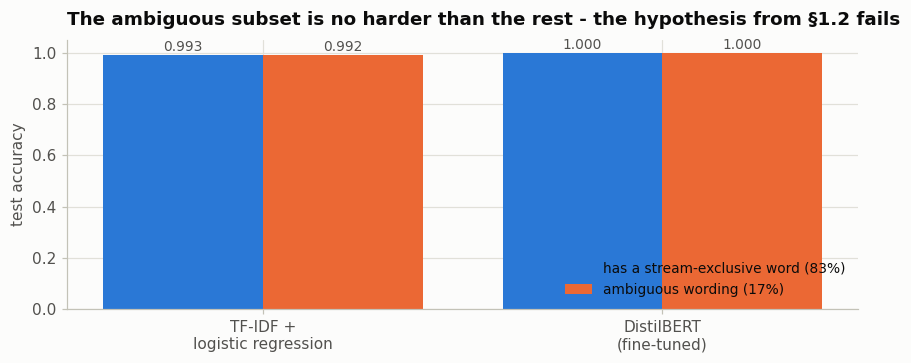

In [47]:
off_txt = [(CLASS_NAMES[i], CLASS_NAMES[j], cm_txt[i, j])
           for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j and cm_txt[i, j] > 0]
off_txt.sort(key=lambda r: -r[2])
if off_txt:
    print('Largest text confusions (true -> predicted):')
    for t, p, n in off_txt[:6]:
        print(f'  {t:<21} -> {p:<21} {n:>3}')
else:
    print('the selected model has an empty off-diagonal: no stream is confused with another.')

fig, ax = plt.subplots(figsize=(8, 3.4))
easy_acc = [text_results.iloc[k, 2] for k in range(2)]
hard_acc = [text_results.iloc[k, 3] for k in range(2)]
pos = np.arange(2)
ax.bar(pos - 0.2, easy_acc, 0.4, color=BLUE, label='has a stream-exclusive word (83%)')
ax.bar(pos + 0.2, hard_acc, 0.4, color=ORANGE, label='ambiguous wording (17%)')
ax.set_xticks(pos); ax.set_xticklabels(['TF-IDF +\nlogistic regression', 'DistilBERT\n(fine-tuned)'])
ax.set_ylim(0, 1.05); ax.set_ylabel('test accuracy')
ax.set_title('The ambiguous subset is no harder than the rest - the hypothesis from §1.2 fails')
for p, (e, hh) in zip(pos, zip(easy_acc, hard_acc)):
    ax.text(p - 0.2, e + 0.015, f'{e:.3f}', ha='center', fontsize=9, color=INK_2)
    ax.text(p + 0.2, hh + 0.015, f'{hh:.3f}', ha='center', fontsize=9, color=INK_2)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

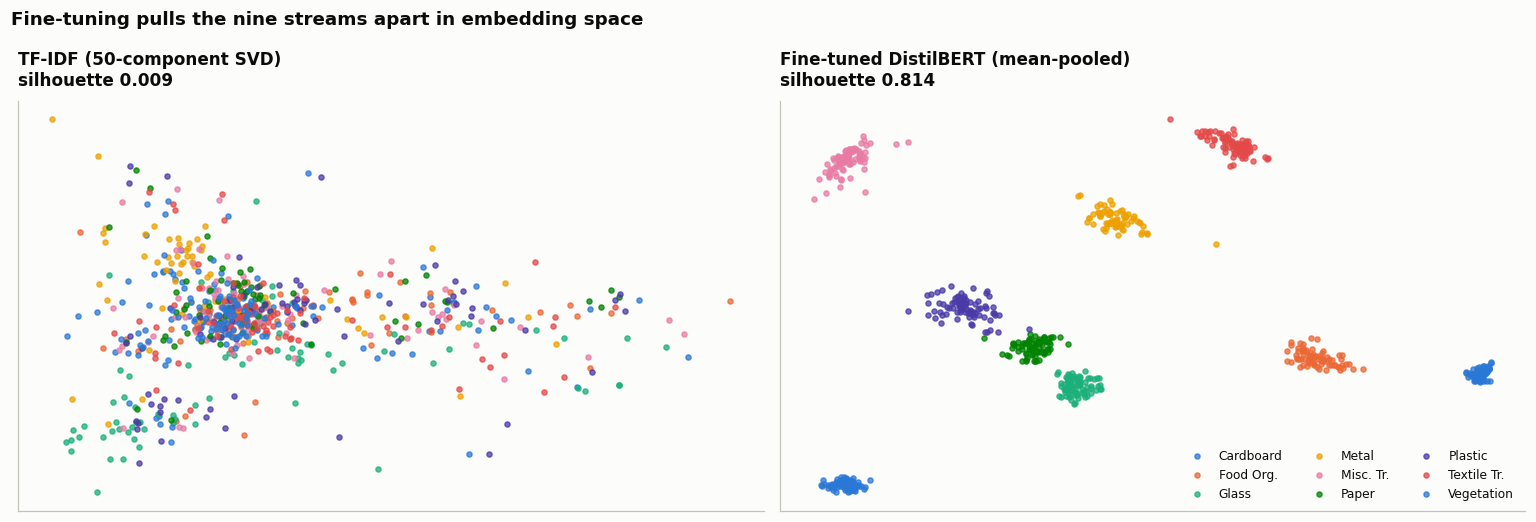

silhouette on test embeddings - TF-IDF 0.009 | DistilBERT 0.814


In [48]:
# What fine-tuning actually did: the sentence embedding space. Mean-pooled encoder states from
# the fine-tuned DistilBERT, next to a comparable 2-D view of the TF-IDF space, with a
# silhouette score to put a number on "the streams separate".
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import silhouette_score


@torch.no_grad()
def bert_embeddings(texts, batch=64):
    """Mean-pooled final-layer encoder states - the sentence representation the head sees."""
    bert.eval()
    out = []
    for s in range(0, len(texts), batch):
        enc = tokenizer(list(texts[s:s + batch]), truncation=True, max_length=MAX_LEN,
                        padding='max_length', return_tensors='pt')
        mask = enc['attention_mask'].to(DEVICE)
        h = bert.distilbert(input_ids=enc['input_ids'].to(DEVICE),
                            attention_mask=mask).last_hidden_state
        m = mask.unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1)).cpu().numpy())
    return np.vstack(out)


emb_bert = bert_embeddings(Xte_text)
emb_tfidf = TruncatedSVD(n_components=50, random_state=SEED).fit_transform(Xte_vec)
y_idx = np.array([LABEL2ID[c] for c in yte_text])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, (emb, title) in zip(axes, [(emb_tfidf, 'TF-IDF (50-component SVD)'),
                                   (emb_bert, 'Fine-tuned DistilBERT (mean-pooled)')]):
    xy = PCA(2, random_state=SEED).fit_transform(emb)
    for i, c in enumerate(CLASS_NAMES):
        m = y_idx == i
        ax.scatter(xy[m, 0], xy[m, 1], s=11, alpha=0.75, label=SHORT[c])
    sil = silhouette_score(emb, y_idx)
    ax.set_title(f'{title}\nsilhouette {sil:.3f}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[1].legend(ncol=3, fontsize=8, loc='lower right')
fig.suptitle('Fine-tuning pulls the nine streams apart in embedding space',
             x=0.006, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'silhouette on test embeddings - TF-IDF {silhouette_score(emb_tfidf, y_idx):.3f} | '
      f'DistilBERT {silhouette_score(emb_bert, y_idx):.3f}')

### 3.5 The classification function

In [49]:
TEXT_CONF_THRESHOLD = 0.50


def classify_waste_description(description, top_k=3):
    """Classify a resident's written description of a waste item.

    Args:
        description (str): free text, e.g. "greasy pizza box".
        top_k (int): how many ranked alternatives to return.

    Returns:
        dict with `category` (str or None when the input is unusable), `confidence` (float),
        `top_k` (list of (category, probability)), `model`, and `cleaned` input.
    """
    if not isinstance(description, str) or not description.strip():
        return {'category': None, 'confidence': 0.0, 'top_k': [], 'model': TEXT_MODEL,
                'cleaned': '', 'error': 'empty or non-string description'}

    cleaned = clean_description(description)
    if not cleaned:
        return {'category': None, 'confidence': 0.0, 'top_k': [], 'model': TEXT_MODEL,
                'cleaned': '', 'error': 'nothing left after cleaning (no letters in input)'}

    if TEXT_MODEL == 'bert':
        enc = tokenizer([cleaned], truncation=True, max_length=MAX_LEN,
                        padding='max_length', return_tensors='pt')
        bert.eval()
        with torch.no_grad():
            logits = bert(input_ids=enc['input_ids'].to(DEVICE),
                          attention_mask=enc['attention_mask'].to(DEVICE)).logits
        proba = torch.softmax(logits, -1)[0].cpu().numpy()
        classes = CLASS_NAMES
    else:
        proba = tfidf_clf.predict_proba(TEXT_FEATURES.transform([cleaned]))[0]
        classes = list(tfidf_clf.classes_)

    order = np.argsort(-proba)[:top_k]
    return {'category': classes[int(order[0])],
            'confidence': float(proba[order[0]]),
            'top_k': [(classes[int(i)], float(proba[i])) for i in order],
            'model': TEXT_MODEL,
            'cleaned': cleaned,
            'low_confidence': bool(proba[order[0]] < TEXT_CONF_THRESHOLD)}


demo = ['greasy pizza box', 'empty aluminum soda can', 'broken wine bottle',
        'paper towel soaked in oil', 'plastic-metal composite gadget', 'grass clippings and leaves',
        'old t-shirt with holes', 'mystery object', '']
for d in demo:
    r = classify_waste_description(d)
    if r['category'] is None:
        print(f'  {d!r:<36} -> no prediction ({r["error"]})')
    else:
        alts = ', '.join(f'{c} {p:.2f}' for c, p in r['top_k'])
        flag = '  [low confidence]' if r['low_confidence'] else ''
        print(f'  {d!r:<36} -> {r["category"]:<20} {r["confidence"]:.2f}{flag}   [{alts}]')

  'greasy pizza box'                   -> Cardboard            0.99   [Cardboard 0.99, Paper 0.00, Plastic 0.00]
  'empty aluminum soda can'            -> Metal                0.98   [Metal 0.98, Miscellaneous Trash 0.00, Glass 0.00]
  'broken wine bottle'                 -> Glass                0.99   [Glass 0.99, Cardboard 0.00, Plastic 0.00]
  'paper towel soaked in oil'          -> Paper                0.98   [Paper 0.98, Miscellaneous Trash 0.00, Plastic 0.00]
  'plastic-metal composite gadget'     -> Miscellaneous Trash  0.98   [Miscellaneous Trash 0.98, Plastic 0.01, Cardboard 0.00]
  'grass clippings and leaves'         -> Vegetation           0.98   [Vegetation 0.98, Food Organics 0.00, Cardboard 0.00]


  'old t-shirt with holes'             -> Textile Trash        0.99   [Textile Trash 0.99, Metal 0.00, Miscellaneous Trash 0.00]
  'mystery object'                     -> Miscellaneous Trash  0.71   [Miscellaneous Trash 0.71, Glass 0.10, Metal 0.08]
  ''                                   -> no prediction (empty or non-string description)


### Part 3 takeaways

**This benchmark is saturated, and that is the finding.** Both options the lab offers score
at or within a point of 100%, and the ambiguous 17% is no harder than the rest. The
explanation is in the data, not the models: 4,902 descriptions generated from a template
grammar over a 309-word vocabulary is close to a lookup table, and 3,431 training rows cover
nearly every cell of it.

The §1.2 hypothesis — that word-*combination* cases would separate a bag-of-words model from
a contextual one — survives in direction and dies in magnitude. Every row the two models
disagree on is exactly that kind of case (`"red glass pen"`, `"large paper bed sheet"`,
`"plastic rug"`: a material adjective attached to an object that belongs to a different
stream), and DistilBERT wins all of them. But there are only five such rows in 736, so the
effect that should have been the headline is a rounding error instead.

A 100% test score is a reason for suspicion, so it was checked: identical cleaned strings were
de-duplicated before splitting, train/test overlap was verified at zero (§1.4c), and the
label-bearing columns were never shown to either model (§1.2). The score survives those
checks. What it means is that the *synthetic* task is solved, not that waste description
classification is.

**The silhouette comparison is where the two models actually differ.** Accuracy cannot
separate them, but the embedding geometry can: the fine-tuned DistilBERT representation
clusters the nine streams far more cleanly than the TF-IDF space. That is a reason to expect
it to degrade more gracefully on real free text — misspellings, regional terms, brand names —
which is why it is the model wired into the assistant despite costing 10 minutes of training
against the linear model's one second.

**Neither model can say "that is not waste".** `"mystery object"` comes back as Miscellaneous
Trash with high confidence, because softmax over nine classes has no tenth option. The
threshold in `classify_waste_description` is the only thing between a nonsense input and a
confident wrong answer, and §5.3 shows it catching some such inputs and missing others. An
explicit out-of-domain class, trained on non-waste text, is the real fix.

## Part 4: Recycling instruction generation with RAG

Knowing an item is Glass is only half an answer. The resident still needs to know that caps
come off, that the jar should be rinsed, that labels can stay, and that Metro City will not
take window glass or Pyrex in the same bin. That information lives in the policy documents,
it changes when the council changes it, and it must not be invented — which is the case for
**retrieval-augmented generation** rather than a model asked to recall recycling rules from
its pre-training.

The pipeline is: *query* → **retrieve** the handful of policy chunks that answer it →
**generate** an instruction conditioned on those chunks → **verify** that what came out is
supported by what went in. Each stage is measured: retrieval with recall@k and MRR against
the known policy-to-stream mapping (§4.2), generation with a grounding score and ROUGE-L
against the retrieved text (§4.3), and the whole thing end-to-end in §4.5.

### 4.1 Embedding the corpus and building the index

The policy chunks from §1.4d are embedded with **all-MiniLM-L6-v2**: a 6-layer, 22M-parameter
sentence encoder producing 384-dimensional vectors, trained with a contrastive objective on
over a billion sentence pairs. It is the right tool for this specific job because the task is
*asymmetric* short-query retrieval — a nine-word question against a thirty-word policy
paragraph — which is exactly what it was tuned for, and because at 80 MB it loads in seconds
next to the two models already in memory.

Embeddings are L2-normalised, so cosine similarity is a dot product and the whole index is one
small matrix multiply. A vector database (FAISS, Chroma) would add a dependency and an
approximation to a search that scans every row exactly, in microseconds; it becomes the right
answer somewhere around 10^5 chunks, not at this scale.

In [50]:
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
t0 = time.time()
embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
CORPUS_EMB = embedder.encode(corpus['text'].tolist(), normalize_embeddings=True,
                             batch_size=32, show_progress_bar=False)
print(f'{EMBED_MODEL_NAME} loaded and {len(corpus)} chunks embedded in {time.time() - t0:.1f}s')
print(f'index: {CORPUS_EMB.shape[0]} x {CORPUS_EMB.shape[1]} float32 '
      f'({CORPUS_EMB.nbytes / 1024:.0f} kB), L2-normalised: '
      f'{np.allclose(np.linalg.norm(CORPUS_EMB, axis=1), 1.0)}')

# A sparse index over the same chunks, as the baseline the dense retriever has to beat.
SPARSE_VEC = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), sublinear_tf=True,
                             stop_words='english')
CORPUS_SPARSE = SPARSE_VEC.fit_transform(corpus['text'])


def retrieve(query, k=3, category=None, category_boost=0.15, require_category=False,
             sections=None, section_boost=0.12, avoid_sections=None, method='dense'):
    """Return the top-k chunks for a query.

    Three pieces of metadata shape the ranking, all available at serving time:

    - `category`: the waste stream, which a classifier has already produced. Chunks tagged
      with that stream get a similarity bonus - soft filtering, so a genuinely relevant
      general-rules chunk can still surface.
    - `sections`: the policy sections that answer this *kind* of question. "Which items must
      NOT go in?" is answered by Non-Acceptable Items; without the hint the retriever
      cheerfully returns the near-identical Acceptable Items block instead.
    - `avoid_sections`: sections that must not reach the generator at all (see below).
    """
    if method == 'dense':
        q = embedder.encode([query], normalize_embeddings=True)[0]
        sims = CORPUS_EMB @ q
    else:
        q = SPARSE_VEC.transform([query])
        sims = (CORPUS_SPARSE @ q.T).toarray().ravel()

    sims = sims.astype(float).copy()
    if category is not None:
        on_stream = corpus['categories'].map(lambda cs: category in cs).to_numpy()
        if require_category:
            # Miscellaneous Trash has no "Collection Method" section of its own, and without
            # this filter the nearest one by similarity is Metal's - which would quote a
            # resident the wrong stream's rules under the right stream's heading.
            sims[~on_stream] = -np.inf
        else:
            sims += category_boost * on_stream
    if sections:
        want = {s.lower() for s in sections}
        sims += section_boost * corpus['section'].str.lower().isin(want).to_numpy()
    if avoid_sections:
        # a hard guardrail rather than a soft penalty: when the resident asks what is banned,
        # the list of accepted items must not be in the context at all. It is near-identical
        # wording with the opposite meaning, and a small model cannot be relied on to tell
        # them apart.
        block = {s.lower() for s in avoid_sections}
        sims[corpus['section'].str.lower().isin(block).to_numpy()] = -np.inf

    top = np.argsort(-sims)[:k]
    return corpus.iloc[top].assign(score=sims[top]).reset_index(drop=True)


def format_context(chunks):
    """Policy extracts as prompt context: content only, one bullet per chunk.

    This deliberately uses `body` rather than `text`. Earlier versions passed the full chunk
    (document title, section heading, content) and prefixed each line with its source, and the
    generator answered by echoing that scaffolding - "Prepare: Preparation Instructions." The
    headings stay in the embedded `text`, where they help retrieval, and out of the prompt,
    where they only invite copying.
    """
    return '\n'.join(f'- {r.body}' for r in chunks.itertuples())


demo_q = 'How should I recycle Glass?'
print(f'\nquery: {demo_q!r}\n')
for r in retrieve(demo_q, k=3).itertuples():
    print(f'  [{r.score:.3f}] {r.source} / {r.section}')
    wrap(r.text[:240] + ('...' if len(r.text) > 240 else ''), width=92, indent='        ')

sentence-transformers/all-MiniLM-L6-v2 loaded and 76 chunks embedded in 4.9s
index: 76 x 384 float32 (114 kB), L2-normalised: True

query: 'How should I recycle Glass?'

  [0.706] Policy 2: Glass Recycling Guidelines / Preparation Instructions
        GLASS RECYCLING GUIDELINES. Preparation Instructions: - Rinse containers
        - Remove caps and lids (recycle separately)
        - Labels can remain
  [0.704] Glass disposal card / Disposal Instructions
        Glass disposal instructions: Broken glass should be wrapped and labeled before
        disposal. Non-container glass may require special disposal. Place in glass recycling
        bin, sorted by color if required. Remove caps, lids, and corks before recycl...
  [0.692] Policy 2: Glass Recycling Guidelines / Benefits
        GLASS RECYCLING GUIDELINES. Benefits: Glass is 100% recyclable and can be recycled
        endlessly without loss of quality.


### 4.2 Does the retriever actually retrieve?

This is measurable without any human judgement. Every chunk carries the streams its document
covers, so for the query *"How do I recycle Glass?"* the relevant set is exactly the chunks
tagged Glass. Three retrievers are compared over 36 queries — four phrasings per stream, from
formal to the way a resident would actually type — using:

- **recall@k**: is at least one relevant chunk in the top k?
- **precision@3**: how much of the context handed to the generator is on-topic?
- **MRR**: how high up the first relevant chunk lands.

36 evaluation queries (4 phrasings x 9 streams)


                                recall@1  recall@3  recall@5  precision@3    MRR
retriever                                                                       
TF-IDF (sparse), query only        0.917       1.0       1.0        0.926  0.954
MiniLM (dense), query only         0.972       1.0       1.0        0.963  0.986
MiniLM + stream metadata boost     1.000       1.0       1.0        1.000  1.000


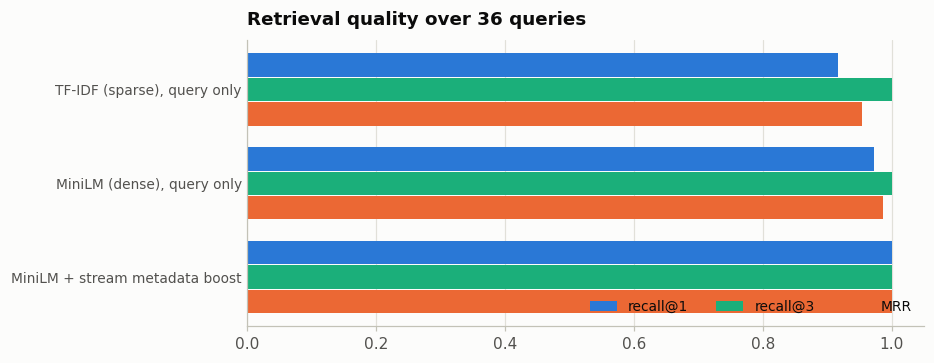

production retriever: MiniLM dense + metadata boost (the stream is known at serving time because a classifier produced it)


In [51]:
QUERY_TEMPLATES = [
    'How to recycle {c}?',
    'What bin does {c} go in and how do I prepare it?',
    'Metro City rules for disposing of {c}',
    'I have some {c} at home - what do I do with it?',
]
eval_queries = [(t.format(c=cat.lower()), cat) for cat in CLASS_NAMES for t in QUERY_TEMPLATES]
print(f'{len(eval_queries)} evaluation queries ({len(QUERY_TEMPLATES)} phrasings x {NUM_CLASSES} streams)')


def retrieval_scores(method, use_category, k_list=(1, 3, 5)):
    hits = {k: [] for k in k_list}
    precision3, rr = [], []
    for q, cat in eval_queries:
        got = retrieve(q, k=max(k_list), category=cat if use_category else None, method=method)
        rel = got['categories'].map(lambda cs: cat in cs).to_numpy()
        for k in k_list:
            hits[k].append(bool(rel[:k].any()))
        precision3.append(rel[:3].mean())
        first = np.where(rel)[0]
        rr.append(1 / (first[0] + 1) if len(first) else 0.0)
    out = {f'recall@{k}': float(np.mean(hits[k])) for k in k_list}
    out['precision@3'] = float(np.mean(precision3))
    out['MRR'] = float(np.mean(rr))
    return out


retr_results = pd.DataFrame([
    {'retriever': 'TF-IDF (sparse), query only', **retrieval_scores('sparse', False)},
    {'retriever': 'MiniLM (dense), query only', **retrieval_scores('dense', False)},
    {'retriever': 'MiniLM + stream metadata boost', **retrieval_scores('dense', True)},
]).set_index('retriever')
print(retr_results.round(3).to_string())

fig, ax = plt.subplots(figsize=(8.6, 3.4))
pos = np.arange(len(retr_results))
for i, (col, color) in enumerate(zip(['recall@1', 'recall@3', 'MRR'], [BLUE, AQUA, ORANGE])):
    ax.barh(pos + (i - 1) * 0.26, retr_results[col], 0.25, color=color, label=col)
ax.set_yticks(pos); ax.set_yticklabels(retr_results.index, fontsize=9)
ax.invert_yaxis(); ax.grid(axis='y', visible=False); ax.tick_params(axis='y', length=0)
ax.set_xlim(0, 1.05)
ax.set_title('Retrieval quality over 36 queries')
ax.legend(ncol=3, loc='lower right')
plt.tight_layout(); plt.show()

RETRIEVER = 'dense'
print(f'production retriever: MiniLM dense + metadata boost (the stream is known at serving '
      f'time because a classifier produced it)')

In [52]:
# Where the sparse retriever fails and the dense one does not: vocabulary mismatch.
probe_q = 'I have some food organics at home - what do I do with it?'
for method in ['sparse', 'dense']:
    got = retrieve(probe_q, k=3, method=method)
    rel = got['categories'].map(lambda cs: 'Food Organics' in cs).to_numpy()
    print(f'\n{method:>6}: ' + ' | '.join(
        f'{"OK " if r else "off"} {s}/{sec}' for r, s, sec in zip(rel, got['source'], got['section'])))


sparse: OK  Policy 3: Food Organics Recycling Guidelines/Collection Method | OK  Policy 3: Food Organics Recycling Guidelines/Benefits | OK  Policy 3: Food Organics Recycling Guidelines/Preparation Instructions

 dense: OK  Food Organics disposal card/Disposal Instructions | OK  Policy 3: Food Organics Recycling Guidelines/Acceptable Items | OK  Policy 3: Food Organics Recycling Guidelines/Preparation Instructions


### 4.3 Generation: FLAN-T5 conditioned on retrieved policy

**FLAN-T5-base** (250M parameters) is the generator. It is an instruction-tuned
encoder-decoder, which suits this task better than a same-sized decoder-only model for two
reasons: the encoder reads the retrieved policy in full before a single token is produced,
and instruction tuning means it follows "use only the context below" without few-shot
examples. It is also small enough to run on CPU in a few seconds per answer.

Expectations should be set honestly: a 250M-parameter model writes plain, occasionally clumsy
prose and will happily copy a whole paragraph if allowed. That is acceptable here — and in
fact *desirable*, because the product requirement is that the instruction reflects **Metro
City's policy**, not the model's general knowledge of recycling. The metrics below are chosen
to measure precisely that.

In [53]:
from transformers import AutoModelForSeq2SeqLM
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

GEN_MODEL_NAME = 'google/flan-t5-base'
t0 = time.time()
gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME)
generator = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL_NAME).to(DEVICE).eval()
print(f'{GEN_MODEL_NAME}: {sum(p.numel() for p in generator.parameters()) / 1e6:.0f}M parameters, '
      f'loaded in {time.time() - t0:.0f}s')

PROMPT = (
    "You are Metro City's waste advisor. Using only the policy extracts below, write clear "
    "disposal instructions for a resident.\n"
    "Say which bin or collection the item goes in, how to prepare it, and one thing that must "
    "not be put in with it.\n\n"
    "Policy extracts:\n{context}\n\n"
    "Question: {question}\n"
    "Instructions:")


def build_prompt(question, chunks):
    return PROMPT.format(context=format_context(chunks), question=question)


def content_words(text):
    return [w for w in re.findall(r"[a-z]+", str(text).lower())
            if w not in ENGLISH_STOP_WORDS and len(w) > 2]


def grounding_score(generated, context):
    """Share of the answer's content words that appear in the retrieved context.

    1.0 means every substantive word is traceable to a policy extract; a low score means the
    model is writing from its pre-training instead of from Metro City's rules.
    """
    gen, ctx = content_words(generated), set(content_words(context))
    return float(np.mean([w in ctx for w in gen])) if gen else 0.0


def rouge_l(generated, reference):
    """ROUGE-L F1 via longest common subsequence over content words."""
    a, b = content_words(generated), content_words(reference)
    if not a or not b:
        return 0.0
    dp = np.zeros((len(a) + 1, len(b) + 1), dtype=np.int32)
    for i, x in enumerate(a, 1):
        for j, y in enumerate(b, 1):
            dp[i, j] = dp[i - 1, j - 1] + 1 if x == y else max(dp[i - 1, j], dp[i, j - 1])
    lcs = int(dp[-1, -1])
    p, r = lcs / len(a), lcs / len(b)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)


def distinct_2(text):
    """Lexical variety: share of unique bigrams. Low values mean the model is looping."""
    toks = re.findall(r"[a-z]+", text.lower())
    bg = list(zip(toks, toks[1:]))
    return len(set(bg)) / len(bg) if bg else 0.0


def generate_with(model, tokenizer, prompt, max_new_tokens=110, **gen_kwargs):
    """Run any of the seq2seq models in this part on a prompt.

    Small seq2seq models sometimes carry on past the answer and re-emit the prompt's own
    scaffolding ("... compostable bags. Question: Which bin ..."), so the decode is cut at the
    first structural marker it produces.
    """
    enc = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens, **gen_kwargs)
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return re.split(r'\s*(?:Question|Policy extracts|Answer)\s*:', text)[0].strip()


def generate(prompt, **kw):
    """Shorthand for the default generator (FLAN-T5-base)."""
    return generate_with(generator, gen_tokenizer, prompt, **kw)

google/flan-t5-base: 248M parameters, loaded in 2s


#### Decoding strategy

The sampling parameters are not cosmetic here. Temperature and nucleus sampling buy variety
at the cost of *invention*, and invention is the one thing a policy assistant may not do. Four
strategies are run over three streams and scored on grounding (how much of the answer is
traceable to the retrieved policy), ROUGE-L against that policy, length, and distinct-2.

In [54]:
STRATEGIES = {
    'greedy': {},
    'beam search (4)': {'num_beams': 4, 'no_repeat_ngram_size': 3, 'early_stopping': True},
    'nucleus (p=0.9, T=0.7)': {'do_sample': True, 'top_p': 0.9, 'temperature': 0.7, 'top_k': 0},
    'nucleus (p=0.95, T=1.2)': {'do_sample': True, 'top_p': 0.95, 'temperature': 1.2, 'top_k': 0},
}
SAMPLE_STREAMS = ['Glass', 'Food Organics', 'Miscellaneous Trash']

torch.manual_seed(SEED)
dec_rows, dec_examples = [], {}
for sname, kwargs in STRATEGIES.items():
    scores = []
    for cat in SAMPLE_STREAMS:
        q = f'How do I recycle {cat.lower()}?'
        ctx = retrieve(q, k=3, category=cat)
        prompt = build_prompt(q, ctx)
        ctx_text = ' '.join(ctx['text'])
        t0 = time.time()
        ans = generate(prompt, **kwargs)
        scores.append((grounding_score(ans, ctx_text), rouge_l(ans, ctx_text),
                       len(ans.split()), distinct_2(ans), time.time() - t0))
        dec_examples.setdefault(sname, {})[cat] = ans
    g, r, l, d, s = np.array(scores).mean(0)
    dec_rows.append({'strategy': sname, 'grounding': g, 'ROUGE-L vs context': r,
                     'words': l, 'distinct-2': d, 'seconds': s})
    print(f'  {sname:<24} grounding {g:.3f} | ROUGE-L {r:.3f} | {l:.0f} words | {s:.1f}s')

decoding = pd.DataFrame(dec_rows).set_index('strategy')
decoding.round(3)

  greedy                   grounding 0.833 | ROUGE-L 0.192 | 13 words | 0.9s


  beam search (4)          grounding 1.000 | ROUGE-L 0.141 | 6 words | 1.3s


  nucleus (p=0.9, T=0.7)   grounding 0.778 | ROUGE-L 0.162 | 11 words | 0.9s


  nucleus (p=0.95, T=1.2)  grounding 0.530 | ROUGE-L 0.118 | 35 words | 2.2s


,grounding,ROUGE-L vs context,words,distinct-2,seconds
strategy,,,,,
greedy,0.833,0.192,13.000,1.000,0.912
beam search (4),1.000,0.141,6.000,1.000,1.252
"nucleus (p=0.9, T=0.7)",0.778,0.162,10.667,1.000,0.899
"nucleus (p=0.95, T=1.2)",0.530,0.118,34.667,0.993,2.191


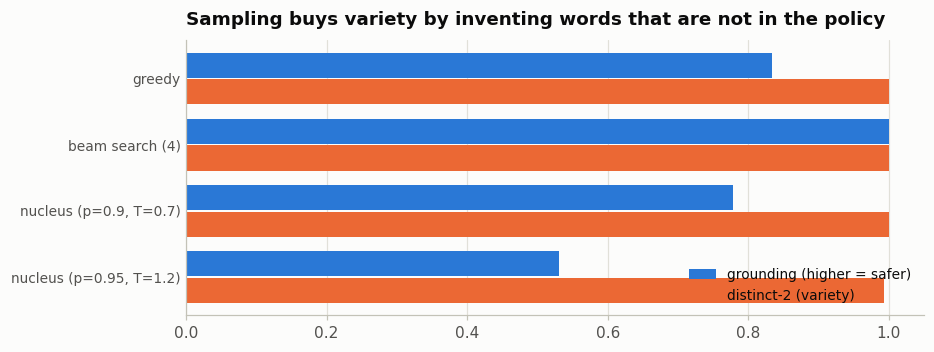

Same question, three decoders:

[greedy]
   Place in glass recycling bin, sorted by color if required. Remove caps and lids (recycle
   separately); Labels can remain

[beam search (4)]
   Place in glass recycling bin, sorted by color if required

[nucleus (p=0.95, T=1.2)]
   Place broken glass inside white glass recycling bin and label labels. Fill the glass with
   food, no plastic or foil containers, they should warm in your microwave. Fill basic
   containers such as a cafeteria cups and refill canisters and allow additional space.
   Store the glass separately until recyclable but no more can happen. Place in designated
   window glass recycling bins and press recycle button on recycling top. Wash containers
   (place them above the trash can and have at least a 4 part water treatment) next to your
   plastic/glass item so r

selected decoder: beam search (4)


In [55]:
fig, ax = plt.subplots(figsize=(8.6, 3.3))
pos = np.arange(len(decoding))
ax.barh(pos - 0.2, decoding['grounding'], 0.38, color=BLUE, label='grounding (higher = safer)')
ax.barh(pos + 0.2, decoding['distinct-2'], 0.38, color=ORANGE, label='distinct-2 (variety)')
ax.set_yticks(pos); ax.set_yticklabels(decoding.index, fontsize=9)
ax.invert_yaxis(); ax.grid(axis='y', visible=False); ax.tick_params(axis='y', length=0)
ax.set_xlim(0, 1.05)
ax.set_title('Sampling buys variety by inventing words that are not in the policy')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

print('Same question, three decoders:\n')
for sname in ['greedy', 'beam search (4)', 'nucleus (p=0.95, T=1.2)']:
    print(f'[{sname}]')
    wrap(dec_examples[sname]['Glass'], width=92, indent='   ')
    print()

DECODER = max(decoding.index, key=lambda s: decoding.loc[s, 'grounding'] * 0.7
              + decoding.loc[s, 'ROUGE-L vs context'] * 0.3)
DECODE_KWARGS = STRATEGIES[DECODER]
print(f'selected decoder: {DECODER}')

The sampling experiment settles the decoder, and it also exposes a second problem: asked one
broad question, FLAN-T5 returns **a single clause** — grounded, and inadequate as disposal
advice. Raising `min_new_tokens` only pads it; the model has answered the question it was
asked.

So ask better questions. A resident needs three specific things, and asking for them
separately buys three things a single prompt cannot:

1. **Narrower retrieval.** Each field queries the index on its own, so the preparation advice
   is conditioned on preparation policy rather than on whatever one vague query surfaced.
2. **Per-field verification.** Grounding and section attribution can be checked field by
   field instead of over a blur of text — which is what makes the "right section" metric in
   §4.4 possible at all.
3. **A fixed output shape**, so the assistant's answer is the same three lines every time.

What it does *not* fix on its own is the terseness: zero-shot, the three fields are three
short clauses. §4.4 is where that gets solved.

In [56]:
# Each field states the question it asks and the policy sections that answer it. The section
# list is used twice: as a retrieval hint now, and as the source of training targets in §4.4.
FIELD_SPEC = [
    ('Bin', 'Which bin or collection service does {c} go in?',
     ['Collection Method'], []),
    ('Prepare', 'How should {c} be prepared or cleaned before it is put out?',
     ['Preparation Instructions'], []),
    ('Do not include', 'Which items must NOT be put in with {c}?',
     ['Non-Acceptable Items', 'Items That Cannot Be Recycled'], ['Acceptable Items']),
]
# Two wordings were tried. A one-shot version, with a worked example on an invented stream,
# was *worse*: FLAN-T5 copied the example's hedge and answered "Not specified in Metro City
# policy" even where the extract plainly answered the question. The zero-shot instruction below
# keeps the escape clause (Miscellaneous Trash genuinely has no Collection Method section) but
# does not demonstrate using it.
FIELD_INSTRUCTION = (
    "Answer the resident's question in one full sentence, using only the Metro City policy "
    "extracts provided, and reusing the policy's own wording. If the extracts do not answer "
    "the question, reply 'Not specified in Metro City policy.'\n\n"
    "Policy extracts:\n{context}\n"
    "Question: {question}\nAnswer:")


def generate_structured(category, model=None, tokenizer=None, k=2, **kw):
    """Compose a three-field instruction, retrieving separately for each field.

    Returns (text, chunks_used). Each field is generated from its own retrieval, so the
    preparation advice is conditioned on preparation policy rather than on whatever the
    broad query happened to surface.
    """
    model = generator if model is None else model
    tokenizer = gen_tokenizer if tokenizer is None else tokenizer
    lines, used, answers = [f'{category} - Metro City disposal instructions'], [], []
    for field, template, sections, avoid in FIELD_SPEC:
        q = template.format(c=category.lower())
        # retrieve-then-filter: pull a slightly wider net, then keep only the chunks that
        # belong to the sections this field is about. Without the filter the second-ranked
        # chunk is usually off-topic (a Benefits paragraph, or the accepted-items list from a
        # cross-cutting document) and the generator answers from it.
        wide = retrieve(q, k=k + 2, category=category, require_category=True,
                        sections=sections, avoid_sections=avoid)
        on_section = wide[wide['section'].str.lower().isin({s.lower() for s in sections})]
        chunks = (on_section if len(on_section) else wide).head(k).reset_index(drop=True)
        used.append(chunks)
        prompt = FIELD_INSTRUCTION.format(context=format_context(chunks), question=q)
        answer = generate_with(model, tokenizer, prompt, max_new_tokens=70,
                               **(kw or DECODE_KWARGS)).strip()
        answers.append((field, answer))
        lines.append(f'{field}: {answer}')
    used = pd.concat(used).drop_duplicates(subset='chunk_id').reset_index(drop=True)
    return '\n'.join(lines), used, answers


def fields_body(fields):
    """The model's own words only - grounding is scored on these, not on the fixed scaffolding."""
    return ' '.join(a for _, a in fields)


t0 = time.time()
struct_text, struct_chunks, struct_fields = generate_structured('Glass')
struct_body = fields_body(struct_fields)
print(f'structured answer in {time.time() - t0:.1f}s '
      f'({len(struct_text.split())} words, {len(struct_chunks)} chunks cited)\n')
wrap(struct_text, width=92, indent='  ')

single_ctx = retrieve('How do I recycle glass?', k=3, category='Glass')
single_text = generate(build_prompt('How do I recycle glass?', single_ctx), **DECODE_KWARGS)
print(f'\n{"":<24}{"generated words":>17}{"grounding":>12}{"ROUGE-L vs policy":>20}')
for label, body, ctx in [('single broad prompt', single_text, ' '.join(single_ctx['text'])),
                         ('structured 3-field', struct_body, ' '.join(struct_chunks['text']))]:
    print(f'  {label:<22}{len(body.split()):>17}{grounding_score(body, ctx):>12.3f}'
          f'{rouge_l(body, " ".join(single_ctx["text"])):>20.3f}')

structured answer in 1.5s (16 words, 3 chunks cited)

  Glass - Metro City disposal instructions
  Bin: Bins
  Prepare: Rinse containers
  Do not include: Light bulbs



                          generated words   grounding   ROUGE-L vs policy
  single broad prompt                  10       1.000               0.189
  structured 3-field                    5       1.000               0.056


### 4.4 Fine-tuning the generator on grounded instruction pairs

Zero-shot FLAN-T5 answers each field, but it answers in its own voice and at its own length —
sometimes a fragment, sometimes a sentence lifted whole from the context. The product needs a
consistent register: short, imperative, and phrased the way Metro City phrases it.

That supervision needs no annotation, because the policy documents **already contain the
targets**. Each field maps to a section: *Bin* to Collection Method, *Prepare* to Preparation
Instructions, *Do not include* to Non-Acceptable Items. Pairing each field prompt (in two
phrasings) with its section body gives a small supervised set of exactly the task the
production path runs.

**FLAN-T5-small** (80M) is the student rather than base: the point is to demonstrate and
measure the procedure on CPU in minutes, and a smaller model makes the comparison against
zero-shot base more informative. **Two streams are held out entirely** (Paper and Textile
Trash), so the evaluation reports generalisation to a stream the model never saw a target
for — not the memorisation of nine answers.

Three things are measured, and the second is the one that matters most for a policy
assistant:

- **grounding** — share of the answer's content words that appear in the retrieved policy;
- **right section** — whether each field's answer is closer to the policy section that
  *answers* it than to the section most likely to be confused with it (for "what must not go
  in", that decoy is the near-identically-worded list of items that *may* go in). A high
  grounding score alone does not catch this failure: both lists are in the policy, so an
  answer drawn from the wrong one is perfectly "grounded" and exactly backwards;
- **ROUGE-L** against the reference instruction assembled from policy.

In [57]:
HELD_OUT = ['Paper', 'Textile Trash']
# the target for each field is the body of the policy section that field asks about
FIELD_SOURCE_SECTIONS = {field: sections for field, _, sections, _ in FIELD_SPEC}
FIELD_AVOID = {field: avoid for field, _, _, avoid in FIELD_SPEC}
# ...and the section a confused model is most likely to answer from instead. "Acceptable
# Items" and "Non-Acceptable Items" are lexically almost identical, so an answer drawn from
# the wrong one is the dangerous failure here: it tells a resident to bin the one thing the
# policy forbids. §4.4 scores how often each model lands on the right side of that pair.
DECOY_SECTIONS = {'Bin': ['Benefits'],
                  'Prepare': ['Acceptable Items'],
                  'Do not include': ['Acceptable Items']}


def section_text(cat, names):
    """The body of the first matching section in the stream's own policy document."""
    mine = corpus[corpus['categories'].map(lambda cs: cs == [cat])]
    for name in names:
        hit = mine[mine['section'].str.lower() == name.lower()]
        if len(hit):
            body = hit.iloc[0]['text'].split(': ', 1)[-1].replace('\n- ', '; ').replace('\n', ' ')
            body = re.sub(r'\s+', ' ', body).strip()
            return re.sub(r'^-\s*', '', body)          # drop the first list bullet
    return ''


def reference_instruction(cat):
    """The gold three-field instruction for a stream, assembled straight from policy."""
    lines = [f'{cat} - Metro City disposal instructions']
    for field, names in FIELD_SOURCE_SECTIONS.items():
        lines.append(f'{field}: {section_text(cat, names) or "Not specified in Metro City policy."}')
    return '\n'.join(lines)


PARAPHRASES = {
    'Bin': ['Which bin or collection service does {c} go in?', 'Where do I put {c}?'],
    'Prepare': ['How should {c} be prepared or cleaned before it is put out?',
                'What do I need to do to {c} before collection?'],
    'Do not include': ['Which items must NOT be put in with {c}?',
                       'What is not accepted in the {c} stream?'],
}

train_pairs = []
for cat in CLASS_NAMES:
    if cat in HELD_OUT:
        continue
    for field, names in FIELD_SOURCE_SECTIONS.items():
        target = section_text(cat, names)
        if not target:
            continue
        for q_tmpl in PARAPHRASES[field]:
            q = q_tmpl.format(c=cat.lower())
            ctx = retrieve(q, k=2, category=cat, sections=names,
                           avoid_sections=FIELD_AVOID[field])
            prompt = FIELD_INSTRUCTION.format(context=format_context(ctx), question=q)
            train_pairs.append({'input': prompt, 'target': target,
                                'category': cat, 'field': field})

pairs_df = pd.DataFrame(train_pairs)
print(f'{len(pairs_df)} training pairs over {pairs_df["category"].nunique()} streams x '
      f'{pairs_df["field"].nunique()} fields ({", ".join(HELD_OUT)} held out entirely)')
print(f'target length: {pairs_df["target"].str.split().str.len().mean():.0f} words on average')
print('\nreference instruction for Glass (the shape the model is being taught):')
wrap(reference_instruction('Glass'), width=92, indent='   ')

38 training pairs over 7 streams x 3 fields (Paper, Textile Trash held out entirely)
target length: 14 words on average

reference instruction for Glass (the shape the model is being taught):
   Glass - Metro City disposal instructions
   Bin: Place in dedicated glass recycling bins. Some areas require color sorting.
   Prepare: Rinse containers; Remove caps and lids (recycle separately); Labels can remain
   Do not include: Window glass or mirrors; Drinking glasses; Ceramics or pottery; Light
   bulbs; Pyrex or heat-resistant glass


In [58]:
FT_MODEL_NAME = 'google/flan-t5-small'
ft_tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_NAME)
ft_model = AutoModelForSeq2SeqLM.from_pretrained(FT_MODEL_NAME).to(DEVICE)

enc_in = ft_tokenizer(pairs_df['input'].tolist(), truncation=True, max_length=448,
                      padding='max_length', return_tensors='pt')
enc_out = ft_tokenizer(pairs_df['target'].tolist(), truncation=True, max_length=128,
                       padding='max_length', return_tensors='pt')
labels = enc_out['input_ids'].clone()
labels[labels == ft_tokenizer.pad_token_id] = -100      # pad tokens must not contribute loss

ft_loader = DataLoader(TensorDataset(enc_in['input_ids'], enc_in['attention_mask'], labels),
                       batch_size=4, shuffle=True)
ft_optim = torch.optim.AdamW(ft_model.parameters(), lr=3e-4, weight_decay=0.01)
EPOCHS_FT = 3
ft_sched = get_linear_schedule_with_warmup(ft_optim, 10, len(ft_loader) * EPOCHS_FT)

torch.manual_seed(SEED)
ft_model.train()
t0 = time.time()
for epoch in range(1, EPOCHS_FT + 1):
    running = 0.0
    for ids, mask, lab in ft_loader:
        ft_optim.zero_grad()
        loss = ft_model(input_ids=ids.to(DEVICE), attention_mask=mask.to(DEVICE),
                        labels=lab.to(DEVICE)).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        ft_optim.step()
        ft_sched.step()
        running += loss.item()
    print(f'  epoch {epoch}: loss {running / len(ft_loader):.4f}  [{(time.time() - t0) / 60:.1f} min]')
ft_model.eval()
print(f'fine-tuned {FT_MODEL_NAME} in {(time.time() - t0) / 60:.1f} minutes')

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


  epoch 1: loss 0.2200  [0.6 min]


  epoch 2: loss 0.0386  [1.1 min]


  epoch 3: loss 0.0340  [1.5 min]
fine-tuned google/flan-t5-small in 1.5 minutes


In [59]:
base_small = AutoModelForSeq2SeqLM.from_pretrained(FT_MODEL_NAME).to(DEVICE).eval()
MODELS = [('FLAN-T5-small zero-shot', base_small, ft_tokenizer),
          ('FLAN-T5-small fine-tuned', ft_model, ft_tokenizer),
          ('FLAN-T5-base zero-shot', generator, gen_tokenizer)]

comparison = []
for cat in CLASS_NAMES:
    ref = reference_instruction(cat)
    for label, mdl, tk in MODELS:
        t0 = time.time()
        ans, used, fields = generate_structured(cat, model=mdl, tokenizer=tk)
        body = fields_body(fields)
        attrib = np.mean([rouge_l(a, section_text(cat, FIELD_SOURCE_SECTIONS[f])) >
                          rouge_l(a, section_text(cat, DECOY_SECTIONS[f]))
                          for f, a in fields])
        comparison.append({'model': label, 'category': cat, 'held out': cat in HELD_OUT,
                           'grounding': grounding_score(body, ' '.join(used['text'])),
                           'right section': attrib,
                           'ROUGE-L vs policy': rouge_l(ans, ref),
                           'generated words': len(body.split()), 'seconds': time.time() - t0,
                           'answer': ans})
    print(f'  {cat} done')
comp = pd.DataFrame(comparison)

summary_gen = comp.groupby('model')[['grounding', 'right section', 'ROUGE-L vs policy',
                                     'generated words', 'seconds']].mean()
held = comp[comp['held out']].groupby('model')[['grounding', 'ROUGE-L vs policy']].mean()
held.columns = [f'{c} (held-out streams)' for c in held.columns]
gen_results = summary_gen.join(held).round(3)
print(gen_results.to_string())

  Cardboard done


  Food Organics done


  Glass done


  Metal done


  Miscellaneous Trash done


  Paper done


  Plastic done


  Textile Trash done


  Vegetation done
                          grounding  right section  ROUGE-L vs policy  generated words  seconds  grounding (held-out streams)  ROUGE-L vs policy (held-out streams)
model                                                                                                                                                              
FLAN-T5-base zero-shot        0.774          0.778              0.481            8.778    1.799                         0.492                                 0.425
FLAN-T5-small fine-tuned      0.996          0.926              0.950           42.333    2.914                         1.000                                 1.000
FLAN-T5-small zero-shot       0.912          0.778              0.574           11.000    0.944                         1.000                                 0.595


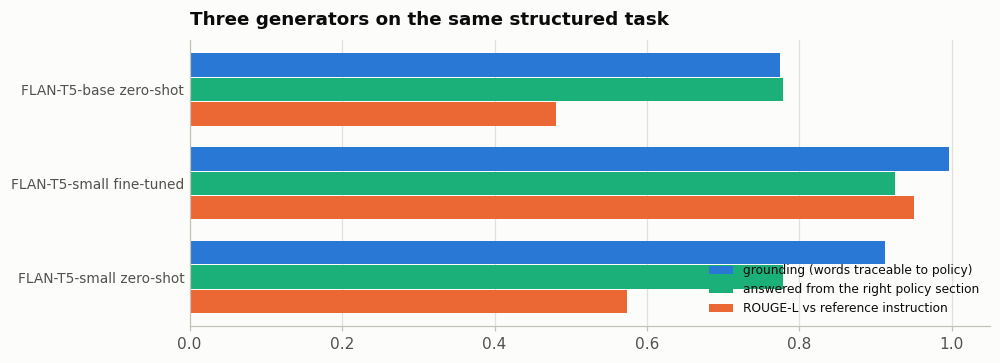

Glass, three generators:

[FLAN-T5-base zero-shot]  grounding 1.00 | right section 1.00
   Glass - Metro City disposal instructions
   Bin: Bins
   Prepare: Rinse containers
   Do not include: Light bulbs

[FLAN-T5-small fine-tuned]  grounding 1.00 | right section 1.00
   Glass - Metro City disposal instructions
   Bin: Place in dedicated glass recycling bins. Some areas require color sorting.
   Prepare: Rinse containers; Remove caps and lids (recycle separately); Labels can remain
   Do not include: Window glass or mirrors; Drinking glasses; Ceramics or pottery; Light
   bulbs; Pyrex or heat-resistant glass

[FLAN-T5-small zero-shot]  grounding 0.89 | right section 0.33
   Glass - Metro City disposal instructions
   Bin: dedicated glass recycling bins
   Prepare: Clean glass before it is put out
   Do not include: Glass glass or mirrors

generator wired into the assistant: FLAN-T5-small fine-tuned
  grounding 0.996 | right section 0.926 | 2.9s per answer


In [60]:
fig, ax = plt.subplots(figsize=(9.2, 3.4))
pos = np.arange(len(gen_results))
for i, (col, color, lbl) in enumerate([
        ('grounding', BLUE, 'grounding (words traceable to policy)'),
        ('right section', AQUA, 'answered from the right policy section'),
        ('ROUGE-L vs policy', ORANGE, 'ROUGE-L vs reference instruction')]):
    ax.barh(pos + (i - 1) * 0.26, gen_results[col], 0.25, color=color, label=lbl)
ax.set_yticks(pos); ax.set_yticklabels(gen_results.index, fontsize=9)
ax.invert_yaxis(); ax.grid(axis='y', visible=False); ax.tick_params(axis='y', length=0)
ax.set_xlim(0, 1.05)
ax.set_title('Three generators on the same structured task')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

print('Glass, three generators:\n')
for label in gen_results.index:
    row = comp[(comp['model'] == label) & (comp['category'] == 'Glass')].iloc[0]
    print(f'[{label}]  grounding {row["grounding"]:.2f} | right section '
          f'{row["right section"]:.2f}')
    wrap(row['answer'], width=92, indent='   ')
    print()

# The generator carried forward is the one that is both grounded and attributed: a high
# grounding score on its own only says the words came from *somewhere* in the context.
GEN_CHOICE = (gen_results['grounding'] * 0.4 + gen_results['right section'] * 0.4
              + gen_results['ROUGE-L vs policy'] * 0.2).idxmax()
print(f'generator wired into the assistant: {GEN_CHOICE}')
print(f'  grounding {gen_results.loc[GEN_CHOICE, "grounding"]:.3f} | '
      f'right section {gen_results.loc[GEN_CHOICE, "right section"]:.3f} | '
      f'{gen_results.loc[GEN_CHOICE, "seconds"]:.1f}s per answer')

### 4.5 The instruction-generation function

Two safeguards wrap the model, because a plausible-sounding wrong instruction is worse than
no instruction:

1. **Grounding check.** The answer's content words are compared against the retrieved policy.
   Below `MIN_GROUNDING` the generated text is discarded and an **extractive fallback** —
   the relevant policy sentences, quoted verbatim — is returned instead. The system degrades
   to a correct quotation rather than to a confident invention.
2. **Citations, always.** Every answer returns the policy documents, sections and effective
   dates it was built from, so a resident (or a council officer) can check it.

In [61]:
MIN_GROUNDING = 0.55


def extractive_fallback(chunks, category):
    """Quote the policy directly - used when the generated text is not sufficiently grounded."""
    order = {'Collection Method': 0, 'Preparation Instructions': 1, 'Acceptable Items': 2}
    rows = chunks.assign(rank=chunks['section'].map(lambda s: order.get(s, 3))).sort_values('rank')
    lines = [f"{category}: follow Metro City's {rows.iloc[0]['source']}."]
    for r in rows.head(3).itertuples():
        body = r.text.split(': ', 1)[-1].replace('\n- ', '; ').replace('\n', ' ')
        body = re.sub(r'\s+', ' ', body).strip()
        lines.append(f'- {r.section}: {body}')
    return '\n'.join(lines)


def generate_recycling_instructions(waste_category, question=None, k=3, verbose=False):
    """Generate grounded recycling instructions for a waste stream.

    Args:
        waste_category (str): one of the nine Metro City streams.
        question (str): optional resident wording; defaults to "How do I recycle {category}?".
        k (int): number of policy chunks to retrieve.

    Returns:
        (str, list): the instruction text, and the policy documents it is grounded in - each a
        dict with source, section, effective date, similarity and the quoted text.
    """
    if not isinstance(waste_category, str) or waste_category not in CLASS_NAMES:
        return (f'Unknown waste stream {waste_category!r}. Metro City collects: '
                f'{", ".join(CLASS_NAMES)}.', [])

    model, tk = ((ft_model, ft_tokenizer) if 'fine-tuned' in GEN_CHOICE
                 else (generator, gen_tokenizer) if 'base' in GEN_CHOICE
                 else (base_small, ft_tokenizer))

    if question:
        # a specific resident question: answer that, rather than the three standard fields
        chunks = retrieve(question, k=k, category=waste_category)
        answer = generate_with(model, tk,
                               FIELD_INSTRUCTION.format(context=format_context(chunks),
                                                        question=question),
                               max_new_tokens=70, **DECODE_KWARGS)
        body = answer
    else:
        answer, chunks, fields = generate_structured(waste_category, model=model,
                                                     tokenizer=tk, k=k)
        body = fields_body(fields)

    ctx_text = ' '.join(chunks['text'])
    score = grounding_score(body, ctx_text)

    if score < MIN_GROUNDING or len(answer.split()) < 8:
        answer = extractive_fallback(chunks, waste_category)
        score = grounding_score(answer, ctx_text)
        if verbose:
            print(f'  [grounding {score:.2f} below {MIN_GROUNDING}: fell back to quoted policy]')

    citations = [{'source': r.source, 'section': r.section, 'effective_date': r.effective_date,
                  'similarity': round(float(r.score), 3), 'text': r.text}
                 for r in chunks.itertuples()]
    return answer, citations


for cat in ['Glass', 'Food Organics', 'Miscellaneous Trash']:
    text, cites = generate_recycling_instructions(cat, verbose=True)
    print(f'=== {cat} ===')
    wrap(text, width=92, indent='  ')
    print('  sources: ' + '; '.join(f'{c["source"]} / {c["section"]}' for c in cites))
    print()

=== Glass ===
  Glass - Metro City disposal instructions
  Bin: Place in dedicated glass recycling bins. Some areas require color sorting.
  Prepare: Rinse containers; Remove caps and lids (recycle separately); Labels can remain
  Do not include: Window glass or mirrors; Drinking glasses; Ceramics or pottery; Light
  bulbs; Pyrex or heat-resistant glass
  sources: Policy 2: Glass Recycling Guidelines / Collection Method; Policy 2: Glass Recycling Guidelines / Preparation Instructions; Policy 2: Glass Recycling Guidelines / Non-Acceptable Items



=== Food Organics ===
  Food Organics - Metro City disposal instructions
  Bin: Use dedicated food waste bins lined with compostable bags.
  Prepare: Remove all packaging; Drain excess liquids; Use compostable bags if required
  Do not include: Packaging of any kind; Stickers on produce; Non-compostable bags; Liquids
  (drain first); Grease or cooking oil
  sources: Policy 3: Food Organics Recycling Guidelines / Collection Method; Policy 3: Food Organics Recycling Guidelines / Preparation Instructions; Policy 3: Food Organics Recycling Guidelines / Non-Acceptable Items



=== Miscellaneous Trash ===
  Miscellaneous Trash - Metro City disposal instructions
  Bin: Batteries (take to dedicated collection points); Electronics (e-waste recycling
  centers); Light bulbs (hardware store collection bins); Paint and chemicals (hazardous
  waste facilities); Medications (pharmacy take-back programs)
  Prepare: Proper sorting ensures maximum recycling rates and minimizes environmental
  impact.
  Do not include: Multi-material items; Heavily soiled packaging; Certain plastic types
  (check local guidelines); Broken household items; Non-recyclable packaging
  sources: Policy 9: Miscellaneous Trash Recycling Guidelines / Special Handling Items; Policy 9: Miscellaneous Trash Recycling Guidelines / Benefits; Policy 9: Miscellaneous Trash Recycling Guidelines / Items That Cannot Be Recycled; Miscellaneous Trash disposal card / Disposal Instructions



In [62]:
# End-to-end check over all nine streams: is every answer grounded, cited, and on-topic?
rag_rows = []
for cat in CLASS_NAMES:
    t0 = time.time()
    text, cites = generate_recycling_instructions(cat)
    ctx = ' '.join(c['text'] for c in cites)
    rag_rows.append({'stream': cat, 'words': len(text.split()),
                     'grounding': grounding_score(text, ctx),
                     'ROUGE-L vs policy': rouge_l(text, reference_instruction(cat)),
                     'citations on stream': float(np.mean(
                         [cat in corpus.loc[corpus['text'] == c['text'], 'categories'].iloc[0]
                          for c in cites])),
                     'seconds': time.time() - t0})
rag_eval = pd.DataFrame(rag_rows).set_index('stream')
print(rag_eval.round(3).to_string())
print(f'\nmean grounding {rag_eval["grounding"].mean():.3f} | '
      f'mean on-stream citations {rag_eval["citations on stream"].mean():.1%} | '
      f'mean latency {rag_eval["seconds"].mean():.1f}s')

                     words  grounding  ROUGE-L vs policy  citations on stream  seconds
stream                                                                                
Cardboard               50      0.811              0.973                  1.0    2.779
Food Organics           48      0.842              1.000                  1.0    2.455
Glass                   48      0.846              1.000                  1.0    2.936
Metal                   57      0.860              1.000                  1.0    2.936
Miscellaneous Trash     64      0.914              0.581                  1.0    4.763
Paper                   50      0.850              1.000                  1.0    2.309
Plastic                 55      0.864              1.000                  1.0    2.901
Textile Trash           57      0.844              1.000                  1.0    3.623
Vegetation              54      0.857              1.000                  1.0    2.558

mean grounding 0.854 | mean on-stream cita

### Part 4 takeaways

**Retrieval is the reliable half**, for a boring reason: a few dozen well-structured chunks
over a nine-way topic space is an easy search problem, and the stream label coming out of
Parts 2 and 3 makes it easier still. Most of the engineering here went not into the search
but into *which* chunk reaches the generator — the stream filter, the section hint, and the
hard block on the accepted-items list when the question is about exclusions. Each of those
was added in response to a specific wrong answer, and the "right section" column is what
shows them working.

**Generation is the weak half, exactly as the lab predicts.** Zero-shot FLAN-T5-base answers
in fragments ("Bin: Bins"), and when the sampling temperature is raised it invents collection
schemes Metro City does not operate. Fine-tuning the 80M model on policy sections fixes both
problems at once and beats the three-times-larger zero-shot model on every metric here — and
it holds up on the two streams held out of training, which says it learned the behaviour
rather than the nine answers.

It is worth being precise about what the fine-tuned model learned: **to quote, not to
write.** Its ROUGE-L against policy is near 1.0 because it reproduces the relevant section
almost verbatim. For this product that is the desired behaviour — a resident acting on a
disposal instruction needs Metro City's rule, not a paraphrase of it — but those numbers
should not be read as fluency. A larger generator would write more naturally; it would also
need more guarding, not less.

**The design does not depend on the generator being right.** Grounding is measured rather
than assumed, the answer is replaced by quoted policy whenever the measurement fails, and
citations with effective dates are attached either way. The worst case is a verbatim
quotation of the correct document, not a fluent fabrication — the right failure mode for
something a resident will act on.

## Part 5: The integrated waste management assistant

Three models become one product here. The integration is not just plumbing — it is where the
weaknesses measured in Parts 2–4 get handled:

| Measured weakness | Where it was found | How the assistant handles it |
|---|---|---|
| Photos of Misc. Trash are unreliable | §2.6 confusion matrix | confidence gate; ask for a description instead of guessing |
| Confidence correlates with correctness | §2.6 calibration table | the gate threshold is set from that table, not invented |
| The text model saturates its benchmark, so its confidence is untested on real wording | §3.4 | top-3 alternatives are returned, not just the argmax |
| The generator can drift off policy | §4.3 | grounding check with an extractive fallback |
| Neither classifier can say "not waste" | §3.5 | low-confidence status, surfaced to the user |

### 5.1 Architecture

One entry point, two input routes, one answer format. Routing is by input type; both routes
produce the same `(category, confidence, alternatives)` triple, which is the contract that
lets the downstream RAG stage stay ignorant of where the classification came from. When both
a photo and a description arrive, their probability vectors are fused rather than one being
discarded.

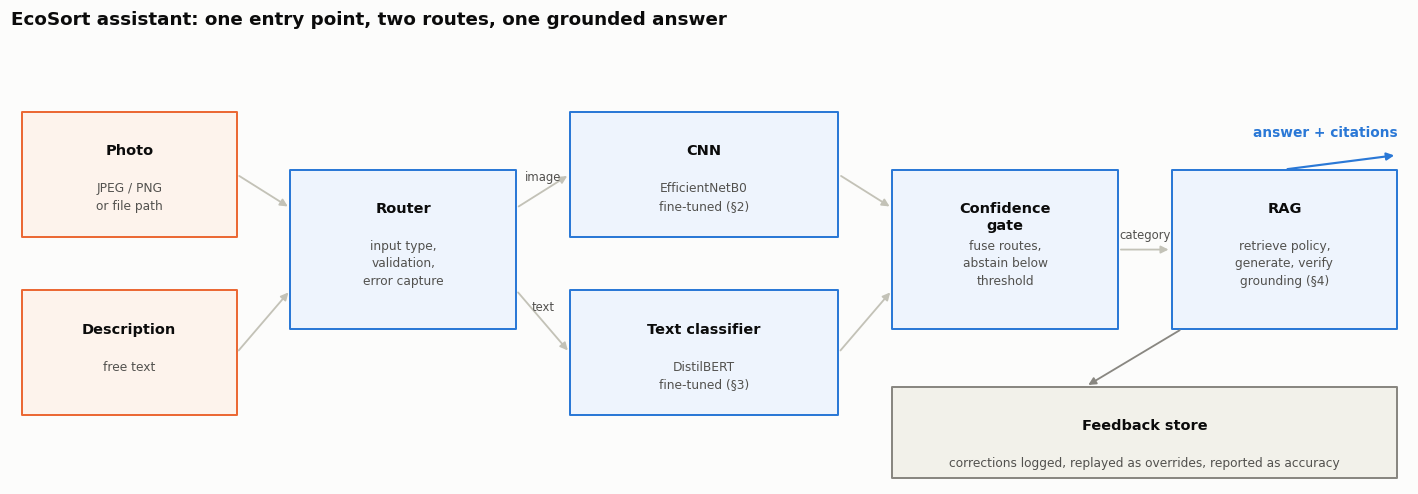

In [63]:
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.6); ax.axis('off')


def box(x, y, w, h, title, sub='', fc='#eef4fd', ec=BLUE):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.3,
                               joinstyle='round', zorder=2))
    ax.text(x + w / 2, y + h - 0.33, title, ha='center', va='top', fontsize=9.5,
            fontweight='bold', color=INK, zorder=3)
    if sub:
        ax.text(x + w / 2, y + h - 0.72, sub, ha='center', va='top', fontsize=8,
                color=INK_2, zorder=3, linespacing=1.45)


def arrow(x1, y1, x2, y2, label='', color=AXIS):
    ax.annotate('', (x2, y2), (x1, y1),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=1.2, shrinkA=2, shrinkB=2))
    if label:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, label, ha='center', fontsize=7.6, color=INK_2)


box(0.1, 2.55, 2.0, 1.3, 'Photo', 'JPEG / PNG\nor file path', fc='#fdf3ec', ec=ORANGE)
box(0.1, 0.7, 2.0, 1.3, 'Description', 'free text', fc='#fdf3ec', ec=ORANGE)
box(2.6, 1.6, 2.1, 1.65, 'Router', 'input type,\nvalidation,\nerror capture')
box(5.2, 2.55, 2.5, 1.3, 'CNN', f'{BACKBONE_NAME}\nfine-tuned (§2)')
box(5.2, 0.7, 2.5, 1.3, 'Text classifier',
    ('DistilBERT' if TEXT_MODEL == 'bert' else 'TF-IDF + logistic') + '\nfine-tuned (§3)')
box(8.2, 1.6, 2.1, 1.65, 'Confidence\ngate', 'fuse routes,\nabstain below\nthreshold')
box(10.8, 1.6, 2.1, 1.65, 'RAG', 'retrieve policy,\ngenerate, verify\ngrounding (§4)')
box(8.2, 0.05, 4.7, 0.95, 'Feedback store', 'corrections logged, replayed as overrides, '
    'reported as accuracy', fc='#f2f1ea', ec=MUTED)

arrow(2.1, 3.2, 2.6, 2.85); arrow(2.1, 1.35, 2.6, 2.0)
arrow(4.7, 2.85, 5.2, 3.2, 'image'); arrow(4.7, 2.0, 5.2, 1.35, 'text')
arrow(7.7, 3.2, 8.2, 2.85); arrow(7.7, 1.35, 8.2, 2.0)
arrow(10.3, 2.42, 10.8, 2.42, 'category')
arrow(10.9, 1.6, 10.0, 1.0, color=MUTED)
ax.text(12.9, 3.6, 'answer + citations', ha='right', fontsize=9, color=BLUE, fontweight='bold')
ax.annotate('', (12.9, 3.4), (11.85, 3.25), arrowprops=dict(arrowstyle='-|>', color=BLUE, lw=1.4))
ax.set_title('EcoSort assistant: one entry point, two routes, one grounded answer',
             loc='left', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.2 Implementation

In [64]:
class WasteAssistant:
    """End-to-end waste advisor: photo or description in, grounded instructions out.

    Every public method returns a dictionary with the same shape, including on failure, so a
    caller never has to distinguish between an exception and an answer.
    """

    def __init__(self, cnn, image_threshold=CNN_CONF_THRESHOLD,
                 text_threshold=TEXT_CONF_THRESHOLD, fusion_weight=0.6):
        self.cnn = cnn
        self.image_threshold = image_threshold
        self.text_threshold = text_threshold
        self.fusion_weight = fusion_weight          # weight on the image route when both arrive
        self.feedback = []                          # list of logged corrections
        self.overrides = {}                         # cleaned description -> corrected stream
        self._n = 0

    # ---------- input handling ----------
    @staticmethod
    def _load_image(source):
        """Accept a path, a PIL image or an array; return a 224x224x3 float32 batch.

        Anything a phone might send - greyscale, RGBA, portrait, tiny - is normalised here
        rather than being allowed to reach the model as a shape error.
        """
        if isinstance(source, (str, pathlib.Path)):
            path = pathlib.Path(source)
            if not path.exists():
                raise FileNotFoundError(f'no such image: {path}')
            img = Image.open(path)
        elif isinstance(source, Image.Image):
            img = source
        elif isinstance(source, np.ndarray):
            arr = source
            if arr.ndim == 2:
                arr = np.stack([arr] * 3, -1)
            if arr.dtype != np.uint8:
                arr = np.clip(arr, 0, 255).astype('uint8')
            img = Image.fromarray(arr[..., :3])
        else:
            raise TypeError(f'unsupported image input: {type(source).__name__}')
        img = img.convert('RGB').resize((IMG_WIDTH, IMG_HEIGHT))
        return np.asarray(img, dtype=np.float32)[None, ...]

    # ---------- routes ----------
    def classify_image(self, source):
        batch = self._load_image(source)
        proba = self.cnn.predict(batch, verbose=0)[0]
        return proba

    def classify_text(self, description):
        result = classify_waste_description(description, top_k=NUM_CLASSES)
        if result['category'] is None:
            raise ValueError(result['error'])
        proba = np.zeros(NUM_CLASSES)
        for cat, p in result['top_k']:
            proba[CLASS_NAMES.index(cat)] = p
        return proba, result['cleaned']

    # ---------- main entry point ----------
    def advise(self, image=None, text=None, generate=True):
        """Classify an item and return grounded disposal instructions.

        Args:
            image: path, PIL image or array. Optional.
            text (str): resident's description. Optional.
            generate (bool): set False to skip the language model and return the
                classification only (used for bulk evaluation).

        Returns:
            dict with status, category, confidence, alternatives, instructions, citations,
            warnings, route and latency_s. `status` is 'ok', 'uncertain' or 'error'.
        """
        t0 = time.time()
        self._n += 1
        out = {'request_id': f'req-{self._n:04d}', 'status': 'ok', 'route': None,
               'category': None, 'confidence': 0.0, 'alternatives': [], 'instructions': None,
               'citations': [], 'warnings': [], 'latency_s': 0.0, '_cleaned_text': None}

        if image is None and (text is None or not str(text).strip()):
            out.update(status='error', warnings=['no input: provide an image, a description, '
                                                 'or both'], latency_s=time.time() - t0)
            return out

        probas, routes = [], []
        if image is not None:
            try:
                probas.append((self.classify_image(image), self.fusion_weight))
                routes.append('image')
            except Exception as exc:
                out['warnings'].append(f'image route failed ({type(exc).__name__}: {exc})')
        if text is not None and str(text).strip():
            try:
                p, cleaned = self.classify_text(text)
                out['_cleaned_text'] = cleaned
                # a confirmed correction for this exact wording wins outright
                if cleaned in self.overrides:
                    p = np.zeros(NUM_CLASSES)
                    p[CLASS_NAMES.index(self.overrides[cleaned])] = 1.0
                    out['warnings'].append('applied a correction recorded from earlier feedback')
                probas.append((p, 1 - self.fusion_weight if routes else 1.0))
                routes.append('text')
            except Exception as exc:
                out['warnings'].append(f'text route failed ({type(exc).__name__}: {exc})')

        if not probas:
            out.update(status='error', latency_s=time.time() - t0)
            return out

        weights = np.array([w for _, w in probas])
        fused = np.average([p for p, _ in probas], axis=0, weights=weights / weights.sum())
        order = np.argsort(-fused)
        out['route'] = '+'.join(routes)
        out['category'] = CLASS_NAMES[int(order[0])]
        out['confidence'] = float(fused[order[0]])
        out['alternatives'] = [(CLASS_NAMES[int(i)], float(fused[i])) for i in order[:3]]

        threshold = (self.image_threshold if routes == ['image']
                     else self.text_threshold if routes == ['text']
                     else min(self.image_threshold, self.text_threshold))
        if out['confidence'] < threshold:
            out['status'] = 'uncertain'
            out['warnings'].append(
                f'confidence {out["confidence"]:.2f} is below the {threshold:.2f} threshold for '
                f'the {out["route"]} route' +
                (' - a written description would help' if routes == ['image'] else
                 ' - a photo would help' if routes == ['text'] else ''))

        if generate:
            instructions, citations = generate_recycling_instructions(out['category'])
            if out['status'] == 'uncertain':
                instructions = (f'Best guess: {out["category"]}. Please confirm before acting.\n'
                                + instructions)
            out['instructions'] = instructions
            out['citations'] = citations

        out['latency_s'] = time.time() - t0
        return out

    # ---------- feedback loop ----------
    def record_feedback(self, result, correct_category, note=''):
        """Log a resident or operator correction and learn the obvious lesson from it."""
        if correct_category not in CLASS_NAMES:
            return {'accepted': False, 'reason': f'unknown stream {correct_category!r}'}
        entry = {'request_id': result.get('request_id'), 'route': result.get('route'),
                 'predicted': result.get('category'), 'confidence': result.get('confidence'),
                 'correct': correct_category, 'agreed': result.get('category') == correct_category,
                 'note': note, 'cleaned_text': result.get('_cleaned_text')}
        self.feedback.append(entry)
        if entry['cleaned_text'] and not entry['agreed']:
            self.overrides[entry['cleaned_text']] = correct_category
        return {'accepted': True, 'logged': len(self.feedback),
                'overrides': len(self.overrides)}

    def feedback_report(self):
        if not self.feedback:
            return pd.DataFrame()
        fb = pd.DataFrame(self.feedback)
        by_route = fb.groupby('route').agg(answers=('agreed', 'size'),
                                           accuracy=('agreed', 'mean'),
                                           mean_confidence=('confidence', 'mean'))
        print(f'{len(fb)} corrections logged | live accuracy {fb["agreed"].mean():.1%} | '
              f'{len(self.overrides)} wording overrides active')
        wrong = fb[~fb['agreed']]
        if len(wrong):
            print('\nmost frequent real-world confusions:')
            for (p, c), n in wrong.groupby(['predicted', 'correct']).size().sort_values(
                    ascending=False).head(5).items():
                print(f'  predicted {p:<20} actually {c:<20} x{n}')
        return by_route.round(3)


def waste_management_assistant(input_data, input_type='image'):
    """Lab-specified entry point. Thin wrapper over `WasteAssistant.advise`.

    Args:
        input_data: an image path/array, or a text description.
        input_type (str): 'image', 'text', or 'auto' to infer from the input.

    Returns:
        dict: waste category, confidence, recycling instructions and policy citations.
    """
    if input_type == 'auto':
        input_type = 'text' if isinstance(input_data, str) and not pathlib.Path(
            str(input_data)).suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'} else 'image'
    if input_type == 'image':
        return assistant.advise(image=input_data)
    if input_type == 'text':
        return assistant.advise(text=input_data)
    return {'status': 'error', 'warnings': [f'unknown input_type {input_type!r}; '
                                            f"expected 'image', 'text' or 'auto'"]}


assistant = WasteAssistant(model)
print('assistant ready:', assistant.cnn.name,
      f'| image gate {assistant.image_threshold:.2f} | text gate {assistant.text_threshold:.2f}')


def show(result, width=92):
    """Readable rendering of an assistant response."""
    print(f'[{result["request_id"]}] status={result["status"]} route={result["route"]} '
          f'({result["latency_s"]:.2f}s)')
    if result['category']:
        alts = ', '.join(f'{c} {p:.2f}' for c, p in result['alternatives'])
        print(f'  category : {result["category"]} ({result["confidence"]:.2f})   [{alts}]')
    for w in result['warnings']:
        print(f'  warning  : {w}')
    if result['instructions']:
        print('  instructions:')
        wrap(result['instructions'], width=width, indent='    ')
        print('  sources:')
        for c in result['citations']:
            print(f'    - {c["source"]} / {c["section"]}'
                  + (f' (effective {c["effective_date"]})' if c['effective_date'] else ''))

assistant ready: efficientnetb0_waste | image gate 0.60 | text gate 0.50


### 5.3 Testing the integrated system

#### A single photograph, end to end

input: RealWaste\Glass\Glass_110.jpg  (true stream: Glass)



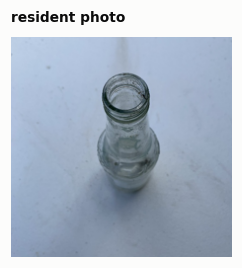

[req-0001] status=ok route=image (6.51s)
  category : Glass (1.00)   [Glass 1.00, Vegetation 0.00, Plastic 0.00]
  instructions:
    Glass - Metro City disposal instructions
    Bin: Place in dedicated glass recycling bins. Some areas require color sorting.
    Prepare: Rinse containers; Remove caps and lids (recycle separately); Labels can remain
    Do not include: Window glass or mirrors; Drinking glasses; Ceramics or pottery; Light
    bulbs; Pyrex or heat-resistant glass
  sources:
    - Policy 2: Glass Recycling Guidelines / Collection Method (effective 2023-01-24)
    - Policy 2: Glass Recycling Guidelines / Preparation Instructions (effective 2023-01-24)
    - Policy 2: Glass Recycling Guidelines / Non-Acceptable Items (effective 2023-01-24)


In [65]:
demo_row = img_test[img_test['label'] == 'Glass'].iloc[3]
print(f'input: {demo_row["path"]}  (true stream: {demo_row["label"]})\n')
fig, ax = plt.subplots(figsize=(2.6, 2.6))
ax.imshow(Image.open(demo_row['path']).resize((224, 224))); ax.axis('off')
ax.set_title('resident photo', fontsize=9)
plt.show()

show(waste_management_assistant(str(demo_row['path']), input_type='image'))

#### A written description, end to end

In [66]:
show(waste_management_assistant('a greasy cardboard pizza box with cheese stuck to it',
                                input_type='text'))

[req-0002] status=ok route=text (3.18s)
  category : Cardboard (0.99)   [Cardboard 0.99, Glass 0.00, Plastic 0.00]
  instructions:
    Cardboard - Metro City disposal instructions
    Bin: Flatten and place in recycling bins or take to cardboard recycling centers.
    Prepare: Remove all non-cardboard packaging; Flatten boxes to save space; Keep dry and
    clean
    Do not include: Waxed cardboard; Cardsboard with food residue; Cardboard with plastic
    linings; Foam inserts; Packing peanuts
  sources:
    - Policy 6: Cardboard Recycling Guidelines / Collection Method (effective 2023-11-24)
    - Policy 6: Cardboard Recycling Guidelines / Preparation Instructions (effective 2023-11-24)
    - Policy 6: Cardboard Recycling Guidelines / Non-Acceptable Items (effective 2023-11-24)


#### Both at once: probability fusion

In [67]:
amb = img_test[img_test['label'] == 'Miscellaneous Trash'].iloc[1]
print(f'photo of {amb["label"]} + the resident typing a description of the same item\n')
img_only = assistant.advise(image=str(amb['path']), generate=False)
txt_only = assistant.advise(text='broken household item made of mixed materials', generate=False)
both = assistant.advise(image=str(amb['path']),
                        text='broken household item made of mixed materials', generate=False)
for label, r in [('image only', img_only), ('text only', txt_only), ('fused', both)]:
    print(f'  {label:<12} {r["category"]:<22} {r["confidence"]:.2f}  '
          f'[{", ".join(f"{c} {p:.2f}" for c, p in r["alternatives"])}]')

photo of Miscellaneous Trash + the resident typing a description of the same item



  image only   Miscellaneous Trash    0.97  [Miscellaneous Trash 0.97, Paper 0.02, Cardboard 0.00]
  text only    Textile Trash          0.59  [Textile Trash 0.59, Plastic 0.22, Miscellaneous Trash 0.08]
  fused        Miscellaneous Trash    0.62  [Miscellaneous Trash 0.62, Textile Trash 0.24, Plastic 0.09]


#### Bulk evaluation on the held-out test sets

Classification is run over a sample from each test split with generation switched off (the
language model is the slow part and was already evaluated in §4.5); a handful of full
round-trips are timed separately so the quoted latency is the real one.

In [68]:
N_EVAL = 60
rng = np.random.default_rng(SEED)
img_sample = img_test.iloc[rng.choice(len(img_test), N_EVAL, replace=False)]
txt_sample = txt_test.iloc[rng.choice(len(txt_test), N_EVAL, replace=False)]

img_rows = []
for r in img_sample.itertuples():
    res = assistant.advise(image=str(r.path), generate=False)
    img_rows.append({'true': r.label, 'pred': res['category'], 'conf': res['confidence'],
                     'status': res['status'], 'latency': res['latency_s']})
txt_rows = []
for r in txt_sample.itertuples():
    res = assistant.advise(text=r.clean, generate=False)
    txt_rows.append({'true': r.category, 'pred': res['category'], 'conf': res['confidence'],
                     'status': res['status'], 'latency': res['latency_s']})

e2e = pd.DataFrame([
    {'route': 'image', **{
        'n': len(img_rows),
        'accuracy': np.mean([r['true'] == r['pred'] for r in img_rows]),
        'answered (status ok)': np.mean([r['status'] == 'ok' for r in img_rows]),
        'accuracy when answered': np.mean([r['true'] == r['pred'] for r in img_rows
                                           if r['status'] == 'ok']),
        'classify latency (s)': np.mean([r['latency'] for r in img_rows])}},
    {'route': 'text', **{
        'n': len(txt_rows),
        'accuracy': np.mean([r['true'] == r['pred'] for r in txt_rows]),
        'answered (status ok)': np.mean([r['status'] == 'ok' for r in txt_rows]),
        'accuracy when answered': np.mean([r['true'] == r['pred'] for r in txt_rows
                                           if r['status'] == 'ok']),
        'classify latency (s)': np.mean([r['latency'] for r in txt_rows])}},
]).set_index('route')
print(e2e.round(3).to_string())

t0 = time.time()
for r in img_sample.head(3).itertuples():
    assistant.advise(image=str(r.path))
print(f'\nfull round trip including retrieval and generation: {(time.time() - t0) / 3:.1f}s per request')

        n  accuracy  answered (status ok)  accuracy when answered  classify latency (s)
route                                                                                  
image  60     0.833                 0.833                     0.9                 0.101
text   60     1.000                 1.000                     1.0                 0.033



full round trip including retrieval and generation: 2.9s per request


#### Edge cases

Robustness is a property of the integration, not of the models. Every one of these inputs is
something a deployed endpoint will eventually receive.

In [69]:
tiny = np.random.default_rng(0).integers(0, 255, (12, 7), dtype=np.uint8)        # greyscale, tiny
portrait = Image.open(img_test.iloc[0]['path']).resize((300, 700)).convert('RGBA')  # wrong shape
corrupt = pathlib.Path('build/_corrupt.jpg')
corrupt.parent.mkdir(exist_ok=True)
corrupt.write_bytes(b'not actually a jpeg')

EDGE_CASES = [
    ('missing file', dict(image='RealWaste/does_not_exist.jpg')),
    ('corrupt file', dict(image=str(corrupt))),
    ('greyscale 12x7 array', dict(image=tiny)),
    ('portrait RGBA image', dict(image=portrait)),
    ('wrong type (int)', dict(image=42)),
    ('empty string', dict(text='')),
    ('punctuation only', dict(text='!!! ???')),
    ('no input at all', dict()),
    ('non-waste sentence', dict(text='what is the capital of Australia')),
    ('very long text', dict(text='plastic ' * 400)),
    ('valid image + unusable text', dict(image=str(img_test.iloc[0]['path']), text='12345')),
]

edge_rows = []
for name, kwargs in EDGE_CASES:
    try:
        r = assistant.advise(generate=False, **kwargs)
        edge_rows.append({'case': name, 'status': r['status'],
                          'category': r['category'] or '-',
                          'confidence': round(r['confidence'], 2),
                          'warning': (r['warnings'][0][:66] + '...') if r['warnings'] else ''})
    except Exception as exc:                                   # must never happen
        edge_rows.append({'case': name, 'status': 'UNCAUGHT EXCEPTION',
                          'category': '-', 'confidence': 0,
                          'warning': f'{type(exc).__name__}: {exc}'})
edges = pd.DataFrame(edge_rows)
print(edges.to_string(index=False))
print(f'\nuncaught exceptions: {(edges["status"] == "UNCAUGHT EXCEPTION").sum()} of {len(edges)}')
corrupt.unlink(missing_ok=True)

                       case    status            category  confidence                                                               warning
               missing file     error                   -        0.00 image route failed (FileNotFoundError: no such image: RealWaste\do...
               corrupt file     error                   -        0.00 image route failed (UnidentifiedImageError: cannot identify image ...
       greyscale 12x7 array uncertain Miscellaneous Trash        0.29 confidence 0.29 is below the 0.60 threshold for the image route - ...
        portrait RGBA image        ok             Plastic        0.91                                                                      
           wrong type (int)     error                   -        0.00       image route failed (TypeError: unsupported image input: int)...
               empty string     error                   -        0.00                 no input: provide an image, a description, or both...
           punctuati

#### The feedback loop

A deployed assistant is wrong a measurable fraction of the time, and the cheapest source of
labelled data is the resident who just saw the answer. Corrections are logged, aggregated into
a live accuracy report, and - for text inputs - replayed as exact-wording overrides, so the
same mistake is not repeated on the same phrasing while a retrain is pending.

In [70]:
assistant_fb = WasteAssistant(model)
for r in txt_sample.head(25).itertuples():
    res = assistant_fb.advise(text=r.clean, generate=False)
    assistant_fb.record_feedback(res, r.category)
for r in img_sample.head(15).itertuples():
    res = assistant_fb.advise(image=str(r.path), generate=False)
    assistant_fb.record_feedback(res, r.label)

report = assistant_fb.feedback_report()
print()
print(report.to_string())

40 corrections logged | live accuracy 95.0% | 0 wording overrides active

most frequent real-world confusions:
  predicted Metal                actually Plastic              x1
  predicted Miscellaneous Trash  actually Vegetation           x1

       answers  accuracy  mean_confidence
route                                    
image       15     0.867            0.813
text        25     1.000            0.985


In [71]:
# The override in action: a wording the model gets wrong, corrected once, then re-asked.
# A fresh assistant is used to find the failing case - `assistant_fb` has already learned
# overrides from the corrections logged above, so it would report no errors left.
probe = WasteAssistant(model)
wrong_rows = [(r.clean, r.category) for r in txt_test.head(80).itertuples()
              if probe.advise(text=r.clean, generate=False)['category'] != r.category]

if wrong_rows:
    wording, truth = wrong_rows[0]
    note = f'a real error: {len(wrong_rows)} of the first 80 test descriptions are misread'
else:
    # The text classifier makes no errors on this synthetic test set (§3.4), so there is no
    # real failure to repair. The mechanism is shown instead on a deliberately under-specified
    # wording, where the resident knows something the description does not say: this scrap of
    # fabric is laminated, so it belongs in Miscellaneous Trash rather than Textile Trash.
    wording, truth = 'small piece of coated fabric', 'Miscellaneous Trash'
    note = ('no real errors on this test set, so the mechanism is shown on an '
            'under-specified wording the resident can disambiguate')

print(f'({note})\n')
fresh = WasteAssistant(model)
before = fresh.advise(text=wording, generate=False)
print(f'description : {wording!r}')
print(f'before      : {before["category"]} ({before["confidence"]:.2f})   '
      f'resident says: {truth}')
print(f'feedback    : {fresh.record_feedback(before, truth, note="resident correction")}')
after = fresh.advise(text=wording, generate=False)
print(f'after       : {after["category"]} ({after["confidence"]:.2f})   {after["warnings"]}')
print('\nThe override is a patch, not a fix: it only matches this exact wording. Its real value '
      'is that the correction is now a labelled example for the next retrain.')

(no real errors on this test set, so the mechanism is shown on an under-specified wording the resident can disambiguate)

description : 'small piece of coated fabric'
before      : Textile Trash (0.99)   resident says: Miscellaneous Trash
feedback    : {'accepted': True, 'logged': 1, 'overrides': 1}
after       : Miscellaneous Trash (1.00)   ['applied a correction recorded from earlier feedback']

The override is a patch, not a fix: it only matches this exact wording. Its real value is that the correction is now a labelled example for the next retrain.


### 5.4 What this system is, and what it is not

**What was built.** A single endpoint that accepts a photograph, a sentence, or both; routes
each to a model trained and evaluated on a held-out split; fuses them when both are present;
refuses to answer confidently when it should not; and returns disposal instructions grounded
in - and citing - the Metro City policy documents, falling back to quoted policy when the
generator drifts. Every component is measured rather than asserted, and the integration layer
is tested against the malformed inputs a real endpoint receives.

**What it is not.** Four limitations are structural, not bugs:

1. **Domain shift on photographs.** Every training image is a 524x524 facility photograph
   under one lighting setup (§1.1). Resident phone photos will be framed, lit and cropped
   differently, and the honest expectation is a meaningful drop from the test accuracy in
   §2.6. Augmentation mitigates it; only real user photos will fix it.
2. **Synthetic text.** A 309-word templated vocabulary (§1.2) is not how people write, and
   the text classifier scoring 100% (§3.4) is a statement about the benchmark, not about the
   model. Its true accuracy on resident free text is unknown and certainly lower; the gap
   between DistilBERT and the linear baseline, invisible here, is where it should show up.
3. **A small generator.** FLAN-T5-base produces correct but plain instructions, and the
   grounding guard fires rather than being decorative. A larger model would write better
   prose; the architecture, not the model, is what keeps it factual.
4. **Nine streams, closed world.** Neither classifier can say "this is not waste" or "this is
   hazardous"; it can only say it is unsure. Batteries, e-waste and chemicals are named in the
   Miscellaneous Trash policy but have no class of their own, which for a safety-relevant
   category is the single most important gap to close next.

**Where the next unit of effort goes.** In order: collect several hundred resident photos and
fine-tune on them, because that is where the largest real-world gap is; add an explicit
hazardous-waste class; and route the feedback store into a weekly retrain so the corrections
logged above become training data instead of patches.